<a href="https://colab.research.google.com/github/YannPhamVan/FinMLOps/blob/main/notebooks/finmlops.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports and Installs

In [1]:
# IMPORTS
import numpy as np
import pandas as pd

#Fin Data Sources
import yfinance as yf
import pandas_datareader as pdr

#Data viz
import plotly.graph_objs as go
import plotly.graph_objects as go
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# measure time for ML HyperParams search
import time
from datetime import date

# ML models and utils
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score

# Disable SettingWithCopyWarning
pd.options.mode.chained_assignment = None  # default='warn'

# 0) One DataFrame with Dummies


## 0.1) Read and truncate data (last 25 years from 2000), define variable sets


In [2]:
# full dataset for 109 ETFs
df_full = pd.read_parquet("../data/processed/etf_df_combined_2025_08_25.parquet.brotli", )

In [3]:
df_full.info()

<class 'pandas.core.frame.DataFrame'>
Index: 229928 entries, 0 to 2789
Columns: 203 entries, Open to growth_btc_usd_365d
dtypes: datetime64[ns](3), float64(130), int32(64), int64(5), object(1)
memory usage: 301.7+ MB


In [4]:
# growth indicators (but not future growth)
GROWTH = [g for g in df_full.keys() if (g.find('growth_')==0)&(g.find('future')<0)]
GROWTH

['growth_1d',
 'growth_3d',
 'growth_7d',
 'growth_30d',
 'growth_90d',
 'growth_365d',
 'growth_dax_1d',
 'growth_dax_3d',
 'growth_dax_7d',
 'growth_dax_30d',
 'growth_dax_90d',
 'growth_dax_365d',
 'growth_snp500_1d',
 'growth_snp500_3d',
 'growth_snp500_7d',
 'growth_snp500_30d',
 'growth_snp500_90d',
 'growth_snp500_365d',
 'growth_dji_1d',
 'growth_dji_3d',
 'growth_dji_7d',
 'growth_dji_30d',
 'growth_dji_90d',
 'growth_dji_365d',
 'growth_epi_1d',
 'growth_epi_3d',
 'growth_epi_7d',
 'growth_epi_30d',
 'growth_epi_90d',
 'growth_epi_365d',
 'growth_gold_1d',
 'growth_gold_3d',
 'growth_gold_7d',
 'growth_gold_30d',
 'growth_gold_90d',
 'growth_gold_365d',
 'growth_wti_oil_1d',
 'growth_wti_oil_3d',
 'growth_wti_oil_7d',
 'growth_wti_oil_30d',
 'growth_wti_oil_90d',
 'growth_wti_oil_365d',
 'growth_brent_oil_1d',
 'growth_brent_oil_3d',
 'growth_brent_oil_7d',
 'growth_brent_oil_30d',
 'growth_brent_oil_90d',
 'growth_brent_oil_365d',
 'growth_btc_usd_1d',
 'growth_btc_usd_3d',


In [5]:
# leaving only Volume ==> generate ln(Volume)
OHLCV = ['Open','High','Low','Close','Close_x','Volume']

In [6]:
CATEGORICAL = ['Month', 'Weekday', 'Ticker']

In [7]:
# 1.2% median growth
df_full.growth_future_30d.describe()

count    226635.000000
mean          1.021946
std           1.940996
min           0.002481
25%           0.976594
50%           1.012059
75%           1.046670
max         327.238148
Name: growth_future_30d, dtype: float64

In [8]:
# 58% of data records have positive future growth>0
df_full.is_positive_growth_30d_future.mean()

np.float64(0.5837436066942695)

In [9]:
# moving to strong growth (54% -> ~ 32%):
df_full.growth_future_30d.quantile(0.68)

np.float64(1.0358658077640661)

In [10]:
TO_PREDICT = [g for g in df_full.keys() if (g.find('future')>=0)]
TO_PREDICT

['growth_future_30d', 'is_positive_growth_30d_future']

In [11]:
# MAIN GOAL HERE IS TO MAKE SURE THAT 'OTHER' list is empty - we should categorize all feautures
# dropping some features - artifacts from joins, CATEGORICAL (to be converted to dummies), OHLCV
# 'index_x', 'index_y', 'index','Adj Close_y'
TO_DROP = ['Year','Date', 'Quarter', 'index_x', 'index_y', 'index', 'Close_y'] + CATEGORICAL + OHLCV
TO_DROP

['Year',
 'Date',
 'Quarter',
 'index_x',
 'index_y',
 'index',
 'Close_y',
 'Month',
 'Weekday',
 'Ticker',
 'Open',
 'High',
 'Low',
 'Close',
 'Close_x',
 'Volume']

In [12]:
# let's define on more custom numerical features
# Add a small constant to avoid log(0)
df_full['ln_volume'] = df_full.Volume.apply(lambda x: np.log(x+ 1e-6))

In [13]:
# define additional columns (DUMMIES) on Dividends or Stock Splits
df_full['is_div_payout'] = (df_full.Dividends>0).astype(int)
df_full['is_stock_split'] = (df_full['Stock Splits']>0).astype(int)

In [14]:
# manually defined features
# 'Dividends' and 'Stock Splits' - absolute values of Divs and Splits.
# is_stock_split, is_div_payout - dummies on the dates when Divs and Splits are >0
CUSTOM_NUMERICAL = ['SMA10', 'SMA20', 'growing_moving_average', 'high_minus_low_relative','volatility', 'ln_volume', 'is_div_payout', 'is_stock_split', 'Dividends', 'Stock Splits']

In [15]:
# All Supported Ta-lib indicators: https://github.com/TA-Lib/ta-lib-python/blob/master/docs/funcs.md

TECHNICAL_INDICATORS = ['adx', 'adxr', 'apo', 'aroon_1','aroon_2', 'aroonosc',
 'bop', 'cci', 'cmo','dx', 'macd', 'macdsignal', 'macdhist', 'macd_ext',
 'macdsignal_ext', 'macdhist_ext', 'macd_fix', 'macdsignal_fix',
 'macdhist_fix', 'mfi', 'minus_di', 'mom', 'plus_di', 'dm', 'ppo',
 'roc', 'rocp', 'rocr', 'rocr100', 'rsi', 'slowk', 'slowd', 'fastk',
 'fastd', 'fastk_rsi', 'fastd_rsi', 'trix', 'ultosc', 'willr',
 'ad', 'adosc', 'obv', 'atr', 'natr', 'ht_dcperiod', 'ht_dcphase',
 'ht_phasor_inphase', 'ht_phasor_quadrature', 'ht_sine_sine', 'ht_sine_leadsine',
 'ht_trendmod', 'avgprice', 'medprice', 'typprice', 'wclprice']

In [16]:
TECHNICAL_PATTERNS = [g for g in df_full.keys() if g.find('cdl')>=0]
print(f'Technical patterns count = {len(TECHNICAL_PATTERNS)}, examples = {TECHNICAL_PATTERNS[0:5]}')

Technical patterns count = 61, examples = ['cdl2crows', 'cdl3blackrows', 'cdl3inside', 'cdl3linestrike', 'cdl3outside']


In [17]:
MACRO = ['gdppot_us_yoy', 'gdppot_us_qoq', 'cpi_core_yoy', 'cpi_core_mom', 'FEDFUNDS',
 'DGS1', 'DGS5', 'DGS10']

In [18]:
NUMERICAL = GROWTH + TECHNICAL_INDICATORS + TECHNICAL_PATTERNS + CUSTOM_NUMERICAL + MACRO

In [19]:
# CHECK: NO OTHER INDICATORS LEFT
OTHER = [k for k in df_full.keys() if k not in OHLCV + CATEGORICAL + NUMERICAL + TO_DROP + TO_PREDICT]
OTHER

['Capital Gains']

In [20]:
df_full.Ticker.nunique()

109

In [21]:
# Non truncated stats
# tickers, min-max date, count of daily observations
df_full.groupby(['Ticker'])['Date'].agg(['min','max','count'])

,min,max,count
Ticker,,,
DE000A2QP372,2021-12-07,2025-08-25,952
DE000A2QP380,2021-12-07,2025-08-25,952
DE000A2QP398,2022-04-08,2025-08-25,864
DE000A2QP4A8,2022-04-08,2025-08-25,864
FR0007052782,2008-01-02,2025-08-25,4515
...,...,...,...
LU1953137681,2019-09-27,2025-08-25,1515
LU2182388582,2020-06-25,2025-08-25,1326
LU2195226068,2020-07-06,2025-08-25,1319


In [22]:
# truncated df_full with 25 years of data (and defined growth variables)
df = df_full[df_full.Date>='2000-01-01']
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 229928 entries, 0 to 2789
Columns: 206 entries, Open to is_stock_split
dtypes: datetime64[ns](3), float64(131), int32(64), int64(7), object(1)
memory usage: 307.0+ MB


In [23]:
# Truncated info by ticker
df.groupby(['Ticker'])['Date'].agg(['min','max','count'])

,min,max,count
Ticker,,,
DE000A2QP372,2021-12-07,2025-08-25,952
DE000A2QP380,2021-12-07,2025-08-25,952
DE000A2QP398,2022-04-08,2025-08-25,864
DE000A2QP4A8,2022-04-08,2025-08-25,864
FR0007052782,2008-01-02,2025-08-25,4515
...,...,...,...
LU1953137681,2019-09-27,2025-08-25,1515
LU2182388582,2020-06-25,2025-08-25,1326
LU2195226068,2020-07-06,2025-08-25,1319


## 0.2) Dummies

In [24]:
# dummy variables can't be generated from Date and numeric variables ==> convert to STRING (to define groups for Dummies)
df.loc[:,'Month'] = df.Month.dt.strftime('%B')
df.loc[:,'Weekday'] = df.Weekday.astype(str)

C:\Users\Zelric\AppData\Local\Temp\ipykernel_10264\2164722115.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['June' 'June' 'June' ... 'August' 'August' 'August']' has dtype incompatible with datetime64[ns], please explicitly cast to a compatible dtype first.
  df.loc[:,'Month'] = df.Month.dt.strftime('%B')
C:\Users\Zelric\AppData\Local\Temp\ipykernel_10264\2164722115.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['1' '2' '3' ... '3' '4' '0']' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  df.loc[:,'Weekday'] = df.Weekday.astype(str)


### 0.2.2) Generate all dummies

In [25]:
# what are the categorical features?
# SHOULD we remove Ticker from CATEGORICAL? To generalize it even more?
CATEGORICAL

['Month', 'Weekday', 'Ticker']

In [26]:
# Generate dummy variables (no need for bool, let's have int32 instead)
dummy_variables = pd.get_dummies(df[CATEGORICAL], dtype='int32')

In [27]:
# the list of dummies
dummy_variables.keys()

Index(['Month_April', 'Month_August', 'Month_December', 'Month_February',
       'Month_January', 'Month_July', 'Month_June', 'Month_March', 'Month_May',
       'Month_November',
       ...
       'Ticker_LU1834987890', 'Ticker_LU1834987973', 'Ticker_LU1834988518',
       'Ticker_LU1834988781', 'Ticker_LU1834988864', 'Ticker_LU1953137681',
       'Ticker_LU2182388582', 'Ticker_LU2195226068', 'Ticker_LU2655993207',
       'Ticker_LU3047998896'],
      dtype='object', length=126)

In [28]:
# get dummies names in a list
DUMMIES = dummy_variables.keys().to_list()
DUMMIES

['Month_April',
 'Month_August',
 'Month_December',
 'Month_February',
 'Month_January',
 'Month_July',
 'Month_June',
 'Month_March',
 'Month_May',
 'Month_November',
 'Month_October',
 'Month_September',
 'Weekday_0',
 'Weekday_1',
 'Weekday_2',
 'Weekday_3',
 'Weekday_4',
 'Ticker_DE000A2QP372',
 'Ticker_DE000A2QP380',
 'Ticker_DE000A2QP398',
 'Ticker_DE000A2QP4A8',
 'Ticker_FR0007052782',
 'Ticker_FR0007054358',
 'Ticker_FR0010010827',
 'Ticker_FR0010150458',
 'Ticker_FR0010405431',
 'Ticker_FR0010411884',
 'Ticker_FR0010424135',
 'Ticker_FR0010468983',
 'Ticker_FR0010591362',
 'Ticker_FR0010592014',
 'Ticker_FR0010655704',
 'Ticker_FR0010655712',
 'Ticker_FR0010655746',
 'Ticker_FR0010717090',
 'Ticker_FR0010755611',
 'Ticker_FR0011440478',
 'Ticker_FR0011550185',
 'Ticker_FR0011550193',
 'Ticker_FR0011550672',
 'Ticker_FR0011869270',
 'Ticker_FR0011869304',
 'Ticker_FR0011869312',
 'Ticker_FR0011869320',
 'Ticker_FR0011871078',
 'Ticker_FR0011871110',
 'Ticker_FR0011871128',
 'Ti

In [29]:
len(DUMMIES)

126

In [30]:
# Concatenate the dummy variables with the original DataFrame
df_with_dummies = pd.concat([df, dummy_variables], axis=1)

In [31]:
df_with_dummies[NUMERICAL+DUMMIES].info()

<class 'pandas.core.frame.DataFrame'>
Index: 229928 entries, 0 to 2789
Columns: 314 entries, growth_1d to Ticker_LU3047998896
dtypes: float64(123), int32(188), int64(3)
memory usage: 387.7 MB


### 0.2.4) Temporal split

In [32]:
def temporal_split(df, min_date, max_date, train_prop=0.7, val_prop=0.15, test_prop=0.15):
    """
    Splits a DataFrame into three buckets based on the temporal order of the 'Date' column.

    Args:
        df (DataFrame): The DataFrame to split.
        min_date (str or Timestamp): Minimum date in the DataFrame.
        max_date (str or Timestamp): Maximum date in the DataFrame.
        train_prop (float): Proportion of data for training set (default: 0.7).
        val_prop (float): Proportion of data for validation set (default: 0.15).
        test_prop (float): Proportion of data for test set (default: 0.15).

    Returns:
        DataFrame: The input DataFrame with a new column 'split' indicating the split for each row.
    """
    # Define the date intervals
    train_end = min_date + pd.Timedelta(days=(max_date - min_date).days * train_prop)
    val_end = train_end + pd.Timedelta(days=(max_date - min_date).days * val_prop)

    # Assign split labels based on date ranges
    split_labels = []
    for date in df['Date']:
        if date <= train_end:
            split_labels.append('train')
        elif date <= val_end:
            split_labels.append('validation')
        else:
            split_labels.append('test')

    # Add 'split' column to the DataFrame
    df['split'] = split_labels

    return df

In [33]:
min_date_df = df_with_dummies.Date.min()
max_date_df = df_with_dummies.Date.max()

df_with_dummies = temporal_split(df_with_dummies,
                                 min_date = min_date_df,
                                 max_date = max_date_df)

In [34]:
# the split is approximate!
  # as tickers can have a different history
df_with_dummies['split'].value_counts()/len(df_with_dummies)

split
train         0.506489
test          0.267205
validation    0.226306
Name: count, dtype: float64

In [35]:
# remove the "segmentation" problem (warning message on df performance after many joins and data transformations)
new_df = df_with_dummies.copy()

In [36]:
# EXACT DATES for the split:
# time split on train/validation/test: FIXED dates of split, approx. 70%, 15%, 15% split
new_df.groupby(['split'])['Date'].agg({'min','max','count'})

,count,max,min
split,,,
test,61438,2025-08-25,2023-01-02
train,116456,2020-05-08,2008-01-02
validation,52034,2022-12-30,2020-05-11


In [37]:
# Full dataframe (transformed and truncated to 25 years)
new_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 229928 entries, 0 to 2789
Columns: 333 entries, Open to split
dtypes: datetime64[ns](2), float64(131), int32(189), int64(7), object(4)
memory usage: 420.1+ MB


In [38]:
# check one record: it has abs. values, text, and numbers
new_df.head(1)

,Open,High,Low,Close_x,Volume,Dividends,Stock Splits,Capital Gains,Ticker,Year,...,Ticker_LU1834987973,Ticker_LU1834988518,Ticker_LU1834988781,Ticker_LU1834988864,Ticker_LU1953137681,Ticker_LU2182388582,Ticker_LU2195226068,Ticker_LU2655993207,Ticker_LU3047998896,split
0,61.82,61.82,61.82,61.82,0.0,0.0,0.0,0.0,FR0010591362,2008,...,0,0,0,0,0,0,0,0,0,train


In [39]:
# what do we try to predict
new_df[TO_PREDICT].head(1)

,growth_future_30d,is_positive_growth_30d_future
0,1.108379,1


### 0.2.5 Define dataframes for Modeling (ML) and cleane them

In [40]:
# Features to be used in predictions (incl. new dummies)
features_list = NUMERICAL+DUMMIES


# What we're trying to predict?
to_predict = 'is_positive_growth_30d_future'

train_df = new_df[new_df.split.isin(['train'])].copy(deep=True)
valid_df = new_df[new_df.split.isin(['validation'])].copy(deep=True)
train_valid_df = new_df[new_df.split.isin(['train','validation'])].copy(deep=True)
test_df =  new_df[new_df.split.isin(['test'])].copy(deep=True)

# ONLY numerical Separate features and target variable for training and testing sets
X_train = train_df[features_list+[to_predict]]
X_valid = valid_df[features_list+[to_predict]]
X_train_valid = train_valid_df[features_list+[to_predict]]
X_test = test_df[features_list+[to_predict]]

# this to be used for predictions and join to the original dataframe new_df
X_all =  new_df[features_list+[to_predict]].copy(deep=True)

print(f'length: X_train {X_train.shape},  X_validation {X_valid.shape}, X_test {X_test.shape}, X_train_valid = {X_train_valid.shape},  all combined: X_all {X_all.shape}')

length: X_train (116456, 315),  X_validation (52034, 315), X_test (61438, 315), X_train_valid = (168490, 315),  all combined: X_all (229928, 315)


In [41]:
# Prepare a dataframe for ML:
  # +-inf to NaN, all NaNs to 0s
def clean_dataframe_from_inf_and_nan(df:pd.DataFrame):
  df.replace([np.inf, -np.inf], np.nan, inplace=True)
  df.fillna(0, inplace=True)
  return df

In [42]:
# Clean from +-inf and NaNs:

X_train = clean_dataframe_from_inf_and_nan(X_train)
X_valid = clean_dataframe_from_inf_and_nan(X_valid)
X_train_valid = clean_dataframe_from_inf_and_nan(X_train_valid)
X_test = clean_dataframe_from_inf_and_nan(X_test)
X_all = clean_dataframe_from_inf_and_nan(X_all)

In [43]:
y_train = X_train[to_predict]
y_valid = X_valid[to_predict]
y_train_valid = X_train_valid[to_predict]
y_test = X_test[to_predict]
y_all =  X_all[to_predict]

# remove y_* from X_* dataframes
del X_train[to_predict]
del X_valid[to_predict]
del X_train_valid[to_predict]
del X_test[to_predict]
del X_all[to_predict]

# 1) Modeling

## 1.1) Manual 'rule of thumb' predictions

* (pred0) CCI>200 (binary, on technical indicator CCI)
* (pred1) growth_30d>1
* (pred2) (growth_30d>1) & (growth_snp500_30d>1)
* (pred3) (DGS10 <= 4) & (DGS5 <= 1)
* (pred4) (DGS10 > 4) & (FEDFUNDS <= 4.795)

In [44]:
# generate manual predictions
# Let's label all prediction features with prefix "pred"
new_df['pred0_manual_cci'] = (new_df.cci>200).astype(int)
new_df['pred1_manual_prev_g1'] = (new_df.growth_30d>1).astype(int)
new_df['pred2_manual_prev_g1_and_snp'] = ((new_df['growth_30d'] > 1) & (new_df['growth_snp500_30d'] > 1)).astype(int)
new_df['pred3_manual_dgs10_5'] = ((new_df['DGS10'] <= 4) & (new_df['DGS5'] <= 1)).astype(int)
new_df['pred4_manual_dgs10_fedfunds'] = ((new_df['DGS10'] > 4) & (new_df['FEDFUNDS'] <= 4.795)).astype(int)

In [45]:
# example output manual predictions:
new_df[['cci','growth_30d','growth_snp500_30d','pred0_manual_cci','pred1_manual_prev_g1','pred2_manual_prev_g1_and_snp','pred3_manual_dgs10_5','pred4_manual_dgs10_fedfunds','is_positive_growth_30d_future']].sample(10)

,cci,growth_30d,growth_snp500_30d,pred0_manual_cci,pred1_manual_prev_g1,pred2_manual_prev_g1_and_snp,pred3_manual_dgs10_5,pred4_manual_dgs10_fedfunds,is_positive_growth_30d_future
803,15.926385,1.018700,0.983963,0,1,0,0,0,0
658,-50.137044,0.949090,0.919358,0,0,0,0,0,1
3092,-188.625123,0.937649,1.005151,0,0,0,1,0,1
2575,-119.543968,0.941164,0.948051,0,0,0,0,0,0
1330,21.978012,1.042984,1.038180,0,1,1,1,0,1
938,-8.975481,1.015435,0.931617,0,1,0,0,1,0
1780,-8.391171,1.028619,1.014186,0,1,1,0,0,0
641,77.416239,0.977125,1.014939,0,0,0,0,0,0
1584,91.223484,1.002654,1.048677,0,1,1,0,1,1
3026,121.747437,1.044858,1.021464,0,1,1,1,0,1


In [46]:
# List of current predictions
PREDICTIONS = [k for k in new_df.keys() if k.startswith('pred')]
PREDICTIONS

['pred0_manual_cci',
 'pred1_manual_prev_g1',
 'pred2_manual_prev_g1_and_snp',
 'pred3_manual_dgs10_5',
 'pred4_manual_dgs10_fedfunds']

In [47]:
# Function to find all predictions (starting from 'pred'), generate is_correct (correctness of each prediction)
# and precision on TEST dataset (assuming there is df["split"] column with values 'train','validation','test'

# returns 2 lists of features: PREDICTIONS and IS_CORRECT

def get_predictions_correctness(df:pd.DataFrame, to_predict:str):
  PREDICTIONS = [k for k in df.keys() if k.startswith('pred')]
  print(f'Prediction columns founded: {PREDICTIONS}')

  # add columns is_correct_
  for pred in PREDICTIONS:
    part1 = pred.split('_')[0] # first prefix before '_'
    df[f'is_correct_{part1}'] =  (new_df[pred] == new_df[to_predict]).astype(int)

  # IS_CORRECT features set
  IS_CORRECT =  [k for k in df.keys() if k.startswith('is_correct_')]
  print(f'Created columns is_correct: {IS_CORRECT}')

  print('Precision on TEST set for each prediction:')
  # define "Precision" for ALL predictions on a Test dataset (~4 last years of trading)
  for i,column in enumerate(IS_CORRECT):
    prediction_column = PREDICTIONS[i]
    is_correct_column = column
    filter = (new_df.split=='test') & (new_df[prediction_column]==1)
    print(f'Prediction column:{prediction_column} , is_correct_column: {is_correct_column}')
    print(new_df[filter][is_correct_column].value_counts())
    print(new_df[filter][is_correct_column].value_counts()/len(new_df[filter]))
    print('---------')

  return PREDICTIONS, IS_CORRECT

In [48]:
# check the precision of currect predictions. to_predict = previously defined variable to predict
PREDICTIONS, IS_CORRECT = get_predictions_correctness(df = new_df, to_predict= to_predict)

Prediction columns founded: ['pred0_manual_cci', 'pred1_manual_prev_g1', 'pred2_manual_prev_g1_and_snp', 'pred3_manual_dgs10_5', 'pred4_manual_dgs10_fedfunds']
Created columns is_correct: ['is_correct_pred0', 'is_correct_pred1', 'is_correct_pred2', 'is_correct_pred3', 'is_correct_pred4']
Precision on TEST set for each prediction:
Prediction column:pred0_manual_cci , is_correct_column: is_correct_pred0
is_correct_pred0
1    626
0    494
Name: count, dtype: int64
is_correct_pred0
1    0.558929
0    0.441071
Name: count, dtype: float64
---------
Prediction column:pred1_manual_prev_g1 , is_correct_column: is_correct_pred1
is_correct_pred1
1    21316
0    16825
Name: count, dtype: int64
is_correct_pred1
1    0.558874
0    0.441126
Name: count, dtype: float64
---------
Prediction column:pred2_manual_prev_g1_and_snp , is_correct_column: is_correct_pred2
is_correct_pred2
1    16432
0    13667
Name: count, dtype: int64
is_correct_pred2
1    0.545932
0    0.454068
Name: count, dtype: float64
---

In [49]:
# SAMPLE: check predictions vs. is_correct vs. is_positive_growth variable
new_df[PREDICTIONS+IS_CORRECT+[to_predict]].sample(10)

,pred0_manual_cci,pred1_manual_prev_g1,pred2_manual_prev_g1_and_snp,pred3_manual_dgs10_5,pred4_manual_dgs10_fedfunds,is_correct_pred0,is_correct_pred1,is_correct_pred2,is_correct_pred3,is_correct_pred4,is_positive_growth_30d_future
1138,0,0,0,0,0,0,0,0,0,0,1
600,0,1,1,0,0,1,0,0,1,1,0
338,0,1,1,0,1,1,0,0,1,0,0
4001,0,1,0,0,0,1,0,1,1,1,0
98,0,1,1,0,1,1,0,0,1,0,0
593,0,1,1,1,0,0,1,1,1,0,1
665,0,1,0,0,0,1,0,1,1,1,0
1038,0,1,1,0,0,0,1,1,0,0,1
624,0,0,0,0,0,1,1,1,1,1,0
1901,0,0,0,0,0,0,0,0,0,0,1


## 1.2) Decision Tree Classifier

### 1.2.1) Defining Functions to clean_df(), fit_decision_tree(), predict_decision_tree()
* here we discuss only the Decision Tree Classifier for binary predictions (and not the Regressor)

In [50]:
# Estimation/fit function (using dataframe of features X and what to predict y) --> optimising total accuracy
# max_depth is hyperParameter
def fit_decision_tree(X, y, max_depth=20):
# Initialize the Decision Tree Classifier
  clf = DecisionTreeClassifier(max_depth=max_depth,
                               random_state=42)

  # Fit the classifier to the training data
  clf.fit(X, y)
  return clf, X.columns

In [51]:
%%time
clf_10, train_columns = fit_decision_tree(X=X_train_valid,
                           y=y_train_valid,
                           max_depth=10)

CPU times: total: 0 ns
Wall time: 14.5 s


In [52]:
# predict on a full dataset
y_pred_all = clf_10.predict(X_all)

In [53]:
# defining a new prediction vector is easy now, as the dimensions will match
new_df['pred5_clf_10'] = y_pred_all

In [54]:
# new prediction is added --> need to recalculate the correctness
PREDICTIONS, IS_CORRECT = get_predictions_correctness(df = new_df, to_predict = to_predict)

Prediction columns founded: ['pred0_manual_cci', 'pred1_manual_prev_g1', 'pred2_manual_prev_g1_and_snp', 'pred3_manual_dgs10_5', 'pred4_manual_dgs10_fedfunds', 'pred5_clf_10']
Created columns is_correct: ['is_correct_pred0', 'is_correct_pred1', 'is_correct_pred2', 'is_correct_pred3', 'is_correct_pred4', 'is_correct_pred5']
Precision on TEST set for each prediction:
Prediction column:pred0_manual_cci , is_correct_column: is_correct_pred0
is_correct_pred0
1    626
0    494
Name: count, dtype: int64
is_correct_pred0
1    0.558929
0    0.441071
Name: count, dtype: float64
---------
Prediction column:pred1_manual_prev_g1 , is_correct_column: is_correct_pred1
is_correct_pred1
1    21316
0    16825
Name: count, dtype: int64
is_correct_pred1
1    0.558874
0    0.441126
Name: count, dtype: float64
---------
Prediction column:pred2_manual_prev_g1_and_snp , is_correct_column: is_correct_pred2
is_correct_pred2
1    16432
0    13667
Name: count, dtype: int64
is_correct_pred2
1    0.545932
0    0.45

## 1.2.3 Hyperparams tuning for a Decision Tree Classifier

In [55]:
# visualisation: decision tree for a few levels (max_depth variable)
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# https://stackoverflow.com/questions/20156951/how-do-i-find-which-attributes-my-tree-splits-on-when-using-scikit-learn
from sklearn.tree import export_text

Working with a tree of a max depth= 1
  Precision on test is 0.5904489078420522, (precision on valid is 0.7364450398364238 - tend to overfit)


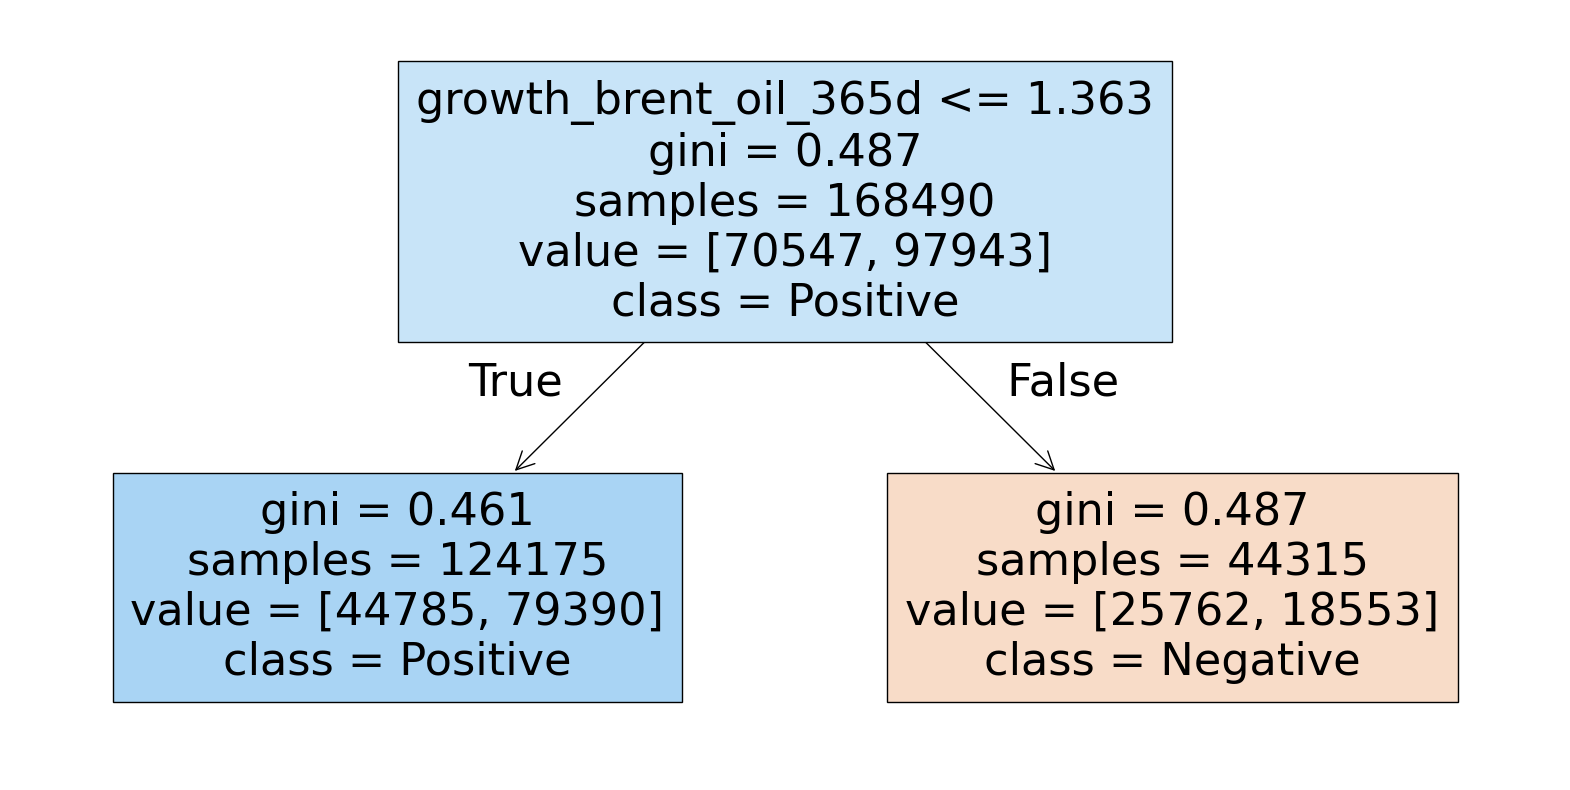

|--- growth_brent_oil_365d <= 1.36
|   |--- class: 1
|--- growth_brent_oil_365d >  1.36
|   |--- class: 0

------------------------------
Working with a tree of a max depth= 2
  Precision on test is 0.5904489078420522, (precision on valid is 0.7339345418852182 - tend to overfit)


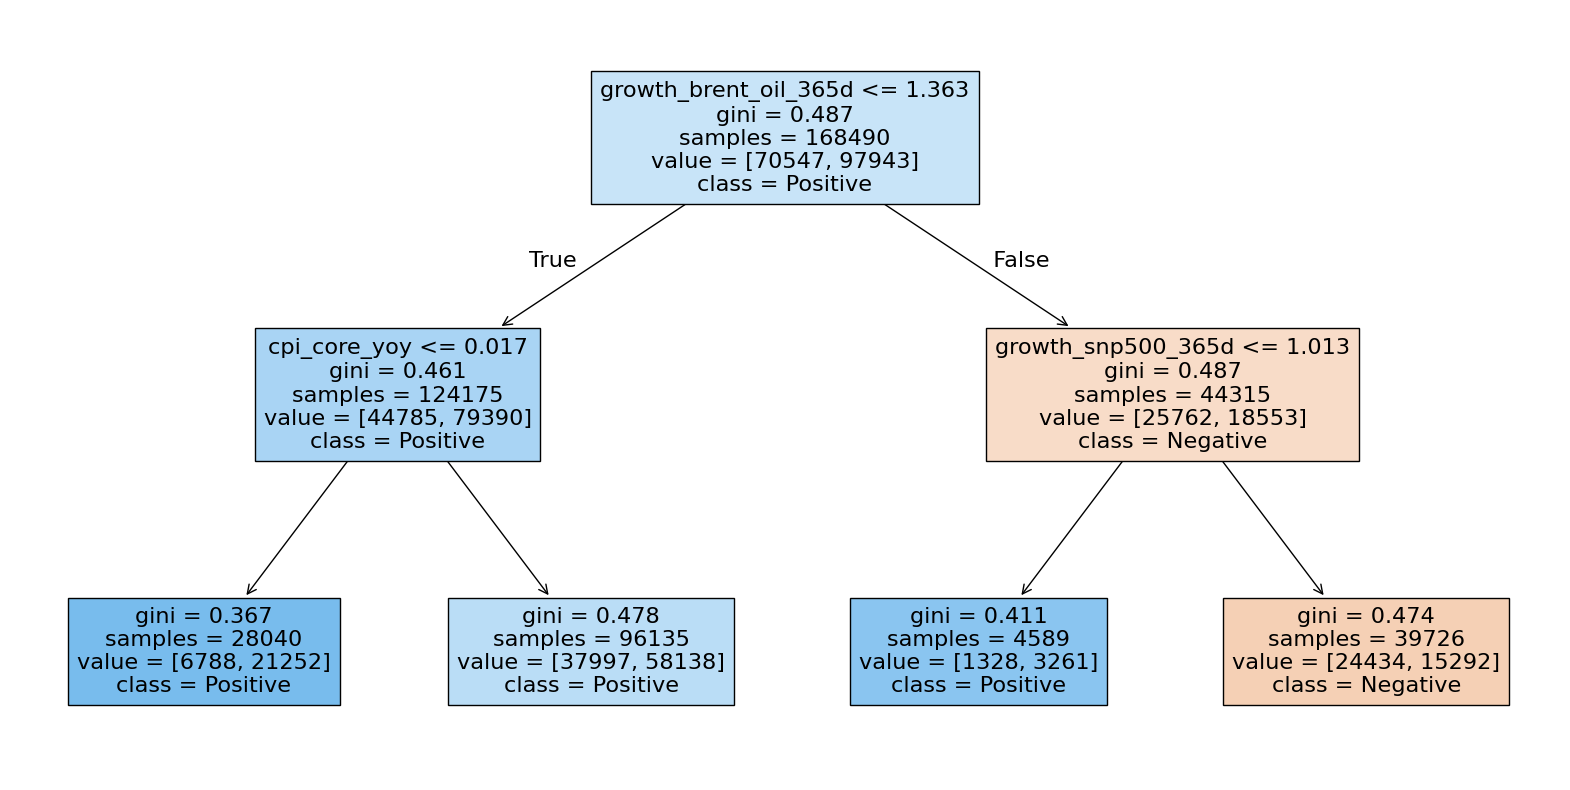

|--- growth_brent_oil_365d <= 1.36
|   |--- cpi_core_yoy <= 0.02
|   |   |--- class: 1
|   |--- cpi_core_yoy >  0.02
|   |   |--- class: 1
|--- growth_brent_oil_365d >  1.36
|   |--- growth_snp500_365d <= 1.01
|   |   |--- class: 1
|   |--- growth_snp500_365d >  1.01
|   |   |--- class: 0

------------------------------
Working with a tree of a max depth= 3
  Precision on test is 0.5790083922261484, (precision on valid is 0.7868123123666221 - tend to overfit)
Working with a tree of a max depth= 4
  Precision on test is 0.5654637958053367, (precision on valid is 0.7940400089050027 - tend to overfit)
Working with a tree of a max depth= 5
  Precision on test is 0.570071006420341, (precision on valid is 0.8046027742749055 - tend to overfit)
Working with a tree of a max depth= 6
  Precision on test is 0.5678247637010524, (precision on valid is 0.8289986996098829 - tend to overfit)
Working with a tree of a max depth= 7
  Precision on test is 0.5794213041993854, (precision on valid is 0.84279

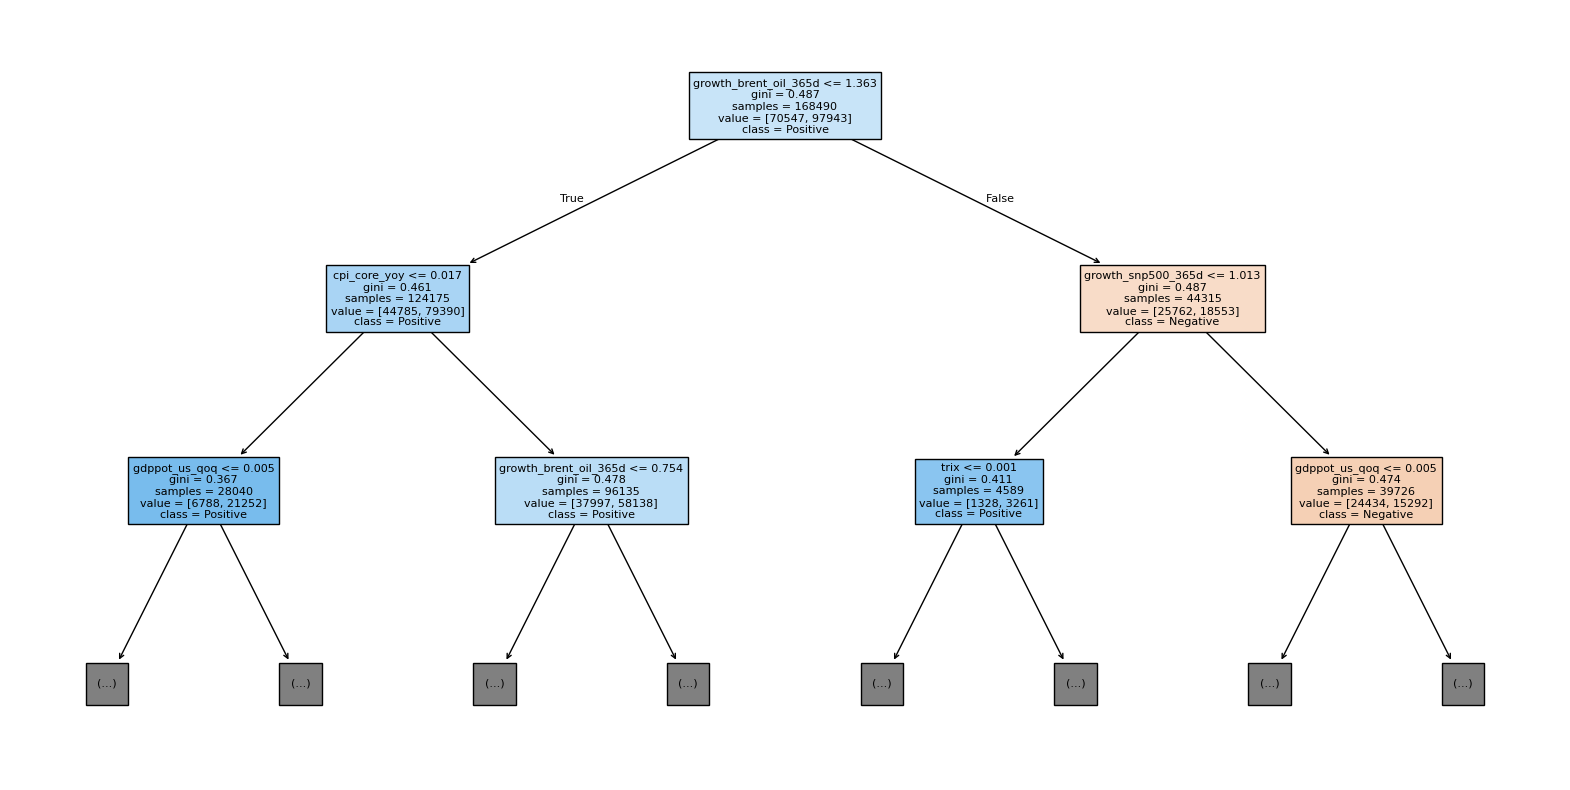

|--- growth_brent_oil_365d <= 1.36
|   |--- cpi_core_yoy <= 0.02
|   |   |--- gdppot_us_qoq <= 0.00
|   |   |   |--- ppo <= 1.00
|   |   |   |   |--- truncated branch of depth 9
|   |   |   |--- ppo >  1.00
|   |   |   |   |--- truncated branch of depth 9
|   |   |--- gdppot_us_qoq >  0.00
|   |   |   |--- ad <= -1147034.38
|   |   |   |   |--- truncated branch of depth 9
|   |   |   |--- ad >  -1147034.38
|   |   |   |   |--- truncated branch of depth 9
|   |--- cpi_core_yoy >  0.02
|   |   |--- growth_brent_oil_365d <= 0.75
|   |   |   |--- growth_dax_365d <= 1.07
|   |   |   |   |--- truncated branch of depth 9
|   |   |   |--- growth_dax_365d >  1.07
|   |   |   |   |--- truncated branch of depth 9
|   |   |--- growth_brent_oil_365d >  0.75
|   |   |   |--- growth_btc_usd_30d <= 1.22
|   |   |   |   |--- truncated branch of depth 9
|   |   |   |--- growth_btc_usd_30d >  1.22
|   |   |   |   |--- truncated branch of depth 9
|--- growth_brent_oil_365d >  1.36
|   |--- growth_snp500_3

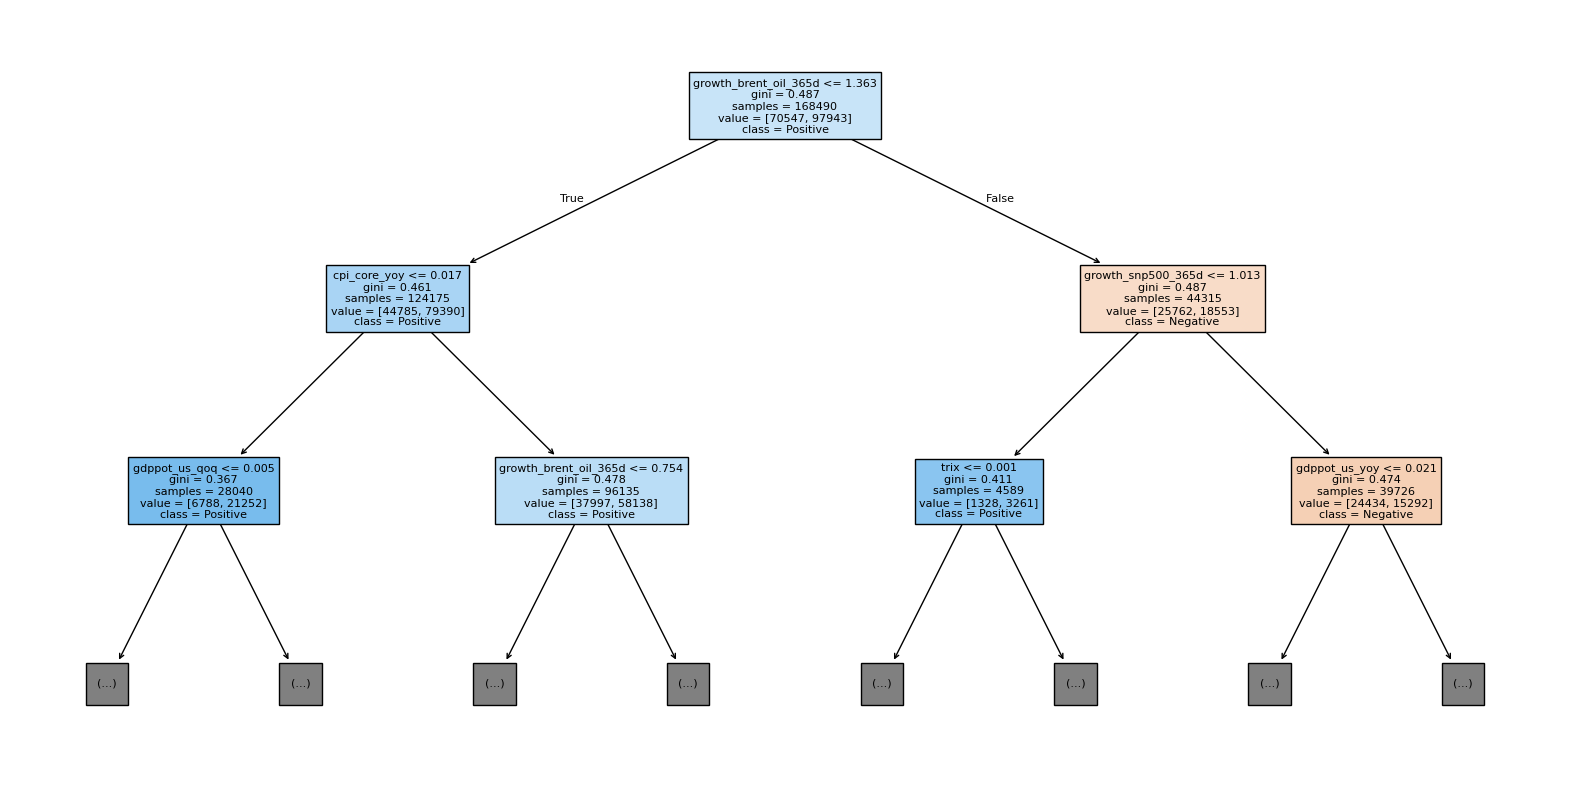

|--- growth_brent_oil_365d <= 1.36
|   |--- cpi_core_yoy <= 0.02
|   |   |--- gdppot_us_qoq <= 0.00
|   |   |   |--- ppo <= 1.00
|   |   |   |   |--- truncated branch of depth 16
|   |   |   |--- ppo >  1.00
|   |   |   |   |--- truncated branch of depth 16
|   |   |--- gdppot_us_qoq >  0.00
|   |   |   |--- ad <= -1147034.38
|   |   |   |   |--- truncated branch of depth 16
|   |   |   |--- ad >  -1147034.38
|   |   |   |   |--- truncated branch of depth 16
|   |--- cpi_core_yoy >  0.02
|   |   |--- growth_brent_oil_365d <= 0.75
|   |   |   |--- growth_dax_365d <= 1.07
|   |   |   |   |--- truncated branch of depth 16
|   |   |   |--- growth_dax_365d >  1.07
|   |   |   |   |--- truncated branch of depth 16
|   |   |--- growth_brent_oil_365d >  0.75
|   |   |   |--- growth_btc_usd_30d <= 1.22
|   |   |   |   |--- truncated branch of depth 16
|   |   |   |--- growth_btc_usd_30d >  1.22
|   |   |   |   |--- truncated branch of depth 16
|--- growth_brent_oil_365d >  1.36
|   |--- growth_

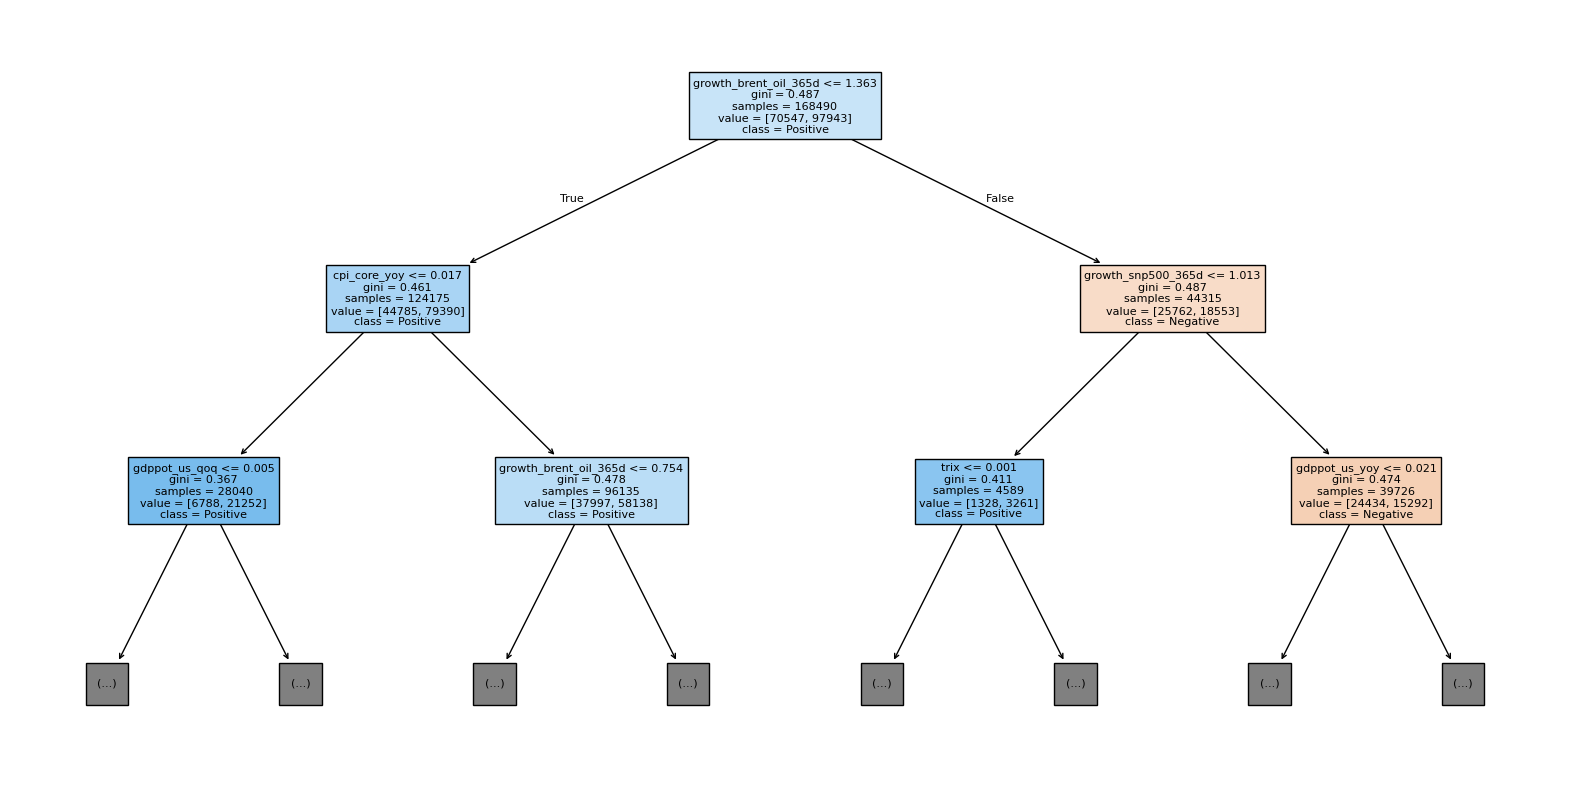

|--- growth_brent_oil_365d <= 1.36
|   |--- cpi_core_yoy <= 0.02
|   |   |--- gdppot_us_qoq <= 0.00
|   |   |   |--- ppo <= 1.00
|   |   |   |   |--- truncated branch of depth 17
|   |   |   |--- ppo >  1.00
|   |   |   |   |--- truncated branch of depth 17
|   |   |--- gdppot_us_qoq >  0.00
|   |   |   |--- ad <= -1147034.38
|   |   |   |   |--- truncated branch of depth 17
|   |   |   |--- ad >  -1147034.38
|   |   |   |   |--- truncated branch of depth 17
|   |--- cpi_core_yoy >  0.02
|   |   |--- growth_brent_oil_365d <= 0.75
|   |   |   |--- growth_dax_365d <= 1.07
|   |   |   |   |--- truncated branch of depth 17
|   |   |   |--- growth_dax_365d >  1.07
|   |   |   |   |--- truncated branch of depth 17
|   |   |--- growth_brent_oil_365d >  0.75
|   |   |   |--- growth_btc_usd_30d <= 1.22
|   |   |   |   |--- truncated branch of depth 17
|   |   |   |--- growth_btc_usd_30d >  1.22
|   |   |   |   |--- truncated branch of depth 17
|--- growth_brent_oil_365d >  1.36
|   |--- growth_

In [56]:
# (8min runtime) UNCOMMENT TO RUN IT AGAIN

# # hyper params tuning for a Decision Tree

precision_by_depth = {}
best_precision = 0
best_depth = 0

for depth in range(1,21):
  print(f'Working with a tree of a max depth= {depth}')
  # fitting the tree on X_train, y_train
  clf,train_columns = fit_decision_tree(X=X_train_valid,
                           y=y_train_valid,
                           max_depth=depth) #applying custom hyperparam
  # getting the predictions for TEST and accuracy score
  y_pred_valid = clf.predict(X_valid)
  precision_valid = precision_score(y_valid, y_pred_valid)
  y_pred_test = clf.predict(X_test)
  precision_test = precision_score(y_test, y_pred_test)
  print(f'  Precision on test is {precision_test}, (precision on valid is {precision_valid} - tend to overfit)')
  # saving to the dict
  precision_by_depth[depth] = round(precision_test,4)
  # updating the best precision
  if precision_test >= best_precision:
    best_precision = round(precision_test,4)
    best_depth = depth
    # plot tree - long
    plt.figure(figsize=(20,10))  # Set the size of the figure
    plot_tree(clf,
            filled=True,
            feature_names=train_columns,
            class_names=['Negative', 'Positive'],
            max_depth=2)
    plt.show()
    # plot tree - short
    tree_rules = export_text(clf, feature_names=list(X_train), max_depth=3)
    print(tree_rules)
    print('------------------------------')

print(f'All precisions by depth: {precision_by_depth}')
print(f'The best precision is {best_precision} and the best depth is {best_depth} ')

In [57]:
# Results of Hyper parameters tuning for a Decision Tree
print(precision_by_depth)

{1: 0.5904, 2: 0.5904, 3: 0.579, 4: 0.5655, 5: 0.5701, 6: 0.5678, 7: 0.5794, 8: 0.5734, 9: 0.5781, 10: 0.5773, 11: 0.5772, 12: 0.5945, 13: 0.573, 14: 0.5834, 15: 0.5775, 16: 0.5884, 17: 0.5903, 18: 0.5927, 19: 0.5959, 20: 0.5993}


In [58]:
# pre-calculated results of Hyperparameter tuning: full dataset (300 features) and is_positive_growth_5d
precision_by_depth = {1: 0.5904, 2: 0.5904, 3: 0.579, 4: 0.5655, 5: 0.5701, 6: 0.5678, 7: 0.5794, 8: 0.5734, 9: 0.5781, 10: 0.5773, 11: 0.5732, 12: 0.5935, 13: 0.5713, 14: 0.5834, 15: 0.5823, 16: 0.5892, 17: 0.5838, 18: 0.5919, 19: 0.5955, 20: 0.5923}


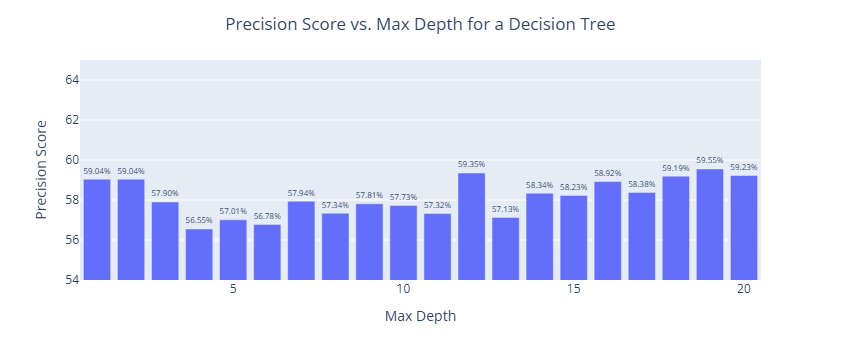

In [59]:
# Convert the dictionary to a DataFrame
df = pd.DataFrame(list(precision_by_depth.items()), columns=['max_depth', 'precision_score'])
df.loc[:,'precision_score'] = df.precision_score*100.0 # need for % visualisation

# Create the bar chart using Plotly Express
fig = px.bar(df,
             x='max_depth',
             y='precision_score',
            #  title='Precision Score vs. Max Depth for a Decision Tree',
             labels={'max_depth': 'Max Depth', 'precision_score': 'Precision Score'},
             range_y=[54, 65],
             text='precision_score')

# Update the text format to display as percentages
fig.update_traces(texttemplate='%{text:.2f}%', textposition='outside')

# Center the title
fig.update_layout(title={'text': 'Precision Score vs. Max Depth for a Decision Tree', 'x': 0.5, 'xanchor': 'center'})


# Show the figure
fig.show()

In [60]:
%%time
clf_5, train_columns = fit_decision_tree(X=X_train_valid,
                           y=y_train_valid,
                           max_depth=5)


# predict on a full dataset
y_pred_all = clf_5.predict(X_all)


# defining a new prediction vector is easy now, as the dimensions will match
new_df['pred6_clf_5'] = y_pred_all

CPU times: total: 0 ns
Wall time: 8.36 s


In [61]:
# MANUAL SECOND BEST, need some complexity for the threshhold rules
# found earlier in HyperParams Tuning
best_depth = 12
best_precision = precision_by_depth[best_depth]

In [62]:
%%time
clf_best,train_columns = fit_decision_tree(X=X_train_valid,
                           y=y_train_valid,
                           max_depth=best_depth)

CPU times: total: 0 ns
Wall time: 17.3 s


In [63]:
# For a DecisionTreeClassifier in scikit-learn, the concept of trainable parameters differs from that of neural networks.
# In decision trees, the parameters are the structure of the tree itself (nodes and splits) rather than weights.
# However, you can still get a sense of the model's complexity by looking at the number of nodes and leaves.

# Here's how you can get this information for your trained DecisionTreeClassifier (referred to as clf_best):

# Get the number of nodes and leaves in the tree
n_nodes = clf_best.tree_.node_count
n_leaves = clf_best.get_n_leaves()

print(f"Number of nodes: {n_nodes}")
print(f"Number of leaves: {n_leaves}")

Number of nodes: 2769
Number of leaves: 1385


In [64]:
clf_best

,criterion,'gini'
,splitter,'best'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [65]:
# predict on a full dataset
y_pred_clf_best = clf_best.predict(X_all)

In [66]:
# defining a new prediction vector is easy now, as the dimensions will match
new_df['pred6_clf_best'] = y_pred_clf_best

In [67]:
# new prediction is added --> need to recalculate the correctness
PREDICTIONS, IS_CORRECT = get_predictions_correctness(df = new_df, to_predict = to_predict)

Prediction columns founded: ['pred0_manual_cci', 'pred1_manual_prev_g1', 'pred2_manual_prev_g1_and_snp', 'pred3_manual_dgs10_5', 'pred4_manual_dgs10_fedfunds', 'pred5_clf_10', 'pred6_clf_5', 'pred6_clf_best']
Created columns is_correct: ['is_correct_pred0', 'is_correct_pred1', 'is_correct_pred2', 'is_correct_pred3', 'is_correct_pred4', 'is_correct_pred5', 'is_correct_pred6']
Precision on TEST set for each prediction:
Prediction column:pred0_manual_cci , is_correct_column: is_correct_pred0
is_correct_pred0
1    626
0    494
Name: count, dtype: int64
is_correct_pred0
1    0.558929
0    0.441071
Name: count, dtype: float64
---------
Prediction column:pred1_manual_prev_g1 , is_correct_column: is_correct_pred1
is_correct_pred1
1    21316
0    16825
Name: count, dtype: int64
is_correct_pred1
1    0.558874
0    0.441126
Name: count, dtype: float64
---------
Prediction column:pred2_manual_prev_g1_and_snp , is_correct_column: is_correct_pred2
is_correct_pred2
1    16432
0    13667
Name: count, 

## 1.3) Random Forest
https://scikit-learn.org/stable/modules/ensemble.html#random-forests-and-other-randomized-tree-ensembles

In [68]:
from sklearn.ensemble import RandomForestClassifier
import time

# (12 min runtime FOR v28 machine) UNCOMMENT BELOW TO RUN HYPERPARAMs optimisation again

In [69]:
%%time
# hyper params tuning

precision_matrix = {}
best_precision = 0
best_depth = 0
best_estimators = 1

for depth in [5, 7, 9, 11, 13, 15, 17, 19]:
  for estimators in [10,50,100,200]:
    print(f'Working with HyperParams: depth = {depth}, estimators = {estimators}')

    # Start timing
    start_time = time.time()
    # fitting the tree on X_train, y_train
    rf = RandomForestClassifier(n_estimators = estimators,
                                max_depth = depth,
                                random_state = 42,
                                n_jobs = -1)

    rf = rf.fit(X_train_valid, y_train_valid)

    # getting the predictions for TEST and accuracy score
    y_pred_valid = rf.predict(X_valid)
    precision_valid = precision_score(y_valid, y_pred_valid)
    y_pred_test = rf.predict(X_test)
    precision_test = precision_score(y_test, y_pred_test)
    print(f'  Precision on test is {precision_test}, (precision on valid is {precision_valid} - tend to overfit)')

    # saving to the dict
    precision_matrix[depth, estimators] = round(precision_test,4)

    # Measure elapsed time
    elapsed_time = time.time() - start_time
    print(f'Time for training: {elapsed_time:.2f} seconds, or {elapsed_time/60:.2f} minutes')

    # updating the best precision
    if precision_test >= best_precision:
      best_precision = round(precision_test,4)
      best_depth = depth
      best_estimators = estimators
      print(f'New best precision found for depth={depth}, estimators = {estimators}')

    print('------------------------------')

print(f'Matrix of precisions: {precision_matrix}')
print(f'The best precision is {best_precision} and the best depth is {best_depth} ')

Working with HyperParams: depth = 5, estimators = 10
  Precision on test is 0.5867604045529831, (precision on valid is 0.7688375508359693 - tend to overfit)
Time for training: 0.96 seconds, or 0.02 minutes
New best precision found for depth=5, estimators = 10
------------------------------
Working with HyperParams: depth = 5, estimators = 50
  Precision on test is 0.58844014854036, (precision on valid is 0.7619403398085118 - tend to overfit)
Time for training: 2.76 seconds, or 0.05 minutes
New best precision found for depth=5, estimators = 50
------------------------------
Working with HyperParams: depth = 5, estimators = 100
  Precision on test is 0.5827687465213135, (precision on valid is 0.7616866533422163 - tend to overfit)
Time for training: 4.86 seconds, or 0.08 minutes
------------------------------
Working with HyperParams: depth = 5, estimators = 200
  Precision on test is 0.5838589196997992, (precision on valid is 0.7653536282791112 - tend to overfit)
Time for training: 9.09 

In [70]:
# uncomment when you run the hyperparam tuning again
print(precision_matrix)

{(5, 10): 0.5868, (5, 50): 0.5884, (5, 100): 0.5828, (5, 200): 0.5839, (7, 10): 0.5955, (7, 50): 0.583, (7, 100): 0.5934, (7, 200): 0.6181, (9, 10): 0.588, (9, 50): 0.6063, (9, 100): 0.6174, (9, 200): 0.6085, (11, 10): 0.6204, (11, 50): 0.6343, (11, 100): 0.6193, (11, 200): 0.6364, (13, 10): 0.613, (13, 50): 0.6292, (13, 100): 0.6387, (13, 200): 0.6356, (15, 10): 0.6103, (15, 50): 0.6065, (15, 100): 0.6145, (15, 200): 0.6127, (17, 10): 0.6024, (17, 50): 0.6154, (17, 100): 0.6458, (17, 200): 0.6478, (19, 10): 0.6176, (19, 50): 0.6246, (19, 100): 0.6312, (19, 200): 0.6575}


In [71]:
# pre-calculated best precision matrix (max_depth, n_estimators) for Random Forest
best_precision_matrix_random_forest = {
    (5, 10): 0.5872,
    (5, 50): 0.59,
    (5, 100): 0.5837,
    (5, 200): 0.5843,
    (7, 10): 0.592,
    (7, 50): 0.581,
    (7, 100): 0.5962,
    (7, 200): 0.6158,
    (9, 10): 0.6072,
    (9, 50): 0.6242,
    (9, 100): 0.6254,
    (9, 200): 0.6074,
    (11, 10): 0.5895,
    (11, 50): 0.593,
    (11, 100): 0.6022,
    (11, 200): 0.6214,
    (13, 10): 0.6072,
    (13, 50): 0.6289,
    (13, 100): 0.6295,
    (13, 200): 0.6349,
    (15, 10): 0.6077,
    (15, 50): 0.6505,
    (15, 100): 0.6284,
    (15, 200): 0.6288,
    (17, 10): 0.6271,
    (17, 50): 0.6135,
    (17, 100): 0.6289,
    (17, 200): 0.6346,
    (19, 10): 0.599,
    (19, 50): 0.6329,
    (19, 100): 0.6316,
    (19, 200): 0.642
}

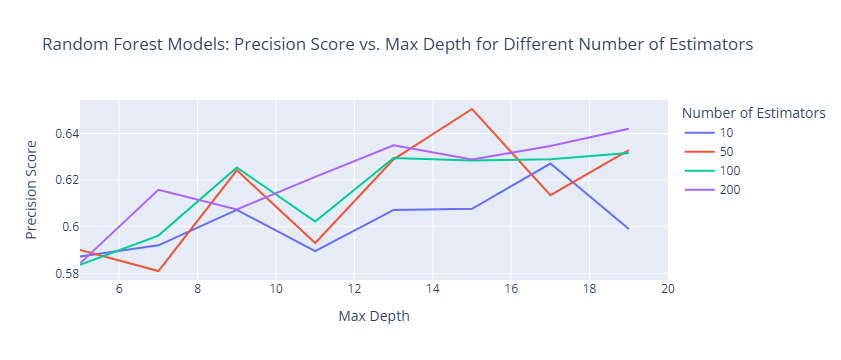

In [72]:

# Convert data to DataFrame
df = pd.DataFrame.from_dict(best_precision_matrix_random_forest, orient='index', columns=['precision_score']).reset_index()

# Rename the columns for clarity
df.columns = ['max_depth_and_metric', 'precision_score']

# Separate the tuple into two columns
df[['max_depth', 'n_estimators']] = pd.DataFrame(df['max_depth_and_metric'].tolist(), index=df.index)

# Drop the combined column
df = df.drop(columns=['max_depth_and_metric'])

# Create line plot using Plotly Express
fig = px.line(df, x='max_depth', y='precision_score', color='n_estimators',
              labels={'max_depth': 'Max Depth', 'precision_score': 'Precision Score', 'n_estimators': 'Number of Estimators'},
              title='Random Forest Models: Precision Score vs. Max Depth for Different Number of Estimators')

# Adjust x-axis range
fig.update_xaxes(range=[5, 20])

# Show the figure
fig.show()

In [73]:
# MANUALLY SELECTED BEST - should have enough complexity and smoothness (n_estimators)
rf_best_n_estimators = 50
# MANUALLY SELECTED BEST - should have enough complexity
rf_best_max_depth = 15

In [74]:
%%time

#
# several minutes to compute (2 min)

rf_best = RandomForestClassifier(n_estimators = rf_best_n_estimators,
                                 max_depth = rf_best_max_depth,
                                 random_state = 42,
                                 n_jobs = -1)

rf_best = rf_best.fit(X_train_valid, y_train_valid)

CPU times: total: 4.77 s
Wall time: 5.94 s


## 1.4 Logistic Regression

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

There can be many reasons when Logistic Regression does not converge: https://forecastegy.com/posts/how-to-solve-logistic-regression-not-converging-in-scikit-learn/

In [75]:
from sklearn.linear_model import LogisticRegression

In [76]:
# Large feature magnitudes can cause convergence issues. If you haven’t already, scale your data:
# (only for the Logistic regression, and maybe for the Neural Network)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_valid_scaled = scaler.fit_transform(X_train_valid)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

precision_matrix = {}
best_precision = 0
best_C = 0
best_iter = 0

for c in [1, 0.1, 0.01]:
  for iter in [50, 100, 200]:
    print(f'Working with HyperParams: C = {c} (positive float, smaller = stronger regularization), max_iter={iter}')
    # fitting the tree on X_train, y_train
      # hyperParam C should be between 0 and 1
    lr = LogisticRegression(C=c,
                            random_state=42,
                            max_iter=iter,
                            solver='sag',
                            n_jobs=-1)

    lr = lr.fit(X_train_valid_scaled, y_train_valid)

    # getting the predictions for TEST and accuracy score
    y_pred_valid = lr.predict(X_valid_scaled)
    precision_valid = precision_score(y_valid, y_pred_valid)
    y_pred_test = lr.predict(X_test_scaled)
    precision_test = precision_score(y_test, y_pred_test)
    print(f'  Precision on test is {precision_test}, (precision on valid is {precision_valid} - tend to overfit)')
    # saving to the dict
    precision_matrix[(c,iter)] = round(precision_test,4)
    # updating the best precision
    if precision_test >= best_precision:
      best_precision = round(precision_test,4)
      best_C = c
      best_iter = iter
      print(f'New best precision found for C={c}')
      print('------------------------------')

print(f'Matrix of precisions: {precision_matrix}')
print(f'The best precision is {best_precision} and the best C is {best_C}, best max_iter = {best_iter}  ')

Working with HyperParams: C = 1 (positive float, smaller = stronger regularization), max_iter=50


C:\Users\Zelric\.virtualenvs\FinMLOps-iZTr6dyZ\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



  Precision on test is 0.6295828977252245, (precision on valid is 0.7632577510411847 - tend to overfit)
New best precision found for C=1
------------------------------
Working with HyperParams: C = 1 (positive float, smaller = stronger regularization), max_iter=100


C:\Users\Zelric\.virtualenvs\FinMLOps-iZTr6dyZ\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



  Precision on test is 0.6351880752938179, (precision on valid is 0.7679235921607541 - tend to overfit)
New best precision found for C=1
------------------------------
Working with HyperParams: C = 1 (positive float, smaller = stronger regularization), max_iter=200


C:\Users\Zelric\.virtualenvs\FinMLOps-iZTr6dyZ\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



  Precision on test is 0.6433473544387868, (precision on valid is 0.7703139571028909 - tend to overfit)
New best precision found for C=1
------------------------------
Working with HyperParams: C = 0.1 (positive float, smaller = stronger regularization), max_iter=50


C:\Users\Zelric\.virtualenvs\FinMLOps-iZTr6dyZ\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



  Precision on test is 0.6296403189148237, (precision on valid is 0.7633032051084307 - tend to overfit)
Working with HyperParams: C = 0.1 (positive float, smaller = stronger regularization), max_iter=100


C:\Users\Zelric\.virtualenvs\FinMLOps-iZTr6dyZ\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



  Precision on test is 0.635172193877551, (precision on valid is 0.767909198040067 - tend to overfit)
Working with HyperParams: C = 0.1 (positive float, smaller = stronger regularization), max_iter=200


C:\Users\Zelric\.virtualenvs\FinMLOps-iZTr6dyZ\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



  Precision on test is 0.6434005219612416, (precision on valid is 0.7703231821006836 - tend to overfit)
New best precision found for C=0.1
------------------------------
Working with HyperParams: C = 0.01 (positive float, smaller = stronger regularization), max_iter=50


C:\Users\Zelric\.virtualenvs\FinMLOps-iZTr6dyZ\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



  Precision on test is 0.63025271019905, (precision on valid is 0.762665927500077 - tend to overfit)
Working with HyperParams: C = 0.01 (positive float, smaller = stronger regularization), max_iter=100


C:\Users\Zelric\.virtualenvs\FinMLOps-iZTr6dyZ\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



  Precision on test is 0.6350251840371949, (precision on valid is 0.7669854830222552 - tend to overfit)
Working with HyperParams: C = 0.01 (positive float, smaller = stronger regularization), max_iter=200
  Precision on test is 0.6428653459661211, (precision on valid is 0.7699038163201986 - tend to overfit)
Matrix of precisions: {(1, 50): 0.6296, (1, 100): 0.6352, (1, 200): 0.6433, (0.1, 50): 0.6296, (0.1, 100): 0.6352, (0.1, 200): 0.6434, (0.01, 50): 0.6303, (0.01, 100): 0.635, (0.01, 200): 0.6429}
The best precision is 0.6434 and the best C is 0.1, best max_iter = 200  


C:\Users\Zelric\.virtualenvs\FinMLOps-iZTr6dyZ\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



In [77]:
# UNCOMMENT TO SEE THE RESULTS OF THE RUN
print(precision_matrix)

{(1, 50): 0.6296, (1, 100): 0.6352, (1, 200): 0.6433, (0.1, 50): 0.6296, (0.1, 100): 0.6352, (0.1, 200): 0.6434, (0.01, 50): 0.6303, (0.01, 100): 0.635, (0.01, 200): 0.6429}


In [78]:
# Params on C, iter
best_precision_matrix_logistic_regression = {(1, 50): 0.6296, (1, 100): 0.6352, (1, 200): 0.6433, (0.1, 50): 0.6296, (0.1, 100): 0.6352, (0.1, 200): 0.6434, (0.01, 50): 0.6303, (0.01, 100): 0.635, (0.01, 200): 0.6429}


In [79]:
list(best_precision_matrix_logistic_regression.items())[0]

((1, 50), 0.6296)

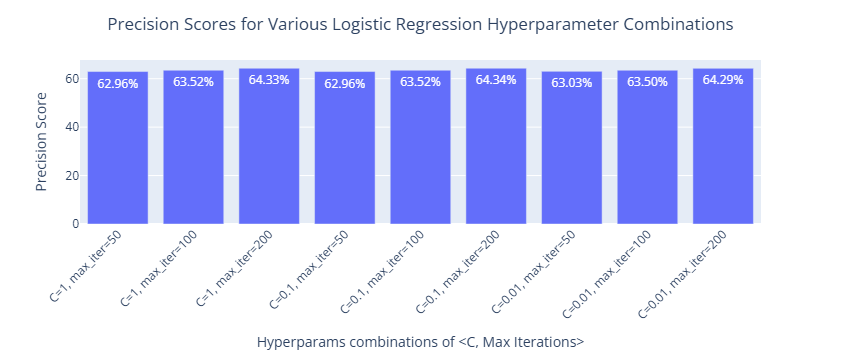

In [80]:
# Visualise precision scores

# Prepare the data
rows = []
for key, value in list(best_precision_matrix_logistic_regression.items()):
    C, max_iter = key
    combination_label = f'C={C}, max_iter={max_iter}'
    rows.append({'Combination': combination_label, 'Precision': value})

df = pd.DataFrame(rows)
df.loc[:,'Precision'] = df.Precision*100.0 # need for % visualisation

# Create the bar chart
fig = px.bar(df,
             x='Combination',
             y='Precision',
             text='Precision'
             )

# Customize the layout for better readability
fig.update_layout(
    xaxis_title='Hyperparams combinations of <C, Max Iterations>',
    yaxis_title='Precision Score',
    xaxis_tickangle=-45,
    title={
        'text': 'Precision Scores for Various Logistic Regression Hyperparameter Combinations',
        'y':0.95,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top'
    }
)


# Update the text position
fig.update_traces(texttemplate='%{text:.2f}%',
                  textposition='inside',
                  textfont_color='white')

# Show the figure
fig.show()

## 1.5) ADVANCED: Deep Neural Network (DNN) and hyperparams tuning
* Tutorial from Tensorflow.org
* TowardsDataScience Hyperparameter Optimization with Keras
* Machine Learning Mastery tutorial with Keras Deep Learning

In [81]:
# https://towardsdatascience.com/hyperparameter-optimization-with-keras-b82e6364ca53


# Extended params set

# p = {'lr': [0.01, 0.03,0.1, 0.3,1,3,10],
#      'first_neuron': [0,16,32,64,128,256],
#      'second_neuron':[0,16,32,64,128,256],
#      'first_dropout':[0,0.2,0.3],
#      'second_dropout':[0,0.2,0.3],
#      'activation_first':['relu','sigmoid','linear'],
#      'activation_second':['relu','sigmoid','linear'],
#     #  'activation_first':('relu','elu','tanh','sigmoid','linear','softplus','selu', 'softsign','exponential'),
#     #  'activation_second':('relu','elu','tanh','sigmoid','linear','softplus','selu', 'softsign','exponential'),
#     #  'batch_size':(2,30,10),
#     #  'loss': ('mse','mae'),
#     #  'epochs':[150],
#     #  'shape': ['brick','long_funnel'],
#      'optimizer':['adam', 'nadam', 'rmaprop','sgd'],
#     #  'losses': [logcosh, binary_crossentropy],
#     #  'last_activation':[sigmoid]
#      }


# Reduced params set and available options
p = {'lr': [0.1],
     'first_neuron': [12,24,32,48,96, 128, 196, 256],
     'second_neuron':[12,24,32,48,96, 128, 196, 256],
     'first_dropout':[0.1],
     'second_dropout':[0.1],
     'activation_first':['relu','sigmoid','softplus','tanh'],
     'activation_second':['relu'],
    #  'activation_first':('relu','elu','tanh','sigmoid','linear','softplus','selu', 'softsign','exponential'),
    #  'activation_second':('relu','elu','tanh','sigmoid','linear','softplus','selu', 'softsign','exponential'),
    #  'batch_size':(2,30,10),
    #  'loss': ('mse','mae'),
    #  'epochs':[150],
    #  'shape': ['brick','long_funnel'],
     'optimizer':['adam','nadam','sgd','rmaprop'],
    #  'losses': [logcosh, binary_crossentropy],
    #  'last_activation':[sigmoid]
     }


# Number of models to run and write to SHEETS:
count_models=0

nn_params = {}

for lr in p['lr']:
  for first_neuron in p['first_neuron']:
    for second_neuron in p['second_neuron']:
      for first_dropout in p['first_dropout']:
        for second_dropout in p['second_dropout']:
          for activation_first in p['activation_first']:
            for activation_second in p['activation_second']:
              for optimizer in p['optimizer']:
                # print(lr,first_neuron,second_neuron,first_dropout,second_dropout,activation_first,activation_second,optimizer,sep='/')
                count_models=count_models+1
                nn_params['learning_rate'] = lr
                nn_params['first_layer_neurons'] = first_neuron
                nn_params['first_layer_dropout'] = first_dropout
                nn_params['second_layer_neurons'] = second_neuron
                nn_params['second_layer_dropout'] = second_dropout
                nn_params['activation_first_layer'] = activation_first
                nn_params['activation_second_layer'] = activation_second
                nn_params['optimizer'] = optimizer
                # features count as an input shape
                nn_params['input_shape'] = len(X_train.keys())

# Current set of models to try
print(count_models)

1024


In [82]:
# example of a Neural Network HyperParams setup
nn_params

{'learning_rate': 0.1,
 'first_layer_neurons': 256,
 'first_layer_dropout': 0.1,
 'second_layer_neurons': 256,
 'second_layer_dropout': 0.1,
 'activation_first_layer': 'tanh',
 'activation_second_layer': 'relu',
 'optimizer': 'rmaprop',
 'input_shape': 314}

In [83]:
import tensorflow as tf
import keras
from keras import layers
# from keras.models import Sequential
# from keras.layers import Dense, Input, Dropout, Activation

In [84]:
# building one Neural Network when Parameters are known:
import datetime

# len(rez_train.keys())
def build_model(nn_params):
  # lr, first_neuron, second_neuron, first_dropout, second_dropout, activation_first, activation_second, optimizer
  model = keras.Sequential([
  layers.Dense(nn_params['first_layer_neurons'],
               activation=nn_params['activation_first_layer'],
               input_shape=[nn_params['input_shape']]),
  layers.Dropout(nn_params['first_layer_dropout']),
  layers.Dense(nn_params['second_layer_neurons'],
               activation=nn_params['activation_second_layer']),
  layers.Dropout(nn_params['second_layer_dropout']),
  layers.Dense(1, activation='sigmoid') # sigmoid is important for a Neural Network
  ])

  if optimizer == 'adam':
    opt = keras.optimizers.Adam(lr)
  elif optimizer == 'nadam':
    opt = keras.optimizers.Nadam(lr)
  elif optimizer == 'rmsprop':
    opt = keras.optimizers.RMSprop(lr)
  elif optimizer == 'sgd':
    opt = keras.optimizers.SGD(lr)
  else:
    opt = keras.optimizers.Adagrad(lr)
  model.compile(loss='binary_crossentropy', # mae/rmse for the Regression,
                optimizer=opt,
                metrics=['accuracy',keras.metrics.Precision()]) # or use [keras.metrics.Precision()] for a binary model : https://keras.io/api/metrics/classification_metrics/#precision-class
  return model

In [85]:
nn_params

{'learning_rate': 0.1,
 'first_layer_neurons': 256,
 'first_layer_dropout': 0.1,
 'second_layer_neurons': 256,
 'second_layer_dropout': 0.1,
 'activation_first_layer': 'tanh',
 'activation_second_layer': 'relu',
 'optimizer': 'rmaprop',
 'input_shape': 314}

In [86]:
# construct a model based on those hyperparams
model = build_model(nn_params)
model.summary()
# model.get_config()

C:\Users\Zelric\.virtualenvs\FinMLOps-iZTr6dyZ\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        80,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 146,689 (573.00 KB)

 Trainable params: 146,689 (573.00 KB)

 Non-trainable params: 0 (0.00 B)

In [87]:
# trainable params in the model with max params (large hidden layers shape)
model.count_params()

146689

In [88]:
# Display training progress by printing a single dot for each completed epoch
class PrintDot(keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs):
    if epoch % 100 == 0: print()
    print('.', end='')

In [89]:
# read tutorial about Binary Classification with Neural Network
# https://machinelearningmastery.com/binary-classification-tutorial-with-the-keras-deep-learning-library/
# https://www.tensorflow.org/api_docs/python/tf/keras/Model#fit


# HYPER_PARAMS_SPACE = PARAMS space
# WHEN MAX_MODELS>0: return after MAX_MODELS checked
# MAX_EPOCHS: how many epochs (periods when model weights are updated) do we need?
def train_neural_network_with_hyperparams(HYPER_PARAMS_SPACE, MAX_MODELS=0, MAX_EPOCHS=250, EARLY_STOPPING_PATIENCE=20):

  # The patience parameter is the amount of epochs to check for improvement
  early_stop = keras.callbacks.EarlyStopping(monitor='val_accuracy',  # we want accuracy to improve every single iteration (or at least in several iterations (EARLY STOPPING PARAM))
                                             patience = EARLY_STOPPING_PATIENCE)
  nn_params = {} # current hyperParams settings
  cur = 0 # models trained

  # best stats
  best_accuracy = 0
  best_model = None
  best_history = None

  for lr in HYPER_PARAMS_SPACE['lr']:
    for first_dropout in HYPER_PARAMS_SPACE['first_dropout']:
      for second_dropout in HYPER_PARAMS_SPACE['second_dropout']:
        for activation_first in HYPER_PARAMS_SPACE['activation_first']:
          for activation_second in HYPER_PARAMS_SPACE['activation_second']:
            for optimizer in HYPER_PARAMS_SPACE['optimizer']:
              for first_neuron in HYPER_PARAMS_SPACE['first_neuron']:
                for second_neuron in HYPER_PARAMS_SPACE['second_neuron']:
                  cur = cur+1

                  nn_params['learning_rate'] = lr
                  nn_params['first_layer_neurons'] = first_neuron
                  nn_params['first_layer_dropout'] = first_dropout
                  nn_params['second_layer_neurons'] = second_neuron
                  nn_params['second_layer_dropout'] = second_dropout
                  nn_params['activation_first_layer'] = activation_first
                  nn_params['activation_second_layer'] = activation_second
                  nn_params['optimizer'] = optimizer

                  # features count as an input shape
                  nn_params['input_shape'] = len(X_train.keys())

                  print(f'Using HyperParams:{nn_params}')

                  model = build_model(nn_params)
                  # model.summary()

                  frame = pd.DataFrame(data=[cur,lr,first_neuron,second_neuron,first_dropout,second_dropout, activation_first, activation_second, optimizer])

                  print(f"Training model {cur} with trainable params {model.count_params()} :")
                  t_start = datetime.datetime.now()
                  history = model.fit(
                                        X_train_valid,
                                        y_train_valid,
                                        epochs=MAX_EPOCHS,
                                        validation_data = (X_test, y_test),
                                        verbose=1, #change to 0 if you don't want to see the progress
                                        callbacks=[early_stop,PrintDot()])

                  t_diff = datetime.datetime.now() - t_start
                  frame = pd.DataFrame(data=[t_diff.seconds,
                                          len(history.epoch),
                                          history.history['val_accuracy'][0], # start of learning
                                          history.history['val_accuracy'][len(history.epoch)-1], # end of learning
                                          #  history.history['val_precision_2'][0], # start of learning
                                          #  history.history['val_precision_2'][len(history.epoch)-1], # end of learning
                                          ])

                  if history.history['val_accuracy'][len(history.epoch)-1]> best_accuracy:
                    best_accuracy = history.history['val_accuracy'][len(history.epoch)-1]
                    best_model = model
                    best_history = history

                  # early stopping of hyper params loop
                  if MAX_MODELS>0 and cur>=MAX_MODELS:
                    return best_model, best_history.history

                  print('==============================================================')

  return best_model, best_history.history #full hyper params search on all models

In [90]:
# returns best_model (trained) and best_history (history of train operations)
best_model, best_history = train_neural_network_with_hyperparams(HYPER_PARAMS_SPACE=p,
                                                                 MAX_MODELS=2, #not more than 2 models
                                                                 MAX_EPOCHS=250,
                                                                 EARLY_STOPPING_PATIENCE=10
                                                                 )

Using HyperParams:{'learning_rate': 0.1, 'first_layer_neurons': 12, 'first_layer_dropout': 0.1, 'second_layer_neurons': 12, 'second_layer_dropout': 0.1, 'activation_first_layer': 'relu', 'activation_second_layer': 'relu', 'optimizer': 'adam', 'input_shape': 314}
Training model 1 with trainable params 3949 :
Epoch 1/250
5265/5266 ━━━━━━━━━━━━━━━━━━━━ 0s 750us/step - accuracy: 0.5499 - loss: 9686.4521 - precision_1: 0.5804
5266/5266 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.5582 - loss: 1693.9037 - precision_1: 0.5800 - val_accuracy: 0.5902 - val_loss: 0.6816 - val_precision_1: 0.5904
Epoch 2/250
5266/5266 ━━━━━━━━━━━━━━━━━━━━ 5s 966us/step - accuracy: 0.5799 - loss: 13.5548 - precision_1: 0.5817 - val_accuracy: 0.5904 - val_loss: 0.6810 - val_precision_1: 0.5904
Epoch 3/250
5266/5266 ━━━━━━━━━━━━━━━━━━━━ 5s 967us/step - accuracy: 0.5806 - loss: 8.0615 - precision_1: 0.5816 - val_accuracy: 0.5904 - val_loss: 0.6784 - val_precision_1: 0.5904
Epoch 4/250
5266/5266 ━━━━━━━━━━━━━━━━━━━━

C:\Users\Zelric\.virtualenvs\FinMLOps-iZTr6dyZ\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



5240/5266 ━━━━━━━━━━━━━━━━━━━━ 0s 736us/step - accuracy: 0.5482 - loss: 11335.7266 - precision_2: 0.5822
5266/5266 ━━━━━━━━━━━━━━━━━━━━ 6s 998us/step - accuracy: 0.5616 - loss: 2156.3269 - precision_2: 0.5830 - val_accuracy: 0.5727 - val_loss: 3.4052 - val_precision_2: 0.5876
Epoch 2/250
5266/5266 ━━━━━━━━━━━━━━━━━━━━ 5s 965us/step - accuracy: 0.5736 - loss: 22.4725 - precision_2: 0.5819 - val_accuracy: 0.5874 - val_loss: 1.7434 - val_precision_2: 0.5897
Epoch 3/250
5266/5266 ━━━━━━━━━━━━━━━━━━━━ 5s 968us/step - accuracy: 0.5740 - loss: 12.1830 - precision_2: 0.5809 - val_accuracy: 0.5881 - val_loss: 0.8352 - val_precision_2: 0.5903
Epoch 4/250
5266/5266 ━━━━━━━━━━━━━━━━━━━━ 5s 973us/step - accuracy: 0.5755 - loss: 12.5094 - precision_2: 0.5808 - val_accuracy: 0.5838 - val_loss: 0.7584 - val_precision_2: 0.5896
Epoch 5/250
5266/5266 ━━━━━━━━━━━━━━━━━━━━ 5s 959us/step - accuracy: 0.5776 - loss: 4.8777 - precision_2: 0.5809 - val_accuracy: 0.5894 - val_loss: 0.7083 - val_precision_2: 0.5

In [91]:
# UNCOMMENT TO RUN AGAIN

best_history_nn = best_history
best_model_nn = best_model

In [92]:
best_model_nn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 12)             │         3,780 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 12)             │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            13 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,900 (30.86 KB)

 Trainable params: 3,949 (15.43 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,951 (15.44 KB)

In [93]:
best_history_nn

{'accuracy': [0.5581814646720886,
  0.5799038410186768,
  0.5806338787078857,
  0.580693244934082,
  0.5806635618209839,
  0.5809721350669861,
  0.5797139406204224,
  0.5803015232086182,
  0.5803371071815491,
  0.5805270075798035,
  0.5808653235435486,
  0.5808950066566467],
 'loss': [1693.9036865234375,
  13.554765701293945,
  8.061511993408203,
  10.666525840759277,
  3.187089681625366,
  2.894958019256592,
  3.8035993576049805,
  7.6089887619018555,
  13.8145751953125,
  2.5228917598724365,
  2.414543867111206,
  1.3398650884628296],
 'precision_1': [0.5799968838691711,
  0.5817280411720276,
  0.5816436409950256,
  0.5815846920013428,
  0.5812864303588867,
  0.5814937949180603,
  0.5812873244285583,
  0.5815033912658691,
  0.5813003778457642,
  0.5813230872154236,
  0.581464409828186,
  0.5815293788909912],
 'val_accuracy': [0.5901559591293335,
  0.5904326438903809,
  0.5904326438903809,
  0.5904326438903809,
  0.5904326438903809,
  0.5903838276863098,
  0.589895486831665,
  0.59025

In [94]:
X_train_valid.shape

(168490, 314)

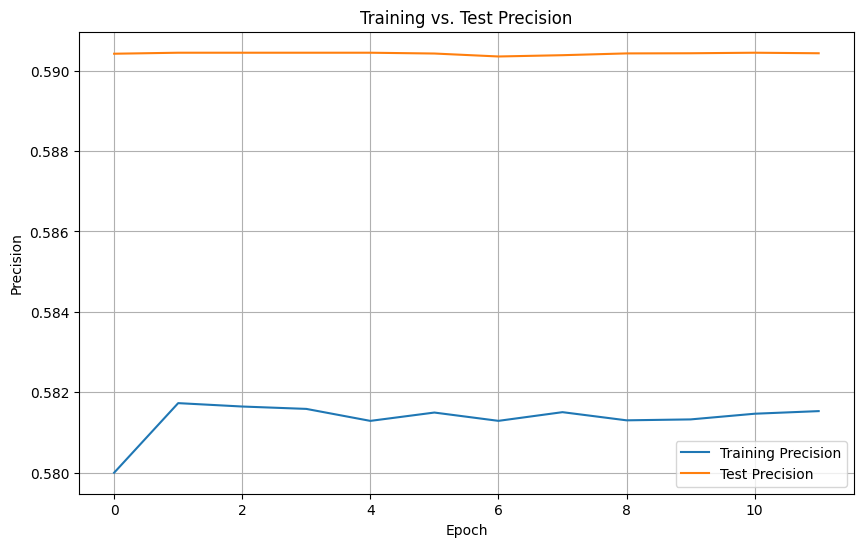

In [96]:
# Learning visualisation for the Deep Neural Network (DNN)
# The model is not actually training, as the precision and accuracy score are not improving on TRAIN/TEST with more Epochs

# Plotting accuracy
plt.figure(figsize=(10, 6))
plt.plot(best_history_nn['precision_1'], label='Training Precision')
plt.plot(best_history_nn['val_precision_1'], label='Test Precision')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.title('Training vs. Test Precision')
plt.legend()
plt.grid(True)
plt.show()

# 2) Different Decision rules to improve precision (varying threshold)

best model1 **(clf_best)**: Decision Tree (max_depth=14 - manually selected second-best model)
best model2 **(rf_best)**: Random Forest (n_estimators=50, max_depth=19)

## 2.1. Predicting probabilities (predict_proba), getting the distribution for probabilities, and new decision rules

In [97]:
# y_pred_test = best_lr.predict_proba(X_test)

# predicting probability instead of a lable

y_pred_test = rf_best.predict_proba(X_test)
y_pred_test_class1 = [k[1] for k in y_pred_test] # k[1] is the second element in the list of Class predictions

In [98]:
# example prediction of probabilities
y_pred_test

array([[0.4240729 , 0.5759271 ],
       [0.5565966 , 0.4434034 ],
       [0.53304957, 0.46695043],
       ...,
       [0.48782386, 0.51217614],
       [0.51502408, 0.48497592],
       [0.46976867, 0.53023133]], shape=(61438, 2))

In [99]:
y_pred_test_class1_df = pd.DataFrame(y_pred_test_class1, columns=['Class1_probability'])
y_pred_test_class1_df.head()

,Class1_probability
0,0.575927
1,0.443403
2,0.466950
3,0.443041
4,0.523300


In [100]:
# Mean prediction is 0.54, median is 0.55, 75% quantile is 0.60
y_pred_test_class1_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Class1_probability,61438.0,0.504015,0.090587,0.18939,0.440873,0.497252,0.559841,0.901123


In [101]:
# Unconditional probability of a positive growth is 55.5%
y_test.sum()/y_test.count()

np.float64(0.5904489078420522)

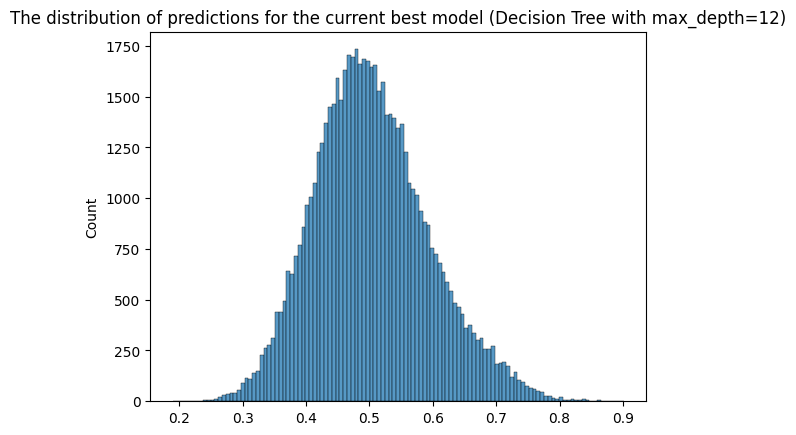

In [102]:
# perfect shape for a Random Forest predictions vs. a Decision Tree - it's an average across many trees (estimators)
sns.histplot(y_pred_test_class1)

# Add a title
plt.title('The distribution of predictions for the current best model (Decision Tree with max_depth=12)')

# Show the plot
plt.show()

In [103]:
# tpr (True Positive Rate) vs. fpr (False Positive Rate) dataframe
# tp = True Positive
# tn = True Negative
# fp = False Positive
# fn = False Negative
# Decision Rule :  "y_pred>= Threshold" for Class "1"

# when only_even=True --> we'll have a step ==0.02 and leave only even records

def tpr_fpr_dataframe(y_true, y_pred, only_even=False):
    scores = []

    if only_even==False:
      thresholds = np.linspace(0, 1, 101) #[0, 0.01, 0.02, ...0.99,1.0]
    else:
      thresholds = np.linspace(0, 1, 51) #[0, 0.02, 0.04,  ...0.98,1.0]

    for t in thresholds:

        actual_positive = (y_true == 1)
        actual_negative = (y_true == 0)

        predict_positive = (y_pred >= t)
        predict_negative = (y_pred < t)

        tp = (predict_positive & actual_positive).sum()
        tn = (predict_negative & actual_negative).sum()

        fp = (predict_positive & actual_negative).sum()
        fn = (predict_negative & actual_positive).sum()

        if tp + fp > 0:
          precision = tp / (tp + fp)

        if tp + fn > 0:
          recall = tp / (tp + fn)

        if precision+recall > 0:
          f1_score = 2*precision*recall / (precision+recall)

        accuracy = (tp+tn) / (tp+tn+fp+fn)

        scores.append((t, tp, fp, fn, tn, precision, recall, accuracy, f1_score))

    columns = ['threshold', 'tp', 'fp', 'fn', 'tn','precision','recall', 'accuracy','f1_score']
    df_scores = pd.DataFrame(scores, columns=columns)

    df_scores['tpr'] = df_scores.tp / (df_scores.tp + df_scores.fn)
    df_scores['fpr'] = df_scores.fp / (df_scores.fp + df_scores.tn)

    return df_scores


In [104]:
df_scores = tpr_fpr_dataframe(y_test,
                              y_pred_test_class1,
                              only_even=True)

In [105]:
# full df_scores
df_scores

,threshold,tp,fp,fn,tn,precision,recall,accuracy,f1_score,tpr,fpr
0,0.00,36276,25162,0,0,0.590449,1.000000,0.590449,0.742493,1.000000,1.000000
1,0.02,36276,25162,0,0,0.590449,1.000000,0.590449,0.742493,1.000000,1.000000
2,0.04,36276,25162,0,0,0.590449,1.000000,0.590449,0.742493,1.000000,1.000000
3,0.06,36276,25162,0,0,0.590449,1.000000,0.590449,0.742493,1.000000,1.000000
4,0.08,36276,25162,0,0,0.590449,1.000000,0.590449,0.742493,1.000000,1.000000
5,0.10,36276,25162,0,0,0.590449,1.000000,0.590449,0.742493,1.000000,1.000000
6,0.12,36276,25162,0,0,0.590449,1.000000,0.590449,0.742493,1.000000,1.000000
7,0.14,36276,25162,0,0,0.590449,1.000000,0.590449,0.742493,1.000000,1.000000
8,0.16,36276,25162,0,0,0.590449,1.000000,0.590449,0.742493,1.000000,1.000000
9,0.18,36276,25162,0,0,0.590449,1.000000,0.590449,0.742493,1.000000,1.000000


In [106]:
df_scores[(df_scores.threshold>=0.5) & (df_scores.threshold<=0.8)]

,threshold,tp,fp,fn,tn,precision,recall,accuracy,f1_score,tpr,fpr
25,0.50,18165,11785,18111,13377,0.606511,0.500744,0.513396,0.548576,0.500744,0.468365
26,0.52,15171,9414,21105,15748,0.617084,0.418210,0.503255,0.498546,0.418210,0.374136
27,0.54,12430,7327,23846,17835,0.629144,0.342651,0.492610,0.443667,0.342651,0.291193
28,0.56,9943,5376,26333,19786,0.649063,0.274093,0.483886,0.385425,0.274093,0.213656
29,0.58,7873,3971,28403,21191,0.664725,0.217031,0.473062,0.327224,0.217031,0.157817
30,0.60,6099,2858,30177,22304,0.680920,0.168128,0.462303,0.269670,0.168128,0.113584
31,0.62,4679,1975,31597,23187,0.703186,0.128983,0.453563,0.217983,0.128983,0.078491
32,0.64,3530,1343,32746,23819,0.724400,0.097310,0.445148,0.171572,0.097310,0.053374
33,0.66,2598,935,33678,24227,0.735352,0.071618,0.436619,0.130523,0.071618,0.037159
34,0.68,1837,611,34439,24551,0.750408,0.050640,0.429506,0.094877,0.050640,0.024283


<Axes: title={'center': 'Precision vs. Recall for the Best Model (Decision Tree with max_depth=12)'}, xlabel='threshold'>

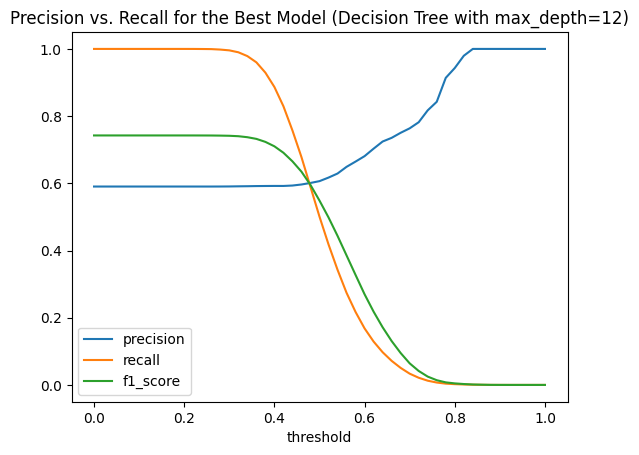

In [107]:
# Try to find high Precision score points

df_scores.plot.line(x='threshold',
                    y=['precision','recall', 'f1_score'],
                    title = 'Precision vs. Recall for the Best Model (Decision Tree with max_depth=12)')

## 2.2) Defining new columns with Predictions in new_df: pred7..pred10
* pred7 and pred8 are 2 decision rules for the Decision Tree (best model with max_depth=12)
* pred9 and pred10 are 2 decision rules for the Random Forest (second best model)

In [108]:
# adding Decision Tree predictors (clf_best) to the dataset for 2 new rules based on thresholds


y_pred_all = clf_best.predict_proba(X_all)
y_pred_all_class1 = [k[1] for k in y_pred_all] #list of predictions for class "1"
y_pred_all_class1_array = np.array(y_pred_all_class1) # (Numpy Array) np.array of predictions for class "1" , converted from a list

# defining a new prediction vector is easy now, as the dimensions will match
new_df['proba_pred8'] = y_pred_all_class1_array
new_df['pred8_clf_second_best_rule_84'] = (y_pred_all_class1_array >= 0.84).astype(int)

new_df['proba_pred9'] = y_pred_all_class1_array
new_df['pred9_clf_second_best_rule_92'] = (y_pred_all_class1_array >= 0.92).astype(int)

In [110]:
# adding Random Forest predictors (rf_best)
rf_best

,n_estimators,50
,criterion,'gini'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [111]:
# make predictions of probabilities using the Random Forest model (rf_best)

y_pred_all = rf_best.predict_proba(X_all)
y_pred_all_class1 = [k[1] for k in y_pred_all] #list of predictions for class "1"
y_pred_all_class1_array = np.array(y_pred_all_class1) # (Numpy Array) np.array of predictions for class "1" , converted from a list


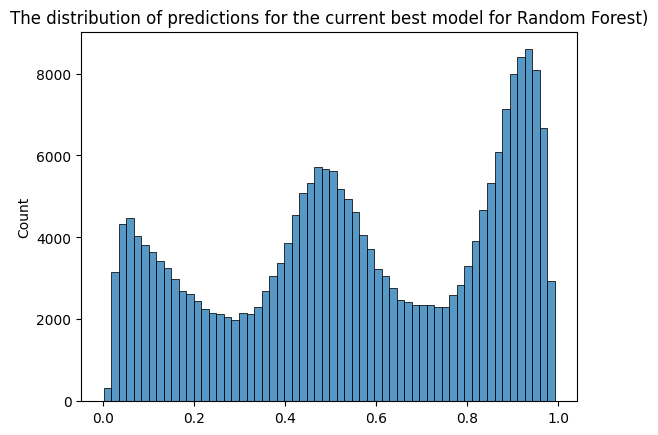

In [112]:
# PREDICTIONS ON A FULL DATASET - different from on a TRAINED SET (too optimistic? or just a bullish environment?)
sns.histplot(y_pred_all_class1)

# Add a title
plt.title('The distribution of predictions for the current best model for Random Forest)')

# Show the plot
plt.show()

In [113]:
# adding Random Forest predictors (rf_best) to the dataset for 2 new rules, based on Thresholds
# defining a new prediction vector is easy now, as the dimensions will match
new_df['proba_pred10'] = y_pred_all_class1_array
new_df['pred10_rf_best_rule_55'] = (y_pred_all_class1_array >= 0.55).astype(int)

new_df['proba_pred11'] = y_pred_all_class1_array
new_df['pred11_rf_best_rule_65'] = (y_pred_all_class1_array >= 0.65).astype(int)

<Axes: >

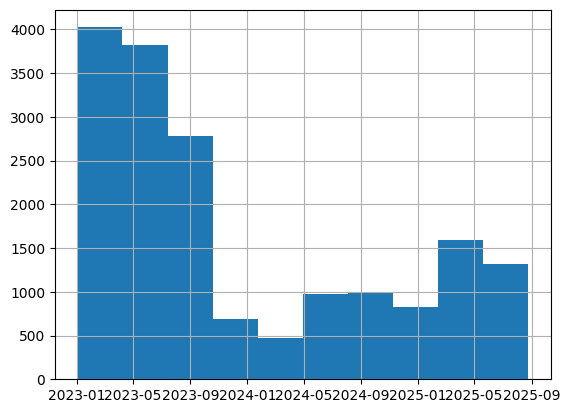

In [114]:
# Many positive predictions
new_df[(new_df.split=='test')&(new_df.pred10_rf_best_rule_55==1)].Date.hist()

<Axes: >

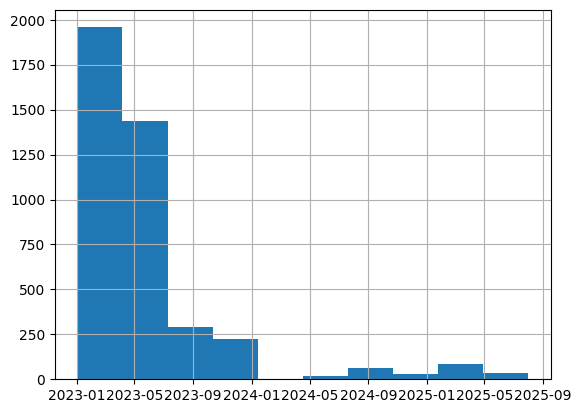

In [115]:
# Vs. less positives on higher-threshold rule
new_df[(new_df.split=='test')&(new_df.pred11_rf_best_rule_65==1)].Date.hist()

In [116]:
# sample of rare predictions with high threshold vs. other predictions
new_df[(new_df.split=='test')&(new_df.pred11_rf_best_rule_65==1)].sort_values(by='Date').sample(10)

,Open,High,Low,Close_x,Volume,Dividends,Stock Splits,Capital Gains,Ticker,Year,...,pred6_clf_best,is_correct_pred6,proba_pred8,pred8_clf_second_best_rule_84,proba_pred9,pred9_clf_second_best_rule_92,proba_pred10,pred10_rf_best_rule_55,proba_pred11,pred11_rf_best_rule_65
2256,3083.000000,3084.000000,3067.500000,3084.250000,781.0,0.0,0.0,0.0,IE00B8X9NY41,2023,...,1,0,0.788190,0,0.788190,0,0.770812,1,0.770812,1
3858,102.360001,102.839996,101.739998,102.599998,25598.0,0.0,0.0,0.0,LU1681047236,2023,...,0,0,0.459144,0,0.459144,0,0.669225,1,0.669225,1
1970,98.592870,98.912120,98.574094,99.700867,40.0,0.0,0.0,0.0,LU0629460675,2023,...,1,1,0.941748,1,0.941748,1,0.742162,1,0.742162,1
3163,12.924000,12.968000,12.858000,12.858000,216875.0,0.0,0.0,0.0,LU1291098827,2023,...,1,1,0.910575,1,0.910575,0,0.664748,1,0.664748,1
848,6.470000,6.477000,6.456000,6.444000,1218.0,0.0,0.0,0.0,IE00BJLKK341,2023,...,1,1,0.788190,0,0.788190,0,0.695910,1,0.695910,1
1507,80.250610,80.250610,80.250610,80.250610,0.0,0.0,0.0,0.0,LU1481201702,2023,...,1,1,0.955527,1,0.955527,1,0.726025,1,0.726025,1
1225,31.775000,31.775000,30.915001,31.315001,8154.0,0.0,0.0,0.0,LU2195226068,2025,...,1,1,0.707965,0,0.707965,0,0.689278,1,0.689278,1
690,65.570000,66.129997,65.400002,65.930000,291.0,0.0,0.0,0.0,LU2182388582,2023,...,1,1,0.814978,0,0.814978,0,0.701696,1,0.701696,1
837,6.472000,6.480000,6.466000,6.495000,3557.0,0.0,0.0,0.0,IE00BJLKK341,2023,...,1,1,0.788190,0,0.788190,0,0.668507,1,0.668507,1
1549,82.240746,82.240746,82.240746,82.240746,0.0,0.0,0.0,0.0,LU1481201702,2023,...,1,1,0.910575,1,0.910575,0,0.824344,1,0.824344,1


In [117]:
# List of ALL current predictions
PREDICTIONS = [k for k in new_df.keys() if k.startswith('pred')]
PREDICTIONS

['pred0_manual_cci',
 'pred1_manual_prev_g1',
 'pred2_manual_prev_g1_and_snp',
 'pred3_manual_dgs10_5',
 'pred4_manual_dgs10_fedfunds',
 'pred5_clf_10',
 'pred6_clf_5',
 'pred6_clf_best',
 'pred8_clf_second_best_rule_84',
 'pred9_clf_second_best_rule_92',
 'pred10_rf_best_rule_55',
 'pred11_rf_best_rule_65']

In [118]:
# Pred 10: How many positive prediction per day (out of 109 ETFs possible)
pred10_daily_positive_count = pd.DataFrame(new_df[(new_df.split=='test')&(new_df.pred11_rf_best_rule_65==1)].groupby('Date')['pred11_rf_best_rule_65'].count())

In [119]:
# Pred 9: How many positive prediction per day (out of 109 ETFs possible)
pred9_daily_positive_count = pd.DataFrame(new_df[(new_df.split=='test')&(new_df.pred10_rf_best_rule_55==1)].groupby('Date')['pred10_rf_best_rule_55'].count())

In [120]:
# Unique trading days on Test (4 years)
new_df[(new_df.split=='test')].Date.nunique()

678

In [121]:
pred10_daily_positive_count

,pred11_rf_best_rule_65
Date,
2023-01-02,8
2023-01-03,76
2023-01-04,67
2023-01-05,67
2023-01-06,68
...,...
2025-06-13,4
2025-06-16,1
2025-06-17,1


array([[<Axes: title={'center': 'pred11_rf_best_rule_65'}>]], dtype=object)

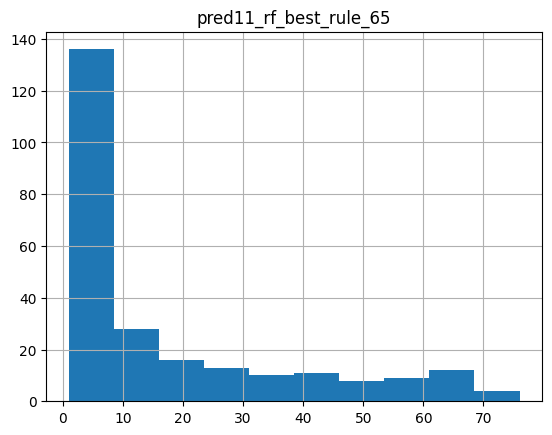

In [122]:
pred10_daily_positive_count.hist()

In [123]:
# 75% cases we have not more than 6 bets of $100
pred10_daily_positive_count.describe().T

,count,mean,std,min,25%,50%,75%,max
pred11_rf_best_rule_65,247.0,16.757085,20.616655,1.0,2.0,6.0,27.0,76.0


array([[<Axes: title={'center': 'pred10_rf_best_rule_55'}>]], dtype=object)

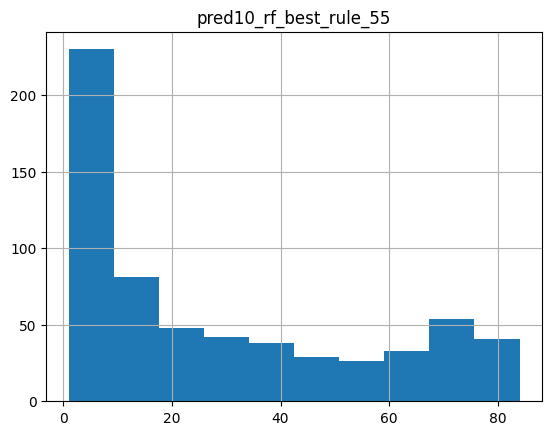

In [124]:
pred9_daily_positive_count.hist()

In [125]:
pred9_daily_positive_count.describe().T

,count,mean,std,min,25%,50%,75%,max
pred10_rf_best_rule_55,622.0,28.110932,26.743228,1.0,4.0,17.5,50.0,84.0


## 2.3) Agg. stats on ALL predictions

In [126]:
# let's review the Predictions:
PREDICTIONS, IS_CORRECT = get_predictions_correctness(new_df, to_predict=to_predict)


Prediction columns founded: ['pred0_manual_cci', 'pred1_manual_prev_g1', 'pred2_manual_prev_g1_and_snp', 'pred3_manual_dgs10_5', 'pred4_manual_dgs10_fedfunds', 'pred5_clf_10', 'pred6_clf_5', 'pred6_clf_best', 'pred8_clf_second_best_rule_84', 'pred9_clf_second_best_rule_92', 'pred10_rf_best_rule_55', 'pred11_rf_best_rule_65']
Created columns is_correct: ['is_correct_pred0', 'is_correct_pred1', 'is_correct_pred2', 'is_correct_pred3', 'is_correct_pred4', 'is_correct_pred5', 'is_correct_pred6', 'is_correct_pred8', 'is_correct_pred9', 'is_correct_pred10', 'is_correct_pred11']
Precision on TEST set for each prediction:
Prediction column:pred0_manual_cci , is_correct_column: is_correct_pred0
is_correct_pred0
1    626
0    494
Name: count, dtype: int64
is_correct_pred0
1    0.558929
0    0.441071
Name: count, dtype: float64
---------
Prediction column:pred1_manual_prev_g1 , is_correct_column: is_correct_pred1
is_correct_pred1
1    21316
0    16825
Name: count, dtype: int64
is_correct_pred1
1  

In [127]:
# check approx. periods : Train, Valid , Test
new_df.groupby('split').Date.agg(['min','max'])

,min,max
split,,
test,2023-01-02,2025-08-25
train,2008-01-02,2020-05-08
validation,2020-05-11,2022-12-30


In [128]:
# Extract number from the prediction column

# Example string
example_string = "pred10_rf_best_rule_60"

# Split the string by '_'
parts = example_string.split('_')

# Extract the part with 'pred' and remove the 'pred' prefix
pred_number = parts[0].replace('pred', '')

# Print the result
print(pred_number)

# Print in one line
print(int(example_string.split('_')[0].replace('pred', '')))


10
10


In [129]:
# all predictions
PREDICTIONS

['pred0_manual_cci',
 'pred1_manual_prev_g1',
 'pred2_manual_prev_g1_and_snp',
 'pred3_manual_dgs10_5',
 'pred4_manual_dgs10_fedfunds',
 'pred5_clf_10',
 'pred6_clf_5',
 'pred6_clf_best',
 'pred8_clf_second_best_rule_84',
 'pred9_clf_second_best_rule_92',
 'pred10_rf_best_rule_55',
 'pred11_rf_best_rule_65']

In [130]:
# all predictions on MODELS (not-manual predictions)
PREDICTIONS_ON_MODELS = [p for p in PREDICTIONS if int(p.split('_')[0].replace('pred', ''))>=5]
PREDICTIONS_ON_MODELS

['pred5_clf_10',
 'pred6_clf_5',
 'pred6_clf_best',
 'pred8_clf_second_best_rule_84',
 'pred9_clf_second_best_rule_92',
 'pred10_rf_best_rule_55',
 'pred11_rf_best_rule_65']

In [131]:
# all predictions on Models - correctness
IS_CORRECT_ON_MODELS = [p for p in IS_CORRECT if int(p.replace('is_correct_pred', ''))>=5]
IS_CORRECT_ON_MODELS

['is_correct_pred5',
 'is_correct_pred6',
 'is_correct_pred8',
 'is_correct_pred9',
 'is_correct_pred10',
 'is_correct_pred11']

In [132]:
# predictions on models
# pred10_rf_best_rule_60: ONLY 2% of TEST cases predicted with high confidence of growth
new_df.groupby('split')[PREDICTIONS_ON_MODELS].agg(['count','sum','mean']).T

split                                        test          train    validation
pred5_clf_10                  count  61438.000000  116456.000000  52034.000000
                              sum    42892.000000   72580.000000  28983.000000
                              mean       0.698135       0.623240      0.557001
pred6_clf_5                   count  61438.000000  116456.000000  52034.000000
                              sum    47038.000000   71852.000000  31720.000000
                              mean       0.765617       0.616988      0.609601
pred6_clf_best                count  61438.000000  116456.000000  52034.000000
                              sum    27622.000000   67150.000000  29523.000000
                              mean       0.449591       0.576613      0.567379
pred8_clf_second_best_rule_84 count  61438.000000  116456.000000  52034.000000
                              sum    12582.000000   47712.000000  25420.000000
                              mean       0.204792       0.409700      0.488527
pred9_clf_second_best_rule_92 count  61438.000000  116456.000000  52034.000000
                              sum     7370.000000   28006.000000  21063.000000
                              mean       0.119958       0.240486      0.404793
pred10_rf_best_rule_55        count  61438.000000  116456.000000  52034.000000
                              sum    17485.000000   67601.000000  30544.000000
                              mean       0.284596       0.580485      0.587001
pred11_rf_best_rule_65        count  61438.000000  116456.000000  52034.000000
                              sum     4139.000000   61606.000000  28716.000000
                              mean       0.067369       0.529007      0.551870

In [133]:
# 11 predictions stats (check TEST set)
new_df.groupby('split')[PREDICTIONS].agg(['count','sum','mean']).T

split                                        test          train    validation
pred0_manual_cci              count  61438.000000  116456.000000  52034.000000
                              sum     1120.000000    1978.000000    704.000000
                              mean       0.018230       0.016985      0.013530
pred1_manual_prev_g1          count  61438.000000  116456.000000  52034.000000
                              sum    38141.000000   65229.000000  30849.000000
                              mean       0.620805       0.560117      0.592862
pred2_manual_prev_g1_and_snp  count  61438.000000  116456.000000  52034.000000
                              sum    30099.000000   53268.000000  26262.000000
                              mean       0.489909       0.457409      0.504708
pred3_manual_dgs10_5          count  61438.000000  116456.000000  52034.000000
                              sum        0.000000   14228.000000  26759.000000
                              mean       0.000000       0.122175      0.514260
pred4_manual_dgs10_fedfunds   count  61438.000000  116456.000000  52034.000000
                              sum    21178.000000     378.000000   1360.000000
                              mean       0.344705       0.003246      0.026137
pred5_clf_10                  count  61438.000000  116456.000000  52034.000000
                              sum    42892.000000   72580.000000  28983.000000
                              mean       0.698135       0.623240      0.557001
pred6_clf_5                   count  61438.000000  116456.000000  52034.000000
                              sum    47038.000000   71852.000000  31720.000000
                              mean       0.765617       0.616988      0.609601
pred6_clf_best                count  61438.000000  116456.000000  52034.000000
                              sum    27622.000000   67150.000000  29523.000000
                              mean       0.449591       0.576613      0.567379
pred8_clf_second_best_rule_84 count  61438.000000  116456.000000  52034.000000
                              sum    12582.000000   47712.000000  25420.000000
                              mean       0.204792       0.409700      0.488527
pred9_clf_second_best_rule_92 count  61438.000000  116456.000000  52034.000000
                              sum     7370.000000   28006.000000  21063.000000
                              mean       0.119958       0.240486      0.404793
pred10_rf_best_rule_55        count  61438.000000  116456.000000  52034.000000
                              sum    17485.000000   67601.000000  30544.000000
                              mean       0.284596       0.580485      0.587001
pred11_rf_best_rule_65        count  61438.000000  116456.000000  52034.000000
                              sum     4139.000000   61606.000000  28716.000000
                              mean       0.067369       0.529007      0.551870

# 3) Trading Simulations

* create simulation 1 features: like "sim1_pred0" ... "sim1_predLast"

## 3.1) Investing 100€ on every positive prediction
* fees = 0.08% for each buy and sell operation ==> 0.016% for buy+sell operation

In [134]:
# current prediction
pred = 'pred6_clf_best'

In [135]:
# Total Number of Investment Opportunities
new_df[new_df.split=='test'].Close_x.count()

np.int64(61429)

In [136]:
# Total Number of Days (~4 years of trading)
new_df[new_df.split=='test'].Date.nunique()

678

In [137]:
# check actual future growth with 'growth_future_5d', correctness of the prediction with 'is_positive_growth_5d_future'
TO_PREDICT

['growth_future_30d', 'is_positive_growth_30d_future']

In [138]:
# Sample
new_df[['growth_future_30d','is_positive_growth_30d_future',pred]].sample(5)

,growth_future_30d,is_positive_growth_30d_future,pred6_clf_best
2952,1.009371,1,0
91,1.009650,1,0
2100,0.918080,0,1
1857,0.970259,0,0
528,1.031550,1,1


In [139]:
# GROSS REVENUE: ONLY when current_prediction equals to 1: invest $100 into that stock (buy), and sell in 1week (sell)
new_df['sim1_gross_rev_pred6'] = new_df[pred] * 100 * (new_df['growth_future_30d']-1)

In [140]:
# FEES: 0.08% for each operation , 0.16% for buy+sell ONLY when current_prediction equals to one
new_df['sim1_fees_pred6'] = -new_df[pred] * 100 * 0.0016

In [141]:
# NET REVENUE: GROSS_REVENUE + FEES
new_df['sim1_net_rev_pred6'] = new_df['sim1_gross_rev_pred6'] + new_df['sim1_fees_pred6']

In [142]:
# sample of individual results
COLUMNS_FIN_RESULT = ['Date','Ticker','Close_x']+TO_PREDICT+ [pred,  'sim1_gross_rev_pred6','sim1_fees_pred6','sim1_net_rev_pred6']
new_df[(new_df.split=='test')&(new_df[pred]==1)][COLUMNS_FIN_RESULT].sample(5)

,Date,Ticker,Close_x,growth_future_30d,is_positive_growth_30d_future,pred6_clf_best,sim1_gross_rev_pred6,sim1_fees_pred6,sim1_net_rev_pred6
917,2024-01-29,LU2195226068,28.379999,1.040874,1,1,4.087392,-0.16,3.927392
3929,2023-05-18,FR0010150458,11.669126,1.000334,1,1,0.033369,-0.16,-0.126631
3951,2023-06-12,FR0010468983,41.419998,1.027402,1,1,2.740227,-0.16,2.580227
1590,2025-07-08,FR0013412285,42.903000,1.043820,1,1,4.381980,-0.16,4.221980
1154,2023-05-29,FR0011871136,15.312000,1.040818,1,1,4.081766,-0.16,3.921766


In [143]:
# DAILY INVESTMENTS COUNT
filter_test_and_positive_pred = (new_df.split=='test')&(new_df[pred]==1)
df_investments_count_daily = pd.DataFrame(new_df[filter_test_and_positive_pred].groupby('Date')[pred].count())
sim1_avg_investments_per_day = df_investments_count_daily[pred].quantile(0.75)  # 75% case - how many 100€ investments per day do we have?
print(sim1_avg_investments_per_day)

78.0


In [144]:
# Distribution: how many times do we trade daily (for the current Prediction)?
df_investments_count_daily.describe().T

,count,mean,std,min,25%,50%,75%,max
pred6_clf_best,669.0,41.28849,36.721588,1.0,7.0,16.0,78.0,106.0


In [145]:
new_df[(new_df.split=='test')&(new_df[pred]==1)][['sim1_gross_rev_pred6','sim1_fees_pred6','sim1_net_rev_pred6']].sum()

sim1_gross_rev_pred6    43846.420284
sim1_fees_pred6         -4419.520000
sim1_net_rev_pred6      39689.460284
dtype: float64

### 3.1.2 Calculate fin. results for all fields
* Simplified and approximate calculation

In [147]:
# Calculate fin. result for ALL predictions (manual and produced by models)

sim1_results = [] # results in Array

# Iterate over all predictions
for pred in PREDICTIONS:
  print(f'Calculating sumulation for prediction {pred}:')
  print(f"    Count times of investment {len(new_df[(new_df.split=='test')&(new_df[pred]==1)])} out of {len(new_df[(new_df.split=='test')])} TEST records")

  # Prefix: e.g. pred1 or pred10
  pred_prefix= pred.split('_')[0]

  # Fin. result columns: define new records for EACH positive prediction
  new_df['sim1_gross_rev_'+pred_prefix] = new_df[pred] * 100 * (new_df['growth_future_30d']-1)
  new_df['sim1_fees_'+pred_prefix] = -new_df[pred] * 100 * 0.0016
  new_df['sim1_net_rev_'+pred_prefix] = new_df['sim1_gross_rev_'+pred_prefix] + new_df['sim1_fees_'+pred_prefix]

  # calculate agg. results for each PREDICTION columns (pred) on TEST
  filter_test_and_positive_pred = (new_df.split=='test')&(new_df[pred]==1) # filter records on TEST set, when current prediction is 1 (we invest $100 for 1 week ahead - 5 periods)
  sim1_count_investments = len(new_df[filter_test_and_positive_pred])
  sim1_gross_rev = new_df[filter_test_and_positive_pred]['sim1_gross_rev_'+pred_prefix].sum()
  sim1_fees = new_df[filter_test_and_positive_pred]['sim1_fees_'+pred_prefix].sum()
  sim1_net_rev = new_df[filter_test_and_positive_pred]['sim1_net_rev_'+pred_prefix].sum()

  if sim1_gross_rev>0:
    sim1_fees_percentage = -sim1_fees/sim1_gross_rev
  else:
    sim1_fees_percentage = None

  if sim1_count_investments>0:
    sim1_average_net_revenue = sim1_net_rev/sim1_count_investments
  else:
    sim1_average_net_revenue = None

  # APPROXIMATE CAPITAL REQUIRED and CAGR Calculation
  df_investments_count_daily = pd.DataFrame(new_df[filter_test_and_positive_pred].groupby('Date')[pred].count())
  sim1_avg_investments_per_day = df_investments_count_daily[pred].mean()
  sim1_q75_investments_per_day = df_investments_count_daily[pred].quantile(0.75)  # 75% case - how many $100 investments per day do we have?
  # df_investments_count_daily[pred].mean()
  sim1_capital = 100 * 30 * sim1_q75_investments_per_day # 30 days in a row with positive predictions

  # CAGR: average growth per year. E.g. if you have 1.5 return (50% growth in 4 years) --> (1.5)**(1/4) = 1.106 or 10.6% average
  sim1_CAGR = ((sim1_capital+sim1_net_rev)/sim1_capital)**(1/4)

  # append to DF
  sim1_results.append((pred,sim1_count_investments,sim1_gross_rev,sim1_fees,sim1_net_rev,sim1_fees_percentage,sim1_average_net_revenue,sim1_avg_investments_per_day,sim1_capital,sim1_CAGR))


  # output for all predictions with some positive predictions
  if  sim1_count_investments>1:
    print(f"    Financial Result: \n {new_df[filter_test_and_positive_pred][['sim1_gross_rev_'+pred_prefix,'sim1_fees_'+pred_prefix,'sim1_net_rev_'+pred_prefix]].sum()}")
    print(f"        Count Investments in 4 years (on TEST): {sim1_count_investments}")
    print(f"        Gross Revenue: ${int(sim1_gross_rev)}")
    print(f"        Fees (0.16% for buy+sell): ${int(-sim1_fees)}")
    print(f"        Net Revenue: ${int(sim1_net_rev)}")
    print(f"        Fees are {int(-100.0*sim1_fees/sim1_gross_rev)} % from Gross Revenue")
    print(f"        Capital Required : ${int(sim1_capital)} (Vbegin)")
    print(f"        Final value (Vbegin + Net_revenue) : ${int(sim1_capital + sim1_net_rev)} (Vfinal)")

    print(f"        Average CAGR on TEST (4 years) : {np.round(sim1_CAGR,3)}, or {np.round(100.0*(sim1_CAGR-1),1)}% ")

    print(f"        Average daily stats: ")
    print(f"            Average net revenue per investment: ${np.round(sim1_net_rev/sim1_count_investments,2)} ")
    print(f"            Average investments per day: {int(np.round(sim1_avg_investments_per_day))} ")
    print(f"            Q75 investments per day: {int(np.round(sim1_q75_investments_per_day))} ")
    print('=============================================+')


# results in a DataFrame from an Array
columns_simulation = ['prediction', 'sim1_count_investments', 'sim1_gross_rev', 'sim1_fees', 'sim1_net_rev', 'sim1_fees_percentage','sim1_average_net_revenue','sim1_avg_investments_per_day','sim1_capital','sim1_CAGR']

df_sim1_results = pd.DataFrame(sim1_results,columns=columns_simulation)

Calculating sumulation for prediction pred0_manual_cci:
    Count times of investment 1120 out of 61438 TEST records
    Financial Result: 
 sim1_gross_rev_pred0    1128.406683
sim1_fees_pred0         -179.200000
sim1_net_rev_pred0       959.926683
dtype: float64
        Count Investments in 4 years (on TEST): 1120
        Gross Revenue: $1128
        Fees (0.16% for buy+sell): $179
        Net Revenue: $959
        Fees are 15 % from Gross Revenue
        Capital Required : $12000 (Vbegin)
        Final value (Vbegin + Net_revenue) : $12959 (Vfinal)
        Average CAGR on TEST (4 years) : 1.019, or 1.9% 
        Average daily stats: 
            Average net revenue per investment: $0.86 
            Average investments per day: 4 
            Q75 investments per day: 4 
=============================================+
Calculating sumulation for prediction pred1_manual_prev_g1:
    Count times of investment 38141 out of 61438 TEST records
    Financial Result: 
 sim1_gross_rev_pred1    

In [148]:
df_sim1_results['sim1_growth_capital_4y'] = (df_sim1_results.sim1_net_rev+df_sim1_results.sim1_capital) / df_sim1_results.sim1_capital

In [150]:
# final comparison
df_sim1_results

,prediction,sim1_count_investments,sim1_gross_rev,sim1_fees,sim1_net_rev,sim1_fees_percentage,sim1_average_net_revenue,sim1_avg_investments_per_day,sim1_capital,sim1_CAGR,sim1_growth_capital_4y
0,pred0_manual_cci,1120,1128.406683,-179.20,959.926683,0.158808,0.857077,4.307692,12000.0,1.019425,1.079994
1,pred1_manual_prev_g1,38141,34883.461832,-6102.56,29166.181832,0.174941,0.764694,56.255162,225000.0,1.030941,1.129627
2,pred2_manual_prev_g1_and_snp,30099,24907.929689,-4815.84,20476.569689,0.193346,0.680307,65.149351,234000.0,1.021193,1.087507
3,pred3_manual_dgs10_5,0,0.000000,0.00,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
4,pred4_manual_dgs10_fedfunds,21178,40264.265100,-3388.48,37399.785100,0.084156,1.765973,101.330144,321000.0,1.027935,1.116510
5,pred5_clf_10,42892,55799.178586,-6862.72,49365.258586,0.122990,1.150920,63.355982,279000.0,1.041569,1.176936
6,pred6_clf_5,47038,57736.036288,-7526.08,50733.476288,0.130353,1.078564,91.513619,297000.0,1.040214,1.170820
7,pred6_clf_best,27622,43846.420284,-4419.52,39689.460284,0.100795,1.436879,41.288490,234000.0,1.039945,1.169613
8,pred8_clf_second_best_rule_84,12582,32112.415361,-2013.12,30128.575361,0.062690,2.394578,18.863568,42000.0,1.144760,1.717347
9,pred9_clf_second_best_rule_92,7370,21523.117726,-1179.20,20353.677726,0.054788,2.761693,12.003257,21000.0,1.184605,1.969223


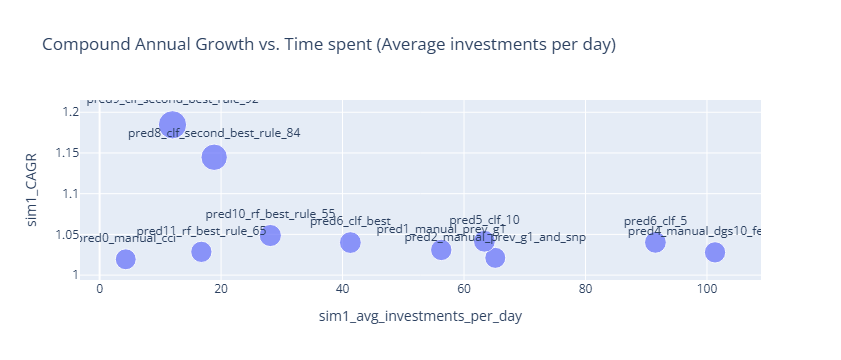

In [151]:
# Create the scatter plot
fig = px.scatter(
    df_sim1_results.dropna(),
    x='sim1_avg_investments_per_day',
    y='sim1_CAGR',
    size='sim1_growth_capital_4y',  # Use the 'size' parameter for sim1_CAGR
    text='prediction',
    title='Compound Annual Growth vs. Time spent (Average investments per day)',
    labels={'sim1_capital': 'Initial Capital Requirement', 'growth_capital_4y': '4-Year Capital Growth'}
)

# Update the layout to improve readability of the annotations
fig.update_traces(textposition='top center')

# Show the plot
fig.show()

In [152]:
# detailed info from the bubble chart above on the winners
# top 1 result
df_sim1_results[df_sim1_results.prediction.isin(['pred9_clf_second_best_rule_92'])]

,prediction,sim1_count_investments,sim1_gross_rev,sim1_fees,sim1_net_rev,sim1_fees_percentage,sim1_average_net_revenue,sim1_avg_investments_per_day,sim1_capital,sim1_CAGR,sim1_growth_capital_4y
9,pred9_clf_second_best_rule_92,7370,21523.117726,-1179.2,20353.677726,0.054788,2.761693,12.003257,21000.0,1.184605,1.969223


In [153]:
# top 2-3 results
df_sim1_results[df_sim1_results.prediction.isin(['pred8_clf_second_best_rule_84','pred10_rf_best_rule_55'])]

,prediction,sim1_count_investments,sim1_gross_rev,sim1_fees,sim1_net_rev,sim1_fees_percentage,sim1_average_net_revenue,sim1_avg_investments_per_day,sim1_capital,sim1_CAGR,sim1_growth_capital_4y
8,pred8_clf_second_best_rule_84,12582,32112.415361,-2013.12,30128.575361,0.062690,2.394578,18.863568,42000.0,1.144760,1.717347
10,pred10_rf_best_rule_55,17485,34130.287457,-2797.60,31375.727457,0.081968,1.794437,28.110932,150000.0,1.048629,1.209172


## 3.2. Advanced Simulation
* to_predict = 'is_positive_growth_30d_future'
* invest ~3% of capital each day (sell positions from 30 days ago), REINVEST PREVIOUS GAINS
* use predict_proba predictions
* select top1..3..x predictions > threshold (0.53)
* invest proportionally the prediction
* stop loss y%
* take profit z%
* Not included: portfolio optimization

### 3.2.1) [Code Snippet 1] Define rank of prediction (pred_14_rf_best_rule_53)
*  Current best prediction pred9_clf_second_best_rule_92, with CAGR = 1.184605 (18.46% average capital growth with simple simulation)

In [154]:
# https://stackoverflow.com/questions/17775935/sql-like-window-functions-in-pandas-row-numbering-in-python-pandas-dataframe
# rank of prediction

new_df["pred9_rank"] = new_df.groupby("Date")["proba_pred9"].rank(method="first", ascending=False)

new_df["pred10_rank"] = new_df.groupby("Date")["proba_pred10"].rank(method="first", ascending=False)


In [156]:
# CHECK RANK FOR 1 DAY:
  # we have predictions for all 109 ETFs
first_trading_day_2024 = new_df[new_df.Date>='2024-01-04'].Date.unique().astype(str)[0]
first_trading_day_2024
print(f'First trading day in 2024: {first_trading_day_2024}, count predictions = {len(new_df[new_df.Date==first_trading_day_2024])}')

First trading day in 2024: 2024-01-04, count predictions = 80


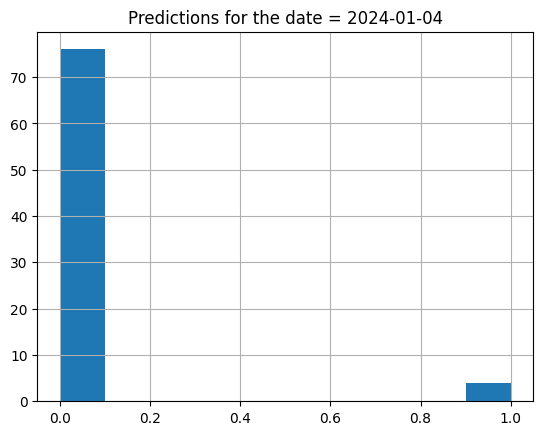

In [157]:
# Decision Tree's predictions are not very smooth - either too small or too big
new_df[new_df.Date==first_trading_day_2024].proba_pred9.hist()
plt.title(f'Predictions for the date = {first_trading_day_2024}')
# Show the plot
plt.show()

In [158]:
new_df[new_df.Date==first_trading_day_2024][['Date','Ticker', 'Close_x','proba_pred9','pred9_rank']].sort_values(by='pred9_rank').head(5)

,Date,Ticker,Close_x,proba_pred9,pred9_rank
3985,2024-01-04,FR0010591362,10.4800,1.000000,1.0
4097,2024-01-04,FR0010411884,0.8562,1.000000,2.0
4097,2024-01-04,FR0010424135,9.4150,1.000000,3.0
2039,2024-01-04,LU1327051279,7.5480,1.000000,4.0
3997,2024-01-04,FR0010592014,36.5200,0.016649,5.0


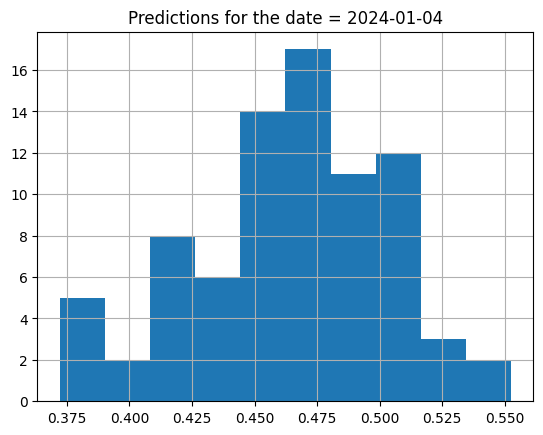

In [159]:
# Random Forest's predictions are more spreaded across the range - rank() function will work
new_df[new_df.Date==first_trading_day_2024].proba_pred10.hist()
plt.title(f'Predictions for the date = {first_trading_day_2024}')
# Show the plot
plt.show()

In [160]:
# It is quite different vs. a single Decision tree (proba_pred9 vs. proba_pred10)
new_df[new_df.Date==first_trading_day_2024][['Date','Ticker', 'Close_x','proba_pred9','proba_pred10','pred10_rank']].sort_values(by='pred10_rank').head(5)

,Date,Ticker,Close_x,proba_pred9,proba_pred10,pred10_rank
2472,2024-01-04,FR0011869320,24.358000,0.016649,0.552488,1.0
4093,2024-01-04,LU1681046931,119.599998,0.016649,0.540100,2.0
3997,2024-01-04,FR0010592014,36.520000,0.016649,0.524174,3.0
533,2024-01-04,DE000A2QP372,7.041200,0.016649,0.519863,4.0
533,2024-01-04,DE000A2QP380,4.733100,0.016649,0.516750,5.0


In [161]:
# OUTCOME: let's use pred10_proba for Advanced simulations

### 3.2.2 Define Min(Low) for the next 5 days and Max(High) for the next 5 days
* Assymetric! distributions for Max_High_Next_5 / Adj_close_today vs. Min_Low_Next_5/Adj_close_today

In [162]:
# Sort the DataFrame by Ticker and Date
new_df = new_df.sort_values(by=['Ticker', 'Date'])

In [163]:
new_df['growth_future_30d'].describe().T

count    226635.000000
mean          1.021946
std           1.940996
min           0.002481
25%           0.976594
50%           1.012059
75%           1.046670
max         327.238148
Name: growth_future_30d, dtype: float64

In [164]:
# take profit if growth >=20%
new_df['growth_future_30d'].quantile(0.95)

np.float64(1.111754584743886)

In [165]:
# stop loss when -11%
new_df['growth_future_30d'].quantile(0.1)

np.float64(0.9336595842080577)

In [167]:
# check a sample on the test dataset
new_df[new_df.split=='test'][['Date','High','Low','Close_x','Ticker','growth_future_30d']].sample(10)

,Date,High,Low,Close_x,Ticker,growth_future_30d
1504,2025-03-05,25.726999,25.214001,25.385000,FR0013412012,0.899429
2558,2025-01-07,504.799988,504.100006,504.700012,LU1079842321,1.060432
174,2024-10-23,271.299988,270.700012,270.200012,LU0908501058,0.999075
4128,2024-11-04,343.750000,341.899994,341.649994,FR0010655712,1.060149
3,2024-03-20,29.680007,29.361937,29.486183,LU2655993207,1.006101
3587,2023-12-18,4104.183896,4090.694795,4095.191162,IE00B4K6B022,1.010111
3620,2025-03-12,16.250000,16.152000,16.202000,LU1291098827,0.978027
4240,2024-08-01,125.019997,122.839996,123.099998,LU1681046931,1.012998
2462,2023-12-06,14.262000,14.262000,14.262000,FR0011550193,1.016267
2953,2023-08-28,108.500000,108.320000,108.720001,LU0599613147,0.962840


In [168]:
# Define a function to get the rolling max High and min Low for the next 30 trading days

# Sort the DataFrame: Sorting by Ticker and Date ensures that we are looking at each ticker's data in chronological order.
# Rolling window calculation: We use the rolling method with a window of 5 to calculate the maximum high and minimum low over the next 5 days.
# The shift method is used to align these values correctly with the current row.

def rolling_max_min(df, window=30):
    # high/low in 30 days
    df['Max_High_Next_30'] = df['High'].rolling(window=window, min_periods=1).max().shift(-window+1)
    df['Min_Low_Next_30'] = df['Low'].rolling(window=window, min_periods=1).min().shift(-window+1)

    # low in 1 day (for lower entry)
    df['Min_Low_Next_1'] = df['Low'].rolling(window=1, min_periods=1).min().shift(-1)
    return df

In [169]:
# Apply the function to each group of Ticker
# Important!: need to drop index from groupby operation (reset_index) - so that you can merge that afterwards
result = new_df[new_df.split=='test'][['Date','High','Low','Close_x','Ticker']].groupby('Ticker').apply(rolling_max_min).reset_index(drop=True)
result.head(30)

C:\Users\Zelric\AppData\Local\Temp\ipykernel_10264\1191106210.py:3: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,Date,High,Low,Close_x,Ticker,Max_High_Next_30,Min_Low_Next_30,Min_Low_Next_1
0,2023-01-02,5.3733,5.3297,5.3733,DE000A2QP372,6.3348,5.3297,5.3891
1,2023-01-03,5.4714,5.3891,5.4714,DE000A2QP372,6.3348,5.3891,5.5247
2,2023-01-04,5.6678,5.5247,5.6678,DE000A2QP372,6.3348,5.5247,5.6161
3,2023-01-05,5.6881,5.6161,5.6881,DE000A2QP372,6.3348,5.6161,5.6932
4,2023-01-06,5.7100,5.6932,5.7100,DE000A2QP372,6.3900,5.6877,5.7471
5,2023-01-09,5.7471,5.7471,5.7471,DE000A2QP372,6.4116,5.6877,5.7000
6,2023-01-10,5.7154,5.7000,5.7154,DE000A2QP372,6.4495,5.6877,5.7192
7,2023-01-11,5.7264,5.7192,5.7192,DE000A2QP372,6.4495,5.6877,5.7396
8,2023-01-12,5.7851,5.7396,5.7851,DE000A2QP372,6.4495,5.6877,5.7846
9,2023-01-13,5.8121,5.7846,5.8055,DE000A2QP372,6.4495,5.6877,5.8000


In [171]:
result[result.Ticker=='DE000A2QP372'].tail(10)

,Date,High,Low,Close_x,Ticker,Max_High_Next_30,Min_Low_Next_30,Min_Low_Next_1
666,2025-08-12,14.8077,14.6808,14.7725,DE000A2QP372,NaN,NaN,14.8000
667,2025-08-13,14.9158,14.8000,14.8999,DE000A2QP372,NaN,NaN,14.9200
668,2025-08-14,15.0799,14.9200,15.0491,DE000A2QP372,NaN,NaN,15.0890
669,2025-08-15,15.2026,15.0890,15.1313,DE000A2QP372,NaN,NaN,14.8001
670,2025-08-18,14.9800,14.8001,14.9270,DE000A2QP372,NaN,NaN,14.9859
671,2025-08-19,15.1383,14.9859,15.0917,DE000A2QP372,NaN,NaN,14.9271
672,2025-08-20,15.0498,14.9271,14.9862,DE000A2QP372,NaN,NaN,14.9048
673,2025-08-21,15.0834,14.9048,15.0556,DE000A2QP372,NaN,NaN,15.0300
674,2025-08-22,15.1567,15.0300,15.0917,DE000A2QP372,NaN,NaN,14.9211
675,2025-08-25,15.1225,14.9211,14.9370,DE000A2QP372,NaN,NaN,NaN


In [172]:
# Calculate the ratios + safe divide
result['Ratio_MaxHighNext30_to_Close'] = np.where(result['Close_x'] == 0, np.nan, result['Max_High_Next_30']/result['Close_x'])
result['Ratio_MinLowNext30_to_Close'] =  np.where(result['Close_x'] == 0, np.nan,  result['Min_Low_Next_30']/result['Close_x'])

result['Ratio_MinLowNext1_to_Close'] =  np.where(result['Close_x'] == 0, np.nan,  result['Min_Low_Next_1']/result['Close_x'])

In [173]:
result[result.Ticker=='DE000A2QP372'].head(10)

,Date,High,Low,Close_x,Ticker,Max_High_Next_30,Min_Low_Next_30,Min_Low_Next_1,Ratio_MaxHighNext30_to_Close,Ratio_MinLowNext30_to_Close,Ratio_MinLowNext1_to_Close
0,2023-01-02,5.3733,5.3297,5.3733,DE000A2QP372,6.3348,5.3297,5.3891,1.178940,0.991886,1.002940
1,2023-01-03,5.4714,5.3891,5.4714,DE000A2QP372,6.3348,5.3891,5.5247,1.157802,0.984958,1.009742
2,2023-01-04,5.6678,5.5247,5.6678,DE000A2QP372,6.3348,5.5247,5.6161,1.117682,0.974752,0.990878
3,2023-01-05,5.6881,5.6161,5.6881,DE000A2QP372,6.3348,5.6161,5.6932,1.113693,0.987342,1.000897
4,2023-01-06,5.7100,5.6932,5.7100,DE000A2QP372,6.3900,5.6877,5.7471,1.119089,0.996095,1.006497
5,2023-01-09,5.7471,5.7471,5.7471,DE000A2QP372,6.4116,5.6877,5.7000,1.115624,0.989664,0.991805
6,2023-01-10,5.7154,5.7000,5.7154,DE000A2QP372,6.4495,5.6877,5.7192,1.128442,0.995153,1.000665
7,2023-01-11,5.7264,5.7192,5.7192,DE000A2QP372,6.4495,5.6877,5.7396,1.127693,0.994492,1.003567
8,2023-01-12,5.7851,5.7396,5.7851,DE000A2QP372,6.4495,5.6877,5.7846,1.114847,0.983164,0.999914
9,2023-01-13,5.8121,5.7846,5.8055,DE000A2QP372,6.4495,5.6877,5.8000,1.110929,0.979709,0.999053


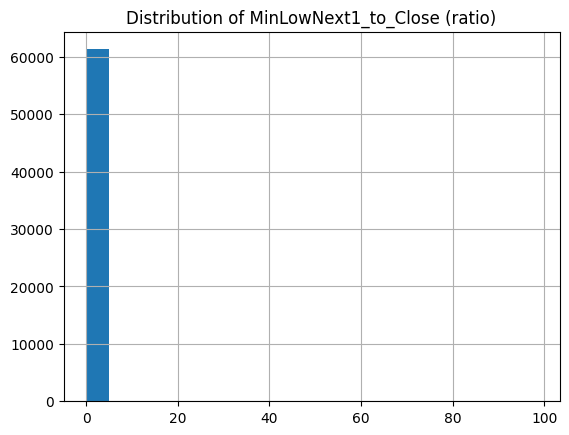

In [174]:
result.Ratio_MinLowNext1_to_Close.hist(bins=20)
plt.title(f'Distribution of MinLowNext1_to_Close (ratio)')
# Show the plot
plt.show()

In [175]:
result.Ratio_MinLowNext1_to_Close.describe().T

count    61312.000000
mean         0.997630
std          0.393464
min          0.009903
25%          0.992115
50%          0.997479
75%          1.001304
max         98.384959
Name: Ratio_MinLowNext1_to_Close, dtype: float64

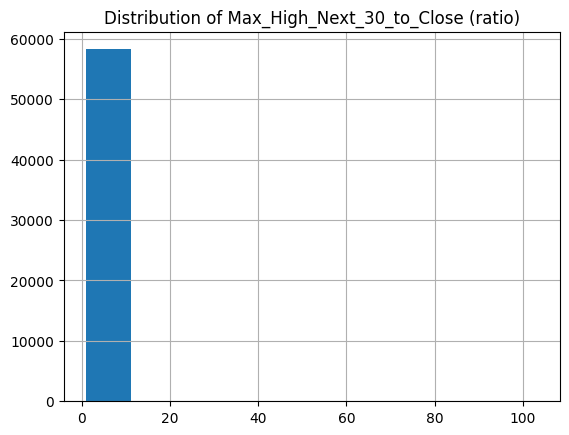

In [176]:
result.Ratio_MaxHighNext30_to_Close.hist()
plt.title(f'Distribution of Max_High_Next_30_to_Close (ratio)')
# Show the plot
plt.show()

In [177]:
result.Ratio_MaxHighNext30_to_Close.describe().T

count    58270.000000
mean         1.093712
std          2.203155
min          0.992183
25%          1.018185
50%          1.035466
75%          1.059966
max        103.257852
Name: Ratio_MaxHighNext30_to_Close, dtype: float64

In [178]:
result[result.Ratio_MaxHighNext30_to_Close>=1.3].sample(5)

,Date,High,Low,Close_x,Ticker,Max_High_Next_30,Min_Low_Next_30,Min_Low_Next_1,Ratio_MaxHighNext30_to_Close,Ratio_MinLowNext30_to_Close,Ratio_MinLowNext1_to_Close
30775,2024-02-20,8.116,8.116000,8.116000,FR001400KE06,10.729000,8.116000,9.995000,1.321957,1.000000,1.231518
26524,2024-12-02,18.466,18.219999,18.219999,FR0013412004,1819.300049,17.535999,18.226000,99.851818,0.962459,1.000329
30771,2024-02-14,8.067,8.067000,8.018000,FR001400KE06,10.658000,8.030000,8.031000,1.329259,1.001497,1.001621
56273,2025-04-07,37.035,33.903000,35.509998,LU1834983477,46.527000,33.903000,35.483002,1.310251,0.954745,0.999240
26528,2024-12-06,18.836,18.382999,18.382999,FR0013412004,1819.300049,17.535999,18.450001,98.966442,0.953925,1.003645


In [180]:
# ~0.17% cases TAKE PROFIT (30%)
len(result[result.Ratio_MaxHighNext30_to_Close>=1.3])/len(result)

0.0016927634363097758

<Axes: >

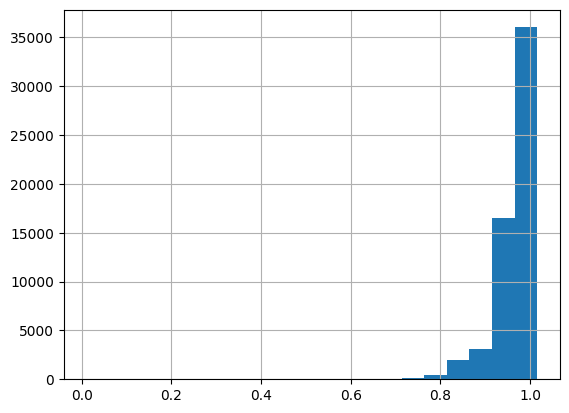

In [182]:
# High intra-day volatility
result.Ratio_MinLowNext30_to_Close.hist(bins=20)

In [183]:
result.Ratio_MinLowNext30_to_Close.describe().T

count    58270.000000
mean         0.962135
std          0.041017
min          0.009903
25%          0.950981
50%          0.974267
75%          0.989294
max          1.015549
Name: Ratio_MinLowNext30_to_Close, dtype: float64

In [184]:
result[result.Ratio_MinLowNext30_to_Close<=0.8].sample(5)

,Date,High,Low,Close_x,Ticker,Max_High_Next_30,Min_Low_Next_30,Min_Low_Next_1,Ratio_MaxHighNext30_to_Close,Ratio_MinLowNext30_to_Close,Ratio_MinLowNext1_to_Close
2586,2025-03-10,5.841600,5.729000,5.800200,DE000A2QP4A8,5.866000,4.582800,5.658600,1.011344,0.790111,0.975587
56596,2025-03-17,88.779999,88.379997,88.739998,LU1834983550,89.430000,66.940002,89.169998,1.007776,0.754339,1.004846
7995,2025-03-21,63.279999,62.230000,62.939999,FR0010468983,64.610001,44.000000,62.570000,1.026533,0.699079,0.994121
6657,2025-04-10,0.913600,0.862400,0.913600,FR0010411884,0.945000,0.705600,0.892900,1.034369,0.772329,0.977342
25750,2024-07-17,39.456001,38.889000,39.047001,FR0013411998,39.456001,28.000000,38.763000,1.010475,0.717085,0.992727


In [186]:
# ~0.7% STOP LOSS
len(result[result.Ratio_MinLowNext30_to_Close<=0.8])/len(result)

0.0069500960317718675

In [187]:
# Merge the results back with the original dataframe
new_df = new_df.merge(result[['Date', 'Ticker', 'Max_High_Next_30', 'Min_Low_Next_30','Ratio_MaxHighNext30_to_Close','Ratio_MinLowNext30_to_Close','Ratio_MinLowNext1_to_Close']], on=['Date', 'Ticker'])

In [188]:
new_df.sample(5)

,Open,High,Low,Close_x,Volume,Dividends,Stock Splits,Capital Gains,Ticker,Year,...,sim1_gross_rev_pred11,sim1_fees_pred11,sim1_net_rev_pred11,pred9_rank,pred10_rank,Max_High_Next_30,Min_Low_Next_30,Ratio_MaxHighNext30_to_Close,Ratio_MinLowNext30_to_Close,Ratio_MinLowNext1_to_Close
29609,33.011002,33.146000,32.799999,33.048000,20376.0,0.0,0.0,0.0,FR0013412285,2023,...,0.000000,0.00,0.000000,10.0,53.0,34.150002,31.864000,1.033345,0.964173,1.001573
22696,13.108700,13.341100,13.108700,13.174600,22132.0,0.0,0.0,0.0,FR0013041530,2023,...,4.483629,-0.16,4.323629,52.0,19.0,13.862700,12.712000,1.052229,0.964887,1.008258
18181,7.550000,7.581000,7.510000,7.511000,13044.0,0.0,0.0,0.0,FR0011871078,2024,...,0.000000,0.00,0.000000,32.0,41.0,7.679000,6.918000,1.022367,0.921049,0.997337
1009,5.000000,5.000000,4.980000,5.011700,2854.0,0.0,0.0,0.0,DE000A2QP380,2024,...,0.000000,0.00,0.000000,74.0,23.0,5.266900,4.963000,1.050921,0.990283,0.993176
3045,77.112371,77.733853,77.054102,77.403687,24095.0,0.0,0.0,0.0,FR0007052782,2024,...,-0.000000,0.00,0.000000,14.0,89.0,80.103249,73.101863,1.034876,0.944424,1.000000


### 3.2.3) Generate fin.result for one date

In [189]:
from dataclasses import dataclass

@dataclass
class SimulationParams:
    initial_capital: float
    threshold: float
    fees: float
    top_k: int
    portfolio_optimization: bool
    stop_loss: float
    take_profit: float
    lower_entry: float

In [190]:
# Example of initializing with some values
sim_params = SimulationParams(
    initial_capital=10000,        # initial capital = $10k
    threshold=0.55,               # select all binary predictions with probability>=0.55
    fees=0.0016,                   # trading fees = 0.016% (buy+sell)
    top_k=10,                     # select top_k predictions
    portfolio_optimization=False, # no portfolio optimizaiton
    stop_loss=0.8,                # automatic sell (with loss) if price (any of next 30 days) is lower than -20% from Close
    take_profit=1.3,              # automatic sell (with profit) if price (any of next 30 days) is higher than +30% from Close
    lower_entry= 0.995                # buy next day with the price = [Close] * 0.995 (try to buy cheaper)
)

print(sim_params)

SimulationParams(initial_capital=10000, threshold=0.55, fees=0.0016, top_k=10, portfolio_optimization=False, stop_loss=0.8, take_profit=1.3, lower_entry=0.995)


In [191]:
# sorted array of dates for Simulation
DATES = new_df[new_df.split=='test'].sort_values(by='Date').Date.unique()
print(f' Min date {DATES.min()}, max date {DATES.max()}')

 Min date 2023-01-02 00:00:00, max date 2025-08-25 00:00:00


In [192]:
date = DATES[0]
date

Timestamp('2023-01-02 00:00:00')

In [193]:
# 1. get TOP_K predictions from pred10_rf_best_rule_50, that are higher than THE THRESHOLD
if sim_params.top_k is None:
  one_day_predictions_df = new_df[(new_df.Date==date)&(new_df.proba_pred10 > sim_params.threshold)]
else:
  one_day_predictions_df = new_df[(new_df.Date==date)&(new_df.proba_pred10 > sim_params.threshold)&(new_df.pred10_rank<=sim_params.top_k)]

In [194]:
one_day_predictions_df[['Date','Ticker',to_predict,'growth_future_30d','proba_pred10','pred10_rank']]

,Date,Ticker,is_positive_growth_30d_future,growth_future_30d,proba_pred10,pred10_rank
12515,2023-01-02,FR0011440478,1,1.058645,0.668120,4.0
14541,2023-01-02,FR0011550672,1,1.075017,0.645873,10.0
21977,2023-01-02,FR0012740983,1,1.102599,0.650150,8.0
27385,2023-01-02,FR0013412020,1,1.048452,0.656562,6.0
29413,2023-01-02,FR0013412285,1,1.047775,0.648554,9.0
30089,2023-01-02,FR0013412293,1,1.069654,0.652032,7.0
36913,2023-01-02,IE00BJM0B415,1,1.093632,0.658742,5.0
50229,2023-01-02,LU1681038672,1,1.069132,0.677406,1.0
50905,2023-01-02,LU1681042864,1,1.054399,0.673171,2.0
52933,2023-01-02,LU1681047079,1,1.107623,0.670881,3.0


In [195]:
# 2. Get non-normalized weights: probability-threshold + 0.01
one_day_predictions_df['weight'] = one_day_predictions_df.proba_pred10 - sim_params.threshold +0.01

In [196]:
one_day_predictions_df[['Date','Ticker','Close_x', to_predict,'growth_future_30d','proba_pred10','pred10_rank','weight']]

,Date,Ticker,Close_x,is_positive_growth_30d_future,growth_future_30d,proba_pred10,pred10_rank,weight
12515,2023-01-02,FR0011440478,14.477000,1,1.058645,0.668120,4.0,0.128120
14541,2023-01-02,FR0011550672,11.514257,1,1.075017,0.645873,10.0,0.105873
21977,2023-01-02,FR0012740983,8.744409,1,1.102599,0.650150,8.0,0.110150
27385,2023-01-02,FR0013412020,20.247000,1,1.048452,0.656562,6.0,0.116562
29413,2023-01-02,FR0013412285,29.660000,1,1.047775,0.648554,9.0,0.108554
30089,2023-01-02,FR0013412293,25.726999,1,1.069654,0.652032,7.0,0.112032
36913,2023-01-02,IE00BJM0B415,5.202822,1,1.093632,0.658742,5.0,0.118742
50229,2023-01-02,LU1681038672,244.450699,1,1.069132,0.677406,1.0,0.137406
50905,2023-01-02,LU1681042864,464.669800,1,1.054399,0.673171,2.0,0.133171
52933,2023-01-02,LU1681047079,60.563091,1,1.107623,0.670881,3.0,0.130881


In [197]:
# 3. Get normalized weights
one_day_predictions_df['weight_norm'] = one_day_predictions_df['weight']/one_day_predictions_df['weight'].sum()

In [198]:
one_day_predictions_df[['Date','Ticker','Close_x', to_predict,'growth_future_30d','proba_pred10','pred10_rank','weight','weight_norm']]

,Date,Ticker,Close_x,is_positive_growth_30d_future,growth_future_30d,proba_pred10,pred10_rank,weight,weight_norm
12515,2023-01-02,FR0011440478,14.477000,1,1.058645,0.668120,4.0,0.128120,0.106634
14541,2023-01-02,FR0011550672,11.514257,1,1.075017,0.645873,10.0,0.105873,0.088118
21977,2023-01-02,FR0012740983,8.744409,1,1.102599,0.650150,8.0,0.110150,0.091678
27385,2023-01-02,FR0013412020,20.247000,1,1.048452,0.656562,6.0,0.116562,0.097015
29413,2023-01-02,FR0013412285,29.660000,1,1.047775,0.648554,9.0,0.108554,0.090350
30089,2023-01-02,FR0013412293,25.726999,1,1.069654,0.652032,7.0,0.112032,0.093244
36913,2023-01-02,IE00BJM0B415,5.202822,1,1.093632,0.658742,5.0,0.118742,0.098829
50229,2023-01-02,LU1681038672,244.450699,1,1.069132,0.677406,1.0,0.137406,0.114363
50905,2023-01-02,LU1681042864,464.669800,1,1.054399,0.673171,2.0,0.133171,0.110838
52933,2023-01-02,LU1681047079,60.563091,1,1.107623,0.670881,3.0,0.130881,0.108932


In [199]:
# 4. Capital: either 1/30 of initial (assuming you trade every day), or everything that you can sell from 30 days ago
one_day_predictions_df['investment'] = one_day_predictions_df['weight_norm'] * sim_params.initial_capital /30

In [200]:
# See the allocation of an 'investment' at a price = 'Adj.Close' * sim_params.lower_entry (e.g. 0.995 - try to buy cheaper)
one_day_predictions_df[['Date','Ticker','Close_x', to_predict,'growth_future_30d','proba_pred10','pred10_rank','weight','weight_norm', 'investment']]

,Date,Ticker,Close_x,is_positive_growth_30d_future,growth_future_30d,proba_pred10,pred10_rank,weight,weight_norm,investment
12515,2023-01-02,FR0011440478,14.477000,1,1.058645,0.668120,4.0,0.128120,0.106634,35.544622
14541,2023-01-02,FR0011550672,11.514257,1,1.075017,0.645873,10.0,0.105873,0.088118,29.372740
21977,2023-01-02,FR0012740983,8.744409,1,1.102599,0.650150,8.0,0.110150,0.091678,30.559182
27385,2023-01-02,FR0013412020,20.247000,1,1.048452,0.656562,6.0,0.116562,0.097015,32.338211
29413,2023-01-02,FR0013412285,29.660000,1,1.047775,0.648554,9.0,0.108554,0.090350,30.116575
30089,2023-01-02,FR0013412293,25.726999,1,1.069654,0.652032,7.0,0.112032,0.093244,31.081257
36913,2023-01-02,IE00BJM0B415,5.202822,1,1.093632,0.658742,5.0,0.118742,0.098829,32.943018
50229,2023-01-02,LU1681038672,244.450699,1,1.069132,0.677406,1.0,0.137406,0.114363,38.121073
50905,2023-01-02,LU1681042864,464.669800,1,1.054399,0.673171,2.0,0.133171,0.110838,36.945936
52933,2023-01-02,LU1681047079,60.563091,1,1.107623,0.670881,3.0,0.130881,0.108932,36.310720


In [201]:
# 5. Lower Entry: the trade is executed only is Low price for next day is lower than bet
one_day_predictions_df['lower_entry'] = (one_day_predictions_df['Ratio_MinLowNext1_to_Close']<=sim_params.lower_entry).astype(int)

In [202]:
one_day_predictions_df.tail(10)

,Open,High,Low,Close_x,Volume,Dividends,Stock Splits,Capital Gains,Ticker,Year,...,pred10_rank,Max_High_Next_30,Min_Low_Next_30,Ratio_MaxHighNext30_to_Close,Ratio_MinLowNext30_to_Close,Ratio_MinLowNext1_to_Close,weight,weight_norm,investment,lower_entry
12515,14.519000,14.569000,14.439000,14.477000,1109.0,0.0,0.0,0.0,FR0011440478,2023,...,4.0,15.827000,14.439000,1.093251,0.997375,1.012433,0.128120,0.106634,35.544622,0
14541,11.463448,11.531845,11.463448,11.514257,1798.0,0.0,0.0,0.0,FR0011550672,2023,...,10.0,12.430785,11.463448,1.079599,0.995587,1.002206,0.105873,0.088118,29.372740,0
21977,8.744409,8.744409,8.744409,8.744409,1.0,0.0,0.0,0.0,FR0012740983,2023,...,8.0,9.721892,8.744409,1.111784,1.000000,1.007410,0.110150,0.091678,30.559182,0
27385,20.570000,20.570000,20.159000,20.247000,3585.0,0.0,0.0,0.0,FR0013412020,2023,...,6.0,21.999001,20.159000,1.086531,0.995654,1.006075,0.116562,0.097015,32.338211,0
29413,29.266001,29.851000,29.150000,29.660000,7929.0,0.0,0.0,0.0,FR0013412285,2023,...,9.0,31.299999,29.033001,1.055293,0.978860,0.981794,0.108554,0.090350,30.116575,1
30089,26.365000,26.455000,25.690001,25.726999,1753.0,0.0,0.0,0.0,FR0013412293,2023,...,7.0,27.931000,25.396000,1.085669,0.987134,0.991177,0.112032,0.093244,31.081257,1
36913,5.200006,5.225349,5.200006,5.202822,58.0,0.0,0.0,0.0,IE00BJM0B415,2023,...,5.0,5.777263,5.200006,1.110410,0.999459,1.007938,0.118742,0.098829,32.943018,0
50229,242.559906,244.910599,241.199997,244.450699,319.0,0.0,0.0,0.0,LU1681038672,2023,...,1.0,268.500000,239.353104,1.098381,0.979147,0.985413,0.137406,0.114363,38.121073,1
50905,461.360107,464.789795,460.200195,464.669800,62.0,0.0,0.0,0.0,LU1681042864,2023,...,2.0,493.449799,455.147797,1.061936,0.979508,0.986100,0.133171,0.110838,36.945936,1
52933,60.213075,60.619856,60.194154,60.563091,363.0,0.0,0.0,0.0,LU1681047079,2023,...,3.0,67.412157,60.194154,1.113090,0.993908,1.002187,0.130881,0.108932,36.310720,0


In [218]:
# 6. Stop Loss: happens if the current price (or Low price) goes below stop loss threshold during one of the next 5 periods (1 week)
one_day_predictions_df['stop_loss'] = (one_day_predictions_df['Ratio_MinLowNext30_to_Close'] <= sim_params.stop_loss).astype(int)

In [219]:
# 7. Take Profit: take the money if the current Price (or Max_price) goes higher than sim_params.take_profit
one_day_predictions_df['take_profit'] = (one_day_predictions_df['Ratio_MaxHighNext30_to_Close'] >= sim_params.take_profit).astype(int)

In [220]:
one_day_predictions_df.tail(10)

,Open,High,Low,Close_x,Volume,Dividends,Stock Splits,Capital Gains,Ticker,Year,...,Ratio_MinLowNext1_to_Close,weight,weight_norm,investment,lower_entry,stop_loss,take_profit,future_gross_return,fees,future_net_return
12515,14.519000,14.569000,14.439000,14.477000,1109.0,0.0,0.0,0.0,FR0011440478,2023,...,1.012433,0.128120,0.106634,35.544622,0,0,0,35.544622,0.000000,35.544622
14541,11.463448,11.531845,11.463448,11.514257,1798.0,0.0,0.0,0.0,FR0011550672,2023,...,1.002206,0.105873,0.088118,29.372740,0,0,0,29.372740,0.000000,29.372740
21977,8.744409,8.744409,8.744409,8.744409,1.0,0.0,0.0,0.0,FR0012740983,2023,...,1.007410,0.110150,0.091678,30.559182,0,0,0,30.559182,0.000000,30.559182
27385,20.570000,20.570000,20.159000,20.247000,3585.0,0.0,0.0,0.0,FR0013412020,2023,...,1.006075,0.116562,0.097015,32.338211,0,0,0,32.338211,0.000000,32.338211
29413,29.266001,29.851000,29.150000,29.660000,7929.0,0.0,0.0,0.0,FR0013412285,2023,...,0.981794,0.108554,0.090350,30.116575,1,0,0,31.705970,-0.048187,31.657784
30089,26.365000,26.455000,25.690001,25.726999,1753.0,0.0,0.0,0.0,FR0013412293,2023,...,0.991177,0.112032,0.093244,31.081257,1,0,0,33.401611,-0.049730,33.351881
36913,5.200006,5.225349,5.200006,5.202822,58.0,0.0,0.0,0.0,IE00BJM0B415,2023,...,1.007938,0.118742,0.098829,32.943018,0,0,0,32.943018,0.000000,32.943018
50229,242.559906,244.910599,241.199997,244.450699,319.0,0.0,0.0,0.0,LU1681038672,2023,...,0.985413,0.137406,0.114363,38.121073,1,0,0,40.947055,-0.060994,40.886061
50905,461.360107,464.789795,460.200195,464.669800,62.0,0.0,0.0,0.0,LU1681042864,2023,...,0.986100,0.133171,0.110838,36.945936,1,0,0,39.140489,-0.059113,39.081376
52933,60.213075,60.619856,60.194154,60.563091,363.0,0.0,0.0,0.0,LU1681047079,2023,...,1.002187,0.130881,0.108932,36.310720,0,0,0,36.310720,0.000000,36.310720


In [221]:
# future_gross_return, depending on lower_entry, take_profit, stop_loss

import random

def get_future_gross_return(row, sim_params:SimulationParams):
  if row['lower_entry']==0: # no trade, investment is untouched, no fees
    return row['investment']

  # buy trade is filled for ALL next cases:
  if row['take_profit']==1 and row['stop_loss']==1:
    if random.random()>0.5: #assume take_profit event was first
      return  row['investment']*(sim_params.take_profit+(1-sim_params.lower_entry))
    else: #assume stop_loss event was first
      return row['investment']*(sim_params.stop_loss+(1-sim_params.lower_entry))

  if row['take_profit']==1: # take some good profit, pay fees
    return  row['investment']*(sim_params.take_profit+(1-sim_params.lower_entry))

  if row['stop_loss']==1: # fix the loss, pay fees
      return row['investment']*(sim_params.stop_loss+(1-sim_params.lower_entry))

  # no stop_loss and no take_profit
  if pd.isna(row['growth_future_30d']):
    return row['investment'] # no information on growth in 30 days --> return the same investment in 5 days
  else:
    return row['investment']*(row['growth_future_30d']+(1-sim_params.lower_entry))

In [222]:
# fees, depending on lower_entry, take_profit, stop_loss

def get_fees(row, sim_params:SimulationParams):
  if row['lower_entry']==0: # no trade ==> no fees
    return 0

  # pay fees in all other cases
  return -row['investment']*sim_params.fees


In [223]:
# 8. calculate future returns (when the order is executed + stop_loss True/False + take_profit True/False)
one_day_predictions_df['future_gross_return'] = one_day_predictions_df.apply(lambda row: get_future_gross_return(row,sim_params=sim_params), axis=1)
one_day_predictions_df['fees'] =  one_day_predictions_df.apply(lambda row: get_fees(row,sim_params=sim_params), axis=1)
one_day_predictions_df['future_net_return'] = one_day_predictions_df['future_gross_return'] + one_day_predictions_df['fees']

# OLD code when no stop_loss, take_profit, and if order executed
# one_day_predictions_df['investment'] * one_day_predictions_df['growth_future_5d']
# one_day_predictions_df['fees'] =   - one_day_predictions_df['investment'] * sim_params.fees


In [224]:
# result
one_day_predictions_df

,Open,High,Low,Close_x,Volume,Dividends,Stock Splits,Capital Gains,Ticker,Year,...,Ratio_MinLowNext1_to_Close,weight,weight_norm,investment,lower_entry,stop_loss,take_profit,future_gross_return,fees,future_net_return
12515,14.519000,14.569000,14.439000,14.477000,1109.0,0.0,0.0,0.0,FR0011440478,2023,...,1.012433,0.128120,0.106634,35.544622,0,0,0,35.544622,0.000000,35.544622
14541,11.463448,11.531845,11.463448,11.514257,1798.0,0.0,0.0,0.0,FR0011550672,2023,...,1.002206,0.105873,0.088118,29.372740,0,0,0,29.372740,0.000000,29.372740
21977,8.744409,8.744409,8.744409,8.744409,1.0,0.0,0.0,0.0,FR0012740983,2023,...,1.007410,0.110150,0.091678,30.559182,0,0,0,30.559182,0.000000,30.559182
27385,20.570000,20.570000,20.159000,20.247000,3585.0,0.0,0.0,0.0,FR0013412020,2023,...,1.006075,0.116562,0.097015,32.338211,0,0,0,32.338211,0.000000,32.338211
29413,29.266001,29.851000,29.150000,29.660000,7929.0,0.0,0.0,0.0,FR0013412285,2023,...,0.981794,0.108554,0.090350,30.116575,1,0,0,31.705970,-0.060233,31.645737
30089,26.365000,26.455000,25.690001,25.726999,1753.0,0.0,0.0,0.0,FR0013412293,2023,...,0.991177,0.112032,0.093244,31.081257,1,0,0,33.401611,-0.062163,33.339449
36913,5.200006,5.225349,5.200006,5.202822,58.0,0.0,0.0,0.0,IE00BJM0B415,2023,...,1.007938,0.118742,0.098829,32.943018,0,0,0,32.943018,0.000000,32.943018
50229,242.559906,244.910599,241.199997,244.450699,319.0,0.0,0.0,0.0,LU1681038672,2023,...,0.985413,0.137406,0.114363,38.121073,1,0,0,40.947055,-0.076242,40.870813
50905,461.360107,464.789795,460.200195,464.669800,62.0,0.0,0.0,0.0,LU1681042864,2023,...,0.986100,0.133171,0.110838,36.945936,1,0,0,39.140489,-0.073892,39.066597
52933,60.213075,60.619856,60.194154,60.563091,363.0,0.0,0.0,0.0,LU1681047079,2023,...,1.002187,0.130881,0.108932,36.310720,0,0,0,36.310720,0.000000,36.310720


### 3.2.4 Wrap up one day simulation into a function

In [250]:
# Simulation Parameters
sim_params = SimulationParams(
    initial_capital=10000,                 # initial capital = $10k
    threshold=0.55,                        # select all binary predictions with probability>=0.55
    fees=0.0016,                            # trading fees = 0.16% (buy+sell)
    top_k=10,                              # select top_k predictions
    portfolio_optimization=False,          # no portfolio optimizaiton
    stop_loss=0.8,                         # automatic sell (with loss) if price (any of next 30 trading days) is lower than -20% from Close
    take_profit=1.3,                       # automatic sell (with profit) if price (any of next 30 trading days) is higher than +30% from Close
    lower_entry= 0.995                     # buy next day with the price = [Close] * 0.995 (try to buy cheaper)
)

In [238]:
def one_date_simulation(date:str, invest_sum:float, df:pd.DataFrame, sim_params:SimulationParams, predictor:str='proba_pred10'):

  rank_column = predictor.split('_')[1]+'_rank' # e.g. 'proba_pred10' --> 'pred10_rank'
  # 1. get TOP_K (or ALL) predictions from the predictor (pred14_rf_best_rule_53 by default), that are higher than THE THRESHOLD
  if sim_params.top_k is None:
    one_day_predictions_df = df[(df.Date==date)&(df[predictor] > sim_params.threshold)]
  else:
    one_day_predictions_df = df[(df.Date==date)&(df[predictor] > sim_params.threshold)&(df[rank_column]<=sim_params.top_k)]

  FIELDS = ['Close_x', 'Ticker', 'Date', predictor, rank_column, 'growth_future_30d', 'Ratio_MaxHighNext30_to_Close','Ratio_MinLowNext30_to_Close','Ratio_MinLowNext1_to_Close']
  result_df = one_day_predictions_df[FIELDS].copy()

  # 2. Get non-normalized weights: probability-threshold + 0.01
  result_df['weight'] = result_df[predictor] - sim_params.threshold +0.01

  # 3. Get normalized weights
  result_df['weight_norm'] = result_df['weight']/result_df['weight'].sum()

  # 4. Make bets to allocate 'invest_sum' across all suitable predictions
  result_df['investment'] = result_df['weight_norm'] * invest_sum

  # 5. Lower Entry: the trade is executed only is Low price for next day is lower than the bet (Adj_Close_today * sim_params.lower_entry)
    # [ONLY TRADES with lower_entry==1 are filled by the exchange]
  result_df['lower_entry'] = (result_df['Ratio_MinLowNext1_to_Close'] <= sim_params.lower_entry).astype(int)

  # 6. Stop Loss: happens if the current price (or Low price) goes below stop loss threshold during one of the next 5 periods (1 week)
  result_df['stop_loss'] = (result_df['Ratio_MinLowNext30_to_Close'] <= sim_params.stop_loss).astype(int)

  # 7. Take Profit: take the money if the current Price (or Max_price) goes higher than sim_params.take_profit
  result_df['take_profit'] = (result_df['Ratio_MaxHighNext30_to_Close'] >= sim_params.take_profit).astype(int)

  # 8. Calculate future returns (when the order is executed + stop_loss True/False + take_profit True/False)
  result_df['future_gross_return'] = result_df.apply(lambda row: get_future_gross_return(row,sim_params=sim_params), axis=1)
  result_df['fees'] =  result_df.apply(lambda row: get_fees(row,sim_params=sim_params), axis=1)
  result_df['future_net_return'] = result_df['future_gross_return'] + result_df['fees']

  return result_df

In [239]:
predictor = 'proba_pred10'
rank = predictor.split('_')[1]+'_rank'
print(rank)

pred10_rank


In [240]:
r = one_date_simulation(date='2023-01-02', invest_sum=sim_params.initial_capital/30, df=new_df, sim_params=sim_params, predictor='proba_pred10')

In [241]:
r

,Close_x,Ticker,Date,proba_pred10,pred10_rank,growth_future_30d,Ratio_MaxHighNext30_to_Close,Ratio_MinLowNext30_to_Close,Ratio_MinLowNext1_to_Close,weight,weight_norm,investment,lower_entry,stop_loss,take_profit,future_gross_return,fees,future_net_return
12515,14.477000,FR0011440478,2023-01-02,0.668120,4.0,1.058645,1.093251,0.997375,1.012433,0.128120,0.106634,35.544622,0,0,0,35.544622,0.000000,35.544622
14541,11.514257,FR0011550672,2023-01-02,0.645873,10.0,1.075017,1.079599,0.995587,1.002206,0.105873,0.088118,29.372740,0,0,0,29.372740,0.000000,29.372740
21977,8.744409,FR0012740983,2023-01-02,0.650150,8.0,1.102599,1.111784,1.000000,1.007410,0.110150,0.091678,30.559182,0,0,0,30.559182,0.000000,30.559182
27385,20.247000,FR0013412020,2023-01-02,0.656562,6.0,1.048452,1.086531,0.995654,1.006075,0.116562,0.097015,32.338211,0,0,0,32.338211,0.000000,32.338211
29413,29.660000,FR0013412285,2023-01-02,0.648554,9.0,1.047775,1.055293,0.978860,0.981794,0.108554,0.090350,30.116575,1,0,0,31.705970,-0.048187,31.657784
30089,25.726999,FR0013412293,2023-01-02,0.652032,7.0,1.069654,1.085669,0.987134,0.991177,0.112032,0.093244,31.081257,1,0,0,33.401611,-0.049730,33.351881
36913,5.202822,IE00BJM0B415,2023-01-02,0.658742,5.0,1.093632,1.110410,0.999459,1.007938,0.118742,0.098829,32.943018,0,0,0,32.943018,0.000000,32.943018
50229,244.450699,LU1681038672,2023-01-02,0.677406,1.0,1.069132,1.098381,0.979147,0.985413,0.137406,0.114363,38.121073,1,0,0,40.947055,-0.060994,40.886061
50905,464.669800,LU1681042864,2023-01-02,0.673171,2.0,1.054399,1.061936,0.979508,0.986100,0.133171,0.110838,36.945936,1,0,0,39.140489,-0.059113,39.081376
52933,60.563091,LU1681047079,2023-01-02,0.670881,3.0,1.107623,1.113090,0.993908,1.002187,0.130881,0.108932,36.310720,0,0,0,36.310720,0.000000,36.310720


In [242]:
# initial investment
r.investment.sum()

np.float64(333.3333333333333)

In [243]:
# result in 30 days (returns+fees)
r.future_net_return.sum()

np.float64(342.0455941659018)

### 3.2.5 Generate fin result for ALL days

In [244]:
all_dates = new_df[new_df.split=='test'].sort_values(by='Date').Date.unique()
all_dates

<DatetimeArray>
['2023-01-02 00:00:00', '2023-01-03 00:00:00', '2023-01-04 00:00:00',
 '2023-01-05 00:00:00', '2023-01-06 00:00:00', '2023-01-09 00:00:00',
 '2023-01-10 00:00:00', '2023-01-11 00:00:00', '2023-01-12 00:00:00',
 '2023-01-13 00:00:00',
 ...
 '2025-08-12 00:00:00', '2025-08-13 00:00:00', '2025-08-14 00:00:00',
 '2025-08-15 00:00:00', '2025-08-18 00:00:00', '2025-08-19 00:00:00',
 '2025-08-20 00:00:00', '2025-08-21 00:00:00', '2025-08-22 00:00:00',
 '2025-08-25 00:00:00']
Length: 678, dtype: datetime64[ns]

In [245]:
# simulate for all dates but last 5
all_dates[0:-5]

<DatetimeArray>
['2023-01-02 00:00:00', '2023-01-03 00:00:00', '2023-01-04 00:00:00',
 '2023-01-05 00:00:00', '2023-01-06 00:00:00', '2023-01-09 00:00:00',
 '2023-01-10 00:00:00', '2023-01-11 00:00:00', '2023-01-12 00:00:00',
 '2023-01-13 00:00:00',
 ...
 '2025-08-05 00:00:00', '2025-08-06 00:00:00', '2025-08-07 00:00:00',
 '2025-08-08 00:00:00', '2025-08-11 00:00:00', '2025-08-12 00:00:00',
 '2025-08-13 00:00:00', '2025-08-14 00:00:00', '2025-08-15 00:00:00',
 '2025-08-18 00:00:00']
Length: 673, dtype: datetime64[ns]

In [246]:
# these last days we only "sell" the positions
all_dates[-5:]

<DatetimeArray>
['2025-08-19 00:00:00', '2025-08-20 00:00:00', '2025-08-21 00:00:00',
 '2025-08-22 00:00:00', '2025-08-25 00:00:00']
Length: 5, dtype: datetime64[ns]

In [247]:
capital= 5 * [sim_params.initial_capital/5]
capital[-5]

2000.0

In [248]:
def simulate(df:pd.DataFrame, sim_params:SimulationParams):

  simulation_df = None

  # all dates for simulation
  all_dates = df[df.split=='test'].sort_values(by='Date').Date.unique()

  # arrays of dates and capital available (capital for the first 5 days)
  dates = []
  capital= 30 * [sim_params.initial_capital/30]  # first 30 periods trade with 1/30 of the initial_capital. e.g. [333,...,333] = 10k in total

  for current_date in all_dates[0:-30]:  #growth_future_30d is not defined for the last 30 days : ALL, but last 30 dates

    current_invest_sum = capital[-30]    # take the value or everything that you can sell from 30 days ago

    one_day_simulation_results = one_date_simulation(date = current_date,  # one day simulation result
                                    invest_sum = current_invest_sum,
                                    df = df,
                                    sim_params=sim_params,
                                    predictor='proba_pred10')

    # add capital available in 30 days
    if len(one_day_simulation_results)==0:  #no predictions -> no trades
      capital.append(current_invest_sum)
    else:
      capital.append(one_day_simulation_results.future_net_return.sum())
    dates.append(current_date)

    if simulation_df is None:
      simulation_df = one_day_simulation_results
    else:
      simulation_df = pd.concat([simulation_df, one_day_simulation_results], ignore_index=True)

  # add last 5 days to make the count of data points equal for dates/capital arrays
  dates.extend(all_dates[-30:])
  capital_df = pd.DataFrame({'capital':capital}, index=pd.to_datetime(dates))

  # results:
  print(f'============================================================================================')
  print(f'SIMULATION STARTED')
  print(f'Simulations params: {sim_params}')
  print(f' Count bids {len(simulation_df)} in total, avg.bids per day {len(simulation_df)/simulation_df.Date.nunique()},  filled bids {len(simulation_df[simulation_df.lower_entry==1])}, fill bids percent = {len(simulation_df[simulation_df.lower_entry==1])/len(simulation_df)}')
  stop_loss_filter = (simulation_df.lower_entry==1)&(simulation_df.stop_loss==1)
  print(f'  Stop loss events: count = {len(simulation_df[stop_loss_filter])}, net loss = {simulation_df[stop_loss_filter].future_net_return.sum()-simulation_df[stop_loss_filter].investment.sum()} ')
  take_profit_filter = (simulation_df.lower_entry==1)&(simulation_df.take_profit==1)
  print(f'  Take profit events: count = {len(simulation_df[take_profit_filter])}, net profit = {simulation_df[take_profit_filter].future_net_return.sum()-simulation_df[take_profit_filter].investment.sum()} ')
  print(f'  Start capital = {sim_params.initial_capital}, Resulting capital: {capital_df[-30:].capital.sum()} ')
  print(f'  CAGR in 4 years: {np.round((capital_df[-30:].capital.sum()/sim_params.initial_capital)**(1/4),3)} or {np.round(((capital_df[-30:].capital.sum()/sim_params.initial_capital)**(1/4)-1)*100.0,2)} % of avg. growth per year')
  print(f'============================================================================================')
  return simulation_df,capital_df

In [251]:
# One initial simulation
sim_params = SimulationParams(
    initial_capital = 10000,        # initial capital = $10k
    threshold = 0.55,               # select all binary predictions with probability>=0.55
    fees = 0.0016,                   # trading fees = 0.16% (buy+sell)
    top_k = 5,                      # select top_k=5 predictions
    portfolio_optimization = False, # no portfolio optimization
    stop_loss = 0.8,                # automatic sell (with loss) if price (any of next 5 days) is lower than -20% from Adj.Close
    take_profit = 1.3,              # automatic sell (with profit) if price (any of next 5 days) is higher than +30% from Adj.Close
    lower_entry = 0.99               # buy next day with the price = [Close] * 0.99 (try to buy cheaper)
)

res, capital = simulate(new_df, sim_params)

SIMULATION STARTED
Simulations params: SimulationParams(initial_capital=10000, threshold=0.55, fees=0.0016, top_k=5, portfolio_optimization=False, stop_loss=0.8, take_profit=1.3, lower_entry=0.99)
 Count bids 2538 in total, avg.bids per day 4.251256281407035,  filled bids 503, fill bids percent = 0.19818754925137905
  Stop loss events: count = 9, net loss = -99.94409238520848 
  Take profit events: count = 3, net profit = 74.56504287487775 
  Start capital = 10000, Resulting capital: 10419.281069708259 
  CAGR in 4 years: 1.01 or 1.03 % of avg. growth per year


### 3.2.5 Find optimal parameters of simulation

In [252]:
# BEST PREVIOUS CAGR is 7.8%  (top_k=5, portfolio_optimization=False, stop_loss=0.8, take_profit=1.3, lower_entry=0.99)
# iterate over lower_entry
for lower_entry in [0.97,0.98,0.99,1,1.01,1.02,1.03]:
  # One simulation
  sim_params = SimulationParams(
      initial_capital = 10000,        # initial capital = $10k
      threshold = 0.55,               # select all binary predictions with probability>=0.55
      fees = 0.0016,                   # trading fees = 0.16% (buy+sell)
      top_k = 5,                     # select top_k predictions
      portfolio_optimization = False, # no portfolio optimization
      stop_loss = 0.8,                # automatic sell (with loss) if price (any of next 5 days) is lower than -5% from Adj.Close
      take_profit = 1.3,              # automatic sell (with profit) if price (any of next 5 days) is higher than +20% from Adj.Close
      lower_entry = lower_entry                # buy next day with the price = [Adj.Close] * 0.995 (try to buy cheaper)
  )

  res, capital = simulate(new_df, sim_params)

SIMULATION STARTED
Simulations params: SimulationParams(initial_capital=10000, threshold=0.55, fees=0.0016, top_k=5, portfolio_optimization=False, stop_loss=0.8, take_profit=1.3, lower_entry=0.97)
 Count bids 2538 in total, avg.bids per day 4.251256281407035,  filled bids 54, fill bids percent = 0.02127659574468085
  Stop loss events: count = 3, net loss = -30.64193064020219 
  Take profit events: count = 0, net profit = 0.0 
  Start capital = 10000, Resulting capital: 10254.33847120131 
  CAGR in 4 years: 1.006 or 0.63 % of avg. growth per year
SIMULATION STARTED
Simulations params: SimulationParams(initial_capital=10000, threshold=0.55, fees=0.0016, top_k=5, portfolio_optimization=False, stop_loss=0.8, take_profit=1.3, lower_entry=0.98)
 Count bids 2538 in total, avg.bids per day 4.251256281407035,  filled bids 158, fill bids percent = 0.062253743104806934
  Stop loss events: count = 6, net loss = -69.91297802367052 
  Take profit events: count = 0, net profit = 0.0 
  Start capital 

In [254]:
# BEST PREVIOUS is CAGR 11.16%  (top_k=5, portfolio_optimization=False, stop_loss=0.8, take_profit=1.3, lower_entry=0.99 ==> lower_entry=1.0)

# iterate over take profit   ==> new best take_profit=1.5
for take_profit in [1.2,1.25,1.3,1.35,1.4,1.45,1.5]:
  # One simulation
  sim_params = SimulationParams(
      initial_capital = 10000,        # initial capital = $10k
      threshold = 0.55,               # select all binary predictions with probability>=0.55
      fees = 0.0016,                   # trading fees = 0.16% (buy+sell)
      top_k = 5,                     # select top_k predictions
      portfolio_optimization = False, # no portfolio optimization
      stop_loss = 0.8,                # automatic sell (with loss) if price (any of next 30 days) is lower than -5% from Adj.Close
      take_profit = take_profit,        # automatic sell (with profit) if price (any of next 30 days) is higher than +20% from Adj.Close
      lower_entry = 1                # buy next day with the price = [Close] * lower_entry (try to buy cheaper)
  )

  res, capital = simulate(new_df, sim_params)

SIMULATION STARTED
Simulations params: SimulationParams(initial_capital=10000, threshold=0.55, fees=0.0016, top_k=5, portfolio_optimization=False, stop_loss=0.8, take_profit=1.2, lower_entry=1)
 Count bids 2538 in total, avg.bids per day 4.251256281407035,  filled bids 1691, fill bids percent = 0.6662726556343578
  Stop loss events: count = 15, net loss = -226.41953400905163 
  Take profit events: count = 7, net profit = 100.69538029397631 
  Start capital = 10000, Resulting capital: 10420.718754826255 
  CAGR in 4 years: 1.01 or 1.04 % of avg. growth per year
SIMULATION STARTED
Simulations params: SimulationParams(initial_capital=10000, threshold=0.55, fees=0.0016, top_k=5, portfolio_optimization=False, stop_loss=0.8, take_profit=1.25, lower_entry=1)
 Count bids 2538 in total, avg.bids per day 4.251256281407035,  filled bids 1691, fill bids percent = 0.6662726556343578
  Stop loss events: count = 15, net loss = -226.5286710486813 
  Take profit events: count = 6, net profit = 114.8238

In [ ]:
# BEST PREVIOUS is CAGR 11.16%  (top_k=5, portfolio_optimization=False, stop_loss=0.8, take_profit=1.3, lower_entry=1.0)
# BEST PREVIOUS is CAGR 11.91%  (top_k=5, portfolio_optimization=False, stop_loss=0.8, take_profit=1.3 => take_profit=1.5, lower_entry=1.0)

# iterate over stop_loss
for stop_loss in [0.55,0.6,0.65,0.7,0.75,0.8]:
  # One simulation
  sim_params = SimulationParams(
      initial_capital = 10000,        # initial capital = $10k
      threshold = 0.55,               # select all binary predictions with probability>=0.55
      fees = 0.002,                   # trading fees = 0.2% (buy+sell)
      top_k = 5,                     # select top_k predictions
      portfolio_optimization = False, # no portfolio optimization
      stop_loss = stop_loss,                # automatic sell (with loss) if price (any of next 30 days) is lower than -"stop_loss"% from Close
      take_profit = 1.5,              # automatic sell (with profit) if price (any of next 30 days) is higher than +50% from Close
      lower_entry = 1                # buy next day with the price = [Close] * 1 (try to buy cheaper)
  )

  res, capital = simulate(new_df, sim_params)

SIMULATION STARTED
Simulations params: SimulationParams(initial_capital=10000, threshold=0.55, fees=0.002, top_k=5, portfolio_optimization=False, stop_loss=0.55, take_profit=1.5, lower_entry=1)
 Count bids 4619 in total, avg.bids per day 4.836649214659686,  filled bids 3618, fill bids percent = 0.7832864256332539
  Stop loss events: count = 0, net loss = 0.0 
  Take profit events: count = 22, net profit = 832.5242904627439 
  Start capital = 10000, Resulting capital: 16417.214801149898 
  CAGR in 4 years: 1.132 or 13.19 % of avg. growth per year
SIMULATION STARTED
Simulations params: SimulationParams(initial_capital=10000, threshold=0.55, fees=0.002, top_k=5, portfolio_optimization=False, stop_loss=0.6, take_profit=1.5, lower_entry=1)
 Count bids 4619 in total, avg.bids per day 4.836649214659686,  filled bids 3618, fill bids percent = 0.7832864256332539
  Stop loss events: count = 0, net loss = 0.0 
  Take profit events: count = 22, net profit = 832.5242904627439 
  Start capital = 100

In [255]:
# BEST PREVIOUS is CAGR 11.16%  (top_k=5, portfolio_optimization=False, stop_loss=0.8, take_profit=1.3, lower_entry=1.0)
# BEST PREVIOUS is CAGR 11.91%  (top_k=5, portfolio_optimization=False, stop_loss=0.8, take_profit=1.3 => take_profit=1.5, lower_entry=1.0)
# BEST PREVIOUS is CAGR 13.19%  (top_k=5, portfolio_optimization=False, stop_loss=0.8 => stop_loss=0.6, take_profit=1.5, lower_entry=1.0)


# iterate over lower_entry ++ take profit of 2.5%
  # best lower_entry ==0.98
for threshold in [0.51,0.52,0.53,0.54,0.55,0.56,0.57]:
  # One simulation
  sim_params = SimulationParams(
      initial_capital = 10000,        # initial capital = $10k
      threshold = threshold,               # select all binary predictions with probability>=threshold (iter param)
      fees = 0.0016,                   # trading fees = 0.16% (buy+sell)
      top_k = 5,                     # select top_k predictions
      portfolio_optimization = False, # no portfolio optimization
      stop_loss = 0.6,                # automatic sell (with loss) if price (any of next 30 days) is lower than -40% from Close
      take_profit = 1.5,              # automatic sell (with profit) if price (any of next 30 days) is higher than +50% from Adj.Close
      lower_entry = 1                # buy next day with the price = [Close] * lower_entry (try to buy cheaper)
  )

  res, capital = simulate(new_df, sim_params)

SIMULATION STARTED
Simulations params: SimulationParams(initial_capital=10000, threshold=0.51, fees=0.0016, top_k=5, portfolio_optimization=False, stop_loss=0.6, take_profit=1.5, lower_entry=1)
 Count bids 3013 in total, avg.bids per day 4.715179968701095,  filled bids 2006, fill bids percent = 0.6657816130102887
  Stop loss events: count = 0, net loss = 0.0 
  Take profit events: count = 5, net profit = 152.33205775100726 
  Start capital = 10000, Resulting capital: 10632.522098147969 
  CAGR in 4 years: 1.015 or 1.55 % of avg. growth per year
SIMULATION STARTED
Simulations params: SimulationParams(initial_capital=10000, threshold=0.52, fees=0.0016, top_k=5, portfolio_optimization=False, stop_loss=0.6, take_profit=1.5, lower_entry=1)
 Count bids 2926 in total, avg.bids per day 4.644444444444445,  filled bids 1953, fill bids percent = 0.6674641148325359
  Stop loss events: count = 0, net loss = 0.0 
  Take profit events: count = 5, net profit = 155.56560600579678 
  Start capital = 100

In [ ]:
# BEST PREVIOUS is CAGR 11.16%  (top_k=5, portfolio_optimization=False, stop_loss=0.8, take_profit=1.3, lower_entry=1.0)
# BEST PREVIOUS is CAGR 11.91%  (top_k=5, portfolio_optimization=False, stop_loss=0.8, take_profit=1.3 => take_profit=1.5, lower_entry=1.0)
# BEST PREVIOUS is CAGR 13.19%  (top_k=5, portfolio_optimization=False, stop_loss=0.8 => stop_loss=0.6, take_profit=1.5, lower_entry=1.0)
# BEST PREVIOUS is CAGR 13.5%  (threshold=0.55 -> threshold=0.56 -- for a decision rule, top_k=5, portfolio_optimization=False, stop_loss=0.6, take_profit=1.5, lower_entry=1.0)


# iterate over top_k
for top_k in [1,2,3,4,5,6,8,10,20,33]:
  # One simulation
  sim_params = SimulationParams(
      initial_capital = 10000,        # initial capital = $10k
      threshold = 0.56,               # select all binary predictions with probability>=0.56
      fees = 0.002,                     # trading fees = 0.2% (buy+sell)
      top_k = top_k,                    # select top_k predictions
      portfolio_optimization = False,   # no portfolio optimization
      stop_loss = 0.6,                 # automatic sell (with loss) if price (any of next 30 days) is lower than
      take_profit = 1.5,              # automatic sell (with profit) if price (any of next 30 days) is higher than +50% from Close
      lower_entry = 1.0                # buy next day with the price = [Close] * (try to buy cheaper)
  )

  res, capital = simulate(new_df, sim_params)

SIMULATION STARTED
Simulations params: SimulationParams(initial_capital=10000, threshold=0.56, fees=0.002, top_k=1, portfolio_optimization=False, stop_loss=0.6, take_profit=1.5, lower_entry=1.0)
 Count bids 952 in total, avg.bids per day 1.0,  filled bids 753, fill bids percent = 0.7909663865546218
  Stop loss events: count = 0, net loss = 0.0 
  Take profit events: count = 5, net profit = 835.6948804896613 
  Start capital = 10000, Resulting capital: 14747.679345825294 
  CAGR in 4 years: 1.102 or 10.2 % of avg. growth per year
SIMULATION STARTED
Simulations params: SimulationParams(initial_capital=10000, threshold=0.56, fees=0.002, top_k=2, portfolio_optimization=False, stop_loss=0.6, take_profit=1.5, lower_entry=1.0)
 Count bids 1891 in total, avg.bids per day 1.986344537815126,  filled bids 1486, fill bids percent = 0.7858276044420941
  Stop loss events: count = 0, net loss = 0.0 
  Take profit events: count = 8, net profit = 692.2516844915842 
  Start capital = 10000, Resulting ca

In [256]:
# BEST PREVIOUS is CAGR 11.16%  (top_k=5, portfolio_optimization=False, stop_loss=0.8, take_profit=1.3, lower_entry=1.0)
# BEST PREVIOUS is CAGR 11.91%  (top_k=5, portfolio_optimization=False, stop_loss=0.8, take_profit=1.3 => take_profit=1.5, lower_entry=1.0)
# BEST PREVIOUS is CAGR 13.19%  (top_k=5, portfolio_optimization=False, stop_loss=0.8 => stop_loss=0.6, take_profit=1.5, lower_entry=1.0)
# BEST PREVIOUS is CAGR 13.5%  (threshold=0.55 -> threshold=0.56 -- for a decision rule, top_k=5, portfolio_optimization=False, stop_loss=0.6, take_profit=1.5, lower_entry=1.0)

# BEST PREVIOUS is CAGR 13.9%  (threshold=0.56, top_k=5 ==> top_k=4, portfolio_optimization=False, stop_loss=0.6, take_profit=1.5, lower_entry=1.0)


# iterate over lower_entry
for stop_loss in [0.6, 0.65, 0.7,0.75, 0.8, 0.85]:
  # One simulation
  sim_params = SimulationParams(
      initial_capital = 10000,        # initial capital = $10k
      threshold = 0.56,               # select all binary predictions with probability>=0.56
      fees = 0.0016,                   # trading fees = 0.16% (buy+sell)
      top_k = 4,                      # select top_k predictions
      portfolio_optimization = False, # no portfolio optimization
      stop_loss = stop_loss,                # automatic sell (with loss) if price (any of next 5 days) is lower than -5% from Adj.Close
      take_profit = 1.5,              # automatic sell (with profit) if price (any of next 5 days) is higher than +20% from Adj.Close
      lower_entry = 1                # buy next day with the price = [Adj.Close] * 0.995 (try to buy cheaper)
  )

  res, capital = simulate(new_df, sim_params)

SIMULATION STARTED
Simulations params: SimulationParams(initial_capital=10000, threshold=0.56, fees=0.0016, top_k=4, portfolio_optimization=False, stop_loss=0.6, take_profit=1.5, lower_entry=1)
 Count bids 1961 in total, avg.bids per day 3.4893238434163703,  filled bids 1307, fill bids percent = 0.6664966853646099
  Stop loss events: count = 0, net loss = 0.0 
  Take profit events: count = 4, net profit = 170.28983249960208 
  Start capital = 10000, Resulting capital: 10701.539022934938 
  CAGR in 4 years: 1.017 or 1.71 % of avg. growth per year
SIMULATION STARTED
Simulations params: SimulationParams(initial_capital=10000, threshold=0.56, fees=0.0016, top_k=4, portfolio_optimization=False, stop_loss=0.65, take_profit=1.5, lower_entry=1)
 Count bids 1961 in total, avg.bids per day 3.4893238434163703,  filled bids 1307, fill bids percent = 0.6664966853646099
  Stop loss events: count = 0, net loss = 0.0 
  Take profit events: count = 4, net profit = 170.28983249960208 
  Start capital = 

### 3.2.6 Explore the best simulation params ( CAGR 13.9%  (threshold=0.56, top_k=5 ==> top_k=4, portfolio_optimization=False, stop_loss=0.6, take_profit=1.5, lower_entry=1.0))

In [257]:
sim_params = SimulationParams(initial_capital=10000, threshold=0.53, fees=0.0016, top_k=3, portfolio_optimization=False, stop_loss=0.88, take_profit=1.015, lower_entry=0.99)

res, capital = simulate(new_df, sim_params)

SIMULATION STARTED
Simulations params: SimulationParams(initial_capital=10000, threshold=0.53, fees=0.0016, top_k=3, portfolio_optimization=False, stop_loss=0.88, take_profit=1.015, lower_entry=0.99)
 Count bids 1786 in total, avg.bids per day 2.8713826366559485,  filled bids 354, fill bids percent = 0.19820828667413215
  Stop loss events: count = 41, net loss = -411.0475408802804 
  Take profit events: count = 256, net profit = 598.0969695231324 
  Start capital = 10000, Resulting capital: 10028.838561009241 
  CAGR in 4 years: 1.001 or 0.07 % of avg. growth per year


In [258]:
res[res.Date=='2024-04-30']
# .future_net_return.sum()

,Close_x,Ticker,Date,proba_pred10,pred10_rank,growth_future_30d,Ratio_MaxHighNext30_to_Close,Ratio_MinLowNext30_to_Close,Ratio_MinLowNext1_to_Close,weight,weight_norm,investment,lower_entry,stop_loss,take_profit,future_gross_return,fees,future_net_return
912,59.438999,LU1834987973,2024-04-30,0.650959,3.0,1.047477,1.066101,0.992614,0.998503,0.130959,0.323036,102.061256,0,0,1,102.061256,0.000000,102.061256
913,93.410004,LU1834988518,2024-04-30,0.657220,1.0,1.119580,1.108661,0.989080,0.989080,0.137220,0.338482,106.941192,1,0,1,109.614722,-0.171106,109.443616
914,63.330002,LU1834988864,2024-04-30,0.657220,2.0,1.037739,1.091742,1.000790,1.011369,0.137220,0.338482,106.941192,0,0,1,106.941192,0.000000,106.941192


In [259]:
# number of bids (out of 900+ trading days)
len(res)

1786

In [260]:
# filled deals
res.lower_entry.sum()

np.int64(354)

In [261]:
# stop loss (regardless of a filled bid)

res.stop_loss.sum()

np.int64(116)

In [262]:
# take profit (regardless of a filled bid)
res.take_profit.sum()

np.int64(1419)

In [263]:
res[(res.stop_loss==1)&(res.lower_entry==1)]

,Close_x,Ticker,Date,proba_pred10,pred10_rank,growth_future_30d,Ratio_MaxHighNext30_to_Close,Ratio_MinLowNext30_to_Close,Ratio_MinLowNext1_to_Close,weight,weight_norm,investment,lower_entry,stop_loss,take_profit,future_gross_return,fees,future_net_return
98,11.760000,FR0011869304,2023-02-16,0.676951,2.0,0.866922,1.010374,0.812500,0.986565,0.156951,0.334889,111.629506,1,1,0,99.350261,-0.178607,99.171653
103,4.853300,DE000A2QP380,2023-02-20,0.678864,1.0,0.903076,1.002637,0.865391,0.989389,0.158864,0.432473,144.157771,1,1,0,128.300416,-0.230652,128.069764
106,4.818500,DE000A2QP380,2023-02-21,0.774919,3.0,0.917920,1.005230,0.871641,0.984912,0.254919,0.317308,105.769419,1,1,0,94.134783,-0.169231,93.965552
650,0.966700,FR0010411884,2023-11-07,0.604747,1.0,0.854350,1.010655,0.836247,0.976518,0.084747,0.713961,245.100726,1,1,0,218.139646,-0.392161,217.747485
653,0.953500,FR0010411884,2023-11-08,0.573032,1.0,0.865024,1.024646,0.847824,0.976613,0.053032,0.447526,152.162857,1,1,1,155.966929,-0.243461,155.723468
655,8.872000,LU1327051279,2023-11-08,0.564974,2.0,0.828562,1.036970,0.830027,0.989743,0.044974,0.379526,129.042268,1,1,1,114.847619,-0.206468,114.641151
658,0.952000,FR0010411884,2023-11-10,0.660109,1.0,0.870378,1.010399,0.849160,0.983088,0.140109,0.693661,238.643367,1,1,0,212.392596,-0.381829,212.010767
660,0.940400,FR0010411884,2023-11-13,0.587220,1.0,0.882071,1.009145,0.859634,0.965547,0.067220,0.591293,206.662971,1,1,0,183.930044,-0.330661,183.599383
668,8.311000,LU1327051279,2023-11-16,0.641503,1.0,0.900975,1.000602,0.864758,0.983155,0.121503,0.498219,169.700827,1,1,0,151.033736,-0.271521,150.762215
701,7.908000,FR0011871078,2023-12-11,0.538242,3.0,0.952453,1.007334,0.874810,0.988872,0.018242,0.163937,55.357267,1,1,0,49.267968,-0.088572,49.179396


In [264]:
# could take profit, but the bid was not executed
res[(res.take_profit==1)&(res.lower_entry==0)]

,Close_x,Ticker,Date,proba_pred10,pred10_rank,growth_future_30d,Ratio_MaxHighNext30_to_Close,Ratio_MinLowNext30_to_Close,Ratio_MinLowNext1_to_Close,weight,weight_norm,investment,lower_entry,stop_loss,take_profit,future_gross_return,fees,future_net_return
2,60.563091,LU1681047079,2023-01-02,0.670881,3.0,1.107623,1.113090,0.993908,1.002187,0.150881,0.326966,108.988614,0,0,1,108.988614,0.0,108.988614
3,6.012000,IE00BJLKK341,2023-01-03,0.892551,2.0,1.082169,1.098636,0.991850,1.009148,0.372551,0.333779,111.259641,0,0,1,111.259641,0.0,111.259641
4,5.285422,IE00BJM0B415,2023-01-03,0.901123,1.0,1.088261,1.093056,0.992186,1.009057,0.381123,0.341459,113.819594,0,0,1,113.819594,0.0,113.819594
5,95.024750,LU0629460675,2023-01-03,0.882487,3.0,1.081482,1.091004,0.996443,1.017391,0.362487,0.324762,108.254098,0,0,1,108.254098,0.0,108.254098
6,8.934245,FR0012740983,2023-01-04,0.837123,1.0,1.095720,1.089590,1.000000,1.011237,0.317123,0.348461,116.153674,0,0,1,116.153674,0.0,116.153674
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1781,5.143000,FR001400ZGS5,2025-07-11,0.537380,3.0,1.037916,1.084970,0.996500,0.996500,0.017380,0.184918,68.142143,0,0,1,68.142143,0.0,68.142143
1782,194.580002,LU1377381717,2025-07-11,0.575565,1.0,1.022407,1.023230,0.987255,0.993319,0.055565,0.591190,217.852361,0,0,1,217.852361,0.0,217.852361
1783,0.726300,FR0010411884,2025-07-14,0.569801,2.0,0.991188,1.074487,0.951397,0.993116,0.049801,0.445778,152.601011,0,0,1,152.601011,0.0,152.601011
1784,10.062000,FR0010591362,2025-07-14,0.570061,1.0,0.998012,1.037965,0.978434,0.997416,0.050061,0.448100,153.395899,0,0,1,153.395899,0.0,153.395899


In [265]:
res[(res.take_profit==1) &(res.lower_entry==1)]

,Close_x,Ticker,Date,proba_pred10,pred10_rank,growth_future_30d,Ratio_MaxHighNext30_to_Close,Ratio_MinLowNext30_to_Close,Ratio_MinLowNext1_to_Close,weight,weight_norm,investment,lower_entry,stop_loss,take_profit,future_gross_return,fees,future_net_return
0,244.450699,LU1681038672,2023-01-02,0.677406,1.0,1.069132,1.098381,0.979147,0.985413,0.157406,0.341107,113.702202,1,0,1,116.544757,-0.181924,116.362833
1,464.669800,LU1681042864,2023-01-02,0.673171,2.0,1.054399,1.061936,0.979508,0.986100,0.153171,0.331928,110.642517,1,0,1,113.408580,-0.177028,113.231552
30,0.987900,FR0010411884,2023-01-16,0.574811,3.0,0.931167,1.027229,0.908392,0.982691,0.054811,0.292853,97.617812,1,0,1,100.058257,-0.156188,99.902069
36,29.120001,FR0011869270,2023-01-18,0.666970,1.0,0.987637,1.030563,0.982486,0.984032,0.146970,0.339083,113.027538,1,0,1,115.853226,-0.180844,115.672382
37,30.913000,FR0013412269,2023-01-18,0.660695,3.0,1.052405,1.119044,0.981432,0.981432,0.140695,0.324605,108.201590,1,0,1,110.906629,-0.173123,110.733507
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1718,2517.750000,IE00BZ4BMM98,2025-06-12,0.619021,2.0,1.047662,1.044385,0.981630,0.981630,0.099021,0.314491,107.840595,1,0,1,110.536610,-0.172545,110.364065
1719,27.170000,LU1834988781,2025-06-12,0.646869,1.0,0.996945,1.015826,0.951233,0.977917,0.126869,0.402936,138.168843,1,0,1,141.623064,-0.221070,141.401994
1737,2512.500000,IE00BZ4BMM98,2025-06-20,0.640707,2.0,1.027065,1.066070,0.988060,0.988060,0.120707,0.341655,106.112138,1,0,1,108.764941,-0.169779,108.595162
1763,5.001000,FR001400ZGQ9,2025-07-03,0.588364,3.0,1.015197,1.024595,0.974905,0.989602,0.068364,0.258835,96.174073,1,0,1,98.578425,-0.153879,98.424546


In [266]:
res[res.Date=='2024-04-30'].future_net_return.sum()

np.float64(318.44606353673817)

In [267]:
# last 20 days
capital[-20:]

,capital
2025-07-29,316.620584
2025-07-30,338.698454
2025-07-31,340.577319
2025-08-01,313.066138
2025-08-04,304.516757
2025-08-05,321.170889
2025-08-06,348.258436
2025-08-07,318.283315
2025-08-08,305.803157
2025-08-11,366.490750


capital    1680.766192
dtype: float64


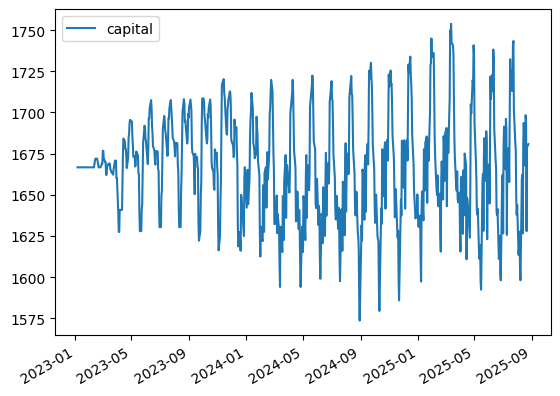

In [268]:
capital.rolling(5).sum().plot.line()
print(capital[-5:].sum())

### Debug optimal strategy with k=6 max trades per day

In [280]:
sim_params = SimulationParams(initial_capital=10000, threshold=0.55, fees=0.0016, top_k=6, portfolio_optimization=False, stop_loss=0.6, take_profit=1.5, lower_entry=1)

res, capital_6trades = simulate(new_df, sim_params)

SIMULATION STARTED
Simulations params: SimulationParams(initial_capital=10000, threshold=0.55, fees=0.0016, top_k=6, portfolio_optimization=False, stop_loss=0.6, take_profit=1.5, lower_entry=1)
 Count bids 2963 in total, avg.bids per day 4.9631490787269685,  filled bids 1974, fill bids percent = 0.6662166722915963
  Stop loss events: count = 0, net loss = 0.0 
  Take profit events: count = 4, net profit = 126.73023259892096 
  Start capital = 10000, Resulting capital: 10633.454951319703 
  CAGR in 4 years: 1.015 or 1.55 % of avg. growth per year


In [281]:
filter_stop_loss = (res.lower_entry==1) & (res.stop_loss==1)
print(f'Average real close price if not stop_loss: {res[filter_stop_loss].growth_future_30d.mean()}')
res[filter_stop_loss].head(10)

Average real close price if not stop_loss: nan


,Close_x,Ticker,Date,proba_pred10,pred10_rank,growth_future_30d,Ratio_MaxHighNext30_to_Close,Ratio_MinLowNext30_to_Close,Ratio_MinLowNext1_to_Close,weight,weight_norm,investment,lower_entry,stop_loss,take_profit,future_gross_return,fees,future_net_return


In [282]:
filter_take_profit = (res.lower_entry==1) & (res.take_profit==1) & (res.stop_loss==0)
print(f'Average real close price if not take_profit: {res[filter_take_profit].growth_future_30d.mean()}')
res[filter_take_profit].head(10)

Average real close price if not take_profit: 1.1034575275827752


,Close_x,Ticker,Date,proba_pred10,pred10_rank,growth_future_30d,Ratio_MaxHighNext30_to_Close,Ratio_MinLowNext30_to_Close,Ratio_MinLowNext1_to_Close,weight,weight_norm,investment,lower_entry,stop_loss,take_profit,future_gross_return,fees,future_net_return
2290,17.990000,FR0013412004,2024-12-24,0.667944,3.0,1.086270,101.128409,0.975598,0.986659,0.127944,0.167821,49.765968,1,0,1,74.648953,-0.079626,74.569327
2319,17.875999,FR0013412004,2025-01-03,0.654386,1.0,1.105281,101.773333,0.981819,0.981819,0.114386,0.306226,107.814779,1,0,1,161.722168,-0.172504,161.549665
2326,17.934000,FR0013412004,2025-01-06,0.581071,4.0,1.126352,101.444187,0.978644,0.993588,0.041071,0.132958,44.062722,1,0,1,66.094083,-0.070500,66.023583
2331,18.389000,FR0013412004,2025-01-07,0.563751,3.0,1.095927,98.934148,0.963783,0.987003,0.023751,0.190850,52.630673,1,0,1,78.946009,-0.084209,78.861800


In [283]:
filter_no_stop_loss_no_take_profit = (res.lower_entry==1) & (res.take_profit==0) & (res.stop_loss==0)
print(f'Average real close price if no take_profit or stop loss: {res[filter_no_stop_loss_no_take_profit].growth_future_30d.mean()}')
res['realised_profit'] = res.future_net_return/res.investment
res[filter_no_stop_loss_no_take_profit][['growth_future_30d','realised_profit']].describe().T

Average real close price if no take_profit or stop loss: 1.0088299215016878


,count,mean,std,min,25%,50%,75%,max
growth_future_30d,1966.0,1.008830,0.051909,0.761638,0.97912,1.006825,1.039819,1.272032
realised_profit,1970.0,1.007212,0.051858,0.760038,0.97768,1.004966,1.038068,1.270432


capital    10655.467901
dtype: float64


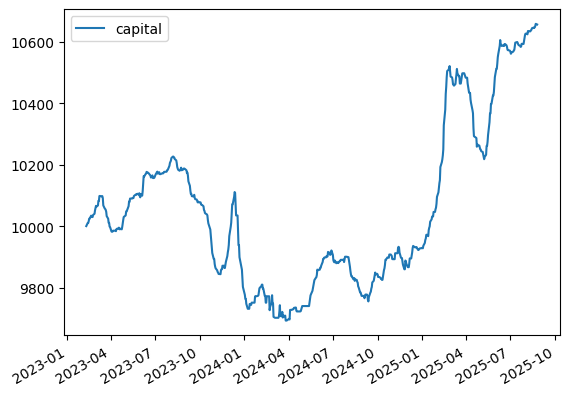

In [284]:
capital_4trades.rolling(30).sum().plot.line()
print(capital_4trades[-30:].sum())

### Debug optimal strategy with k=1 max trades per day

In [285]:
sim_params = SimulationParams(initial_capital=10000, threshold=0.55, fees=0.0016, top_k=1, portfolio_optimization=False, stop_loss=0.6, take_profit=1.5, lower_entry=1.0)

res, capital_1_trade = simulate(new_df, sim_params)

SIMULATION STARTED
Simulations params: SimulationParams(initial_capital=10000, threshold=0.55, fees=0.0016, top_k=1, portfolio_optimization=False, stop_loss=0.6, take_profit=1.5, lower_entry=1.0)
 Count bids 597 in total, avg.bids per day 1.0,  filled bids 396, fill bids percent = 0.6633165829145728
  Stop loss events: count = 0, net loss = 0.0 
  Take profit events: count = 1, net profit = 170.36809949852602 
  Start capital = 10000, Resulting capital: 10846.53607661743 
  CAGR in 4 years: 1.021 or 2.05 % of avg. growth per year


In [286]:
# NO STOP LOSS events
filter_stop_loss = (res.lower_entry==1) & (res.stop_loss==1)
print(f'Average real close price if not stop_loss: {res[filter_stop_loss].growth_future_30d.mean()}')
res[filter_stop_loss].head(10)

Average real close price if not stop_loss: nan


,Close_x,Ticker,Date,proba_pred10,pred10_rank,growth_future_30d,Ratio_MaxHighNext30_to_Close,Ratio_MinLowNext30_to_Close,Ratio_MinLowNext1_to_Close,weight,weight_norm,investment,lower_entry,stop_loss,take_profit,future_gross_return,fees,future_net_return


In [287]:
filter_take_profit = (res.lower_entry==1) & (res.take_profit==1) & (res.stop_loss==0)
print(f'Average real close price if not take_profit: {res[filter_take_profit].growth_future_30d.mean()}')
res[filter_take_profit].head(5)

Average real close price if not take_profit: 1.1052808249784576


,Close_x,Ticker,Date,proba_pred10,pred10_rank,growth_future_30d,Ratio_MaxHighNext30_to_Close,Ratio_MinLowNext30_to_Close,Ratio_MinLowNext1_to_Close,weight,weight_norm,investment,lower_entry,stop_loss,take_profit,future_gross_return,fees,future_net_return
470,17.875999,FR0013412004,2025-01-03,0.654386,1.0,1.105281,101.773333,0.981819,0.981819,0.114386,1.0,341.830055,1,0,1,512.745083,-0.546928,512.198155


In [288]:
filter_no_stop_loss_no_take_profit = (res.lower_entry==1) & (res.take_profit==0) & (res.stop_loss==0)
print(f'Average real close price if no take_profit or stop loss: {res[filter_no_stop_loss_no_take_profit].growth_future_30d.mean()}')
res['realised_profit'] = res.future_net_return/res.investment
res[filter_no_stop_loss_no_take_profit][['growth_future_30d','realised_profit']].describe().T

Average real close price if no take_profit or stop loss: 1.006499325360245


,count,mean,std,min,25%,50%,75%,max
growth_future_30d,395.0,1.006499,0.054573,0.853318,0.979756,1.005706,1.04048,1.126898
realised_profit,395.0,1.004899,0.054573,0.851718,0.978156,1.004106,1.03888,1.125298


capital    10846.536077
dtype: float64


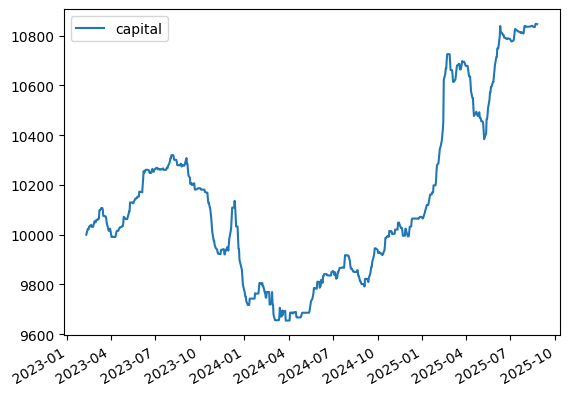

In [289]:
capital_1_trade.rolling(30).sum().plot.line()
print(capital_1_trade[-30:].sum())

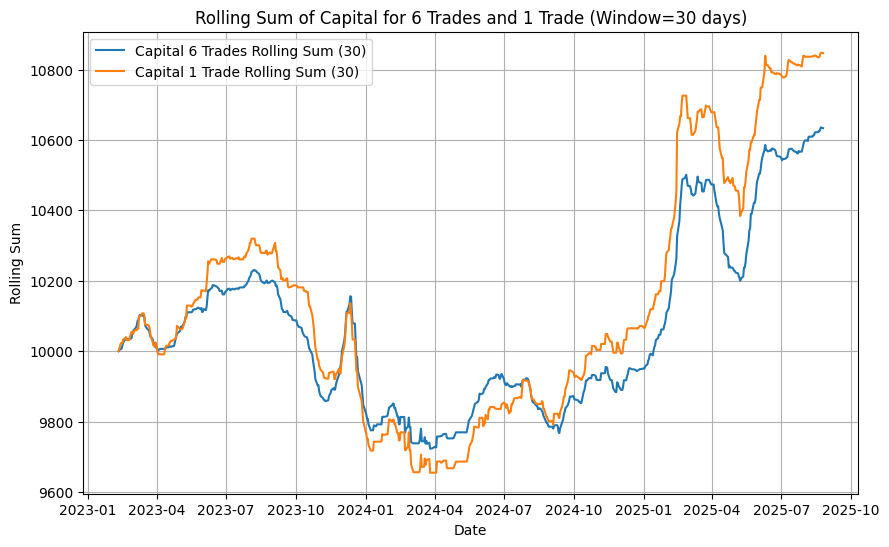

Capital 6 Trades Ending Sum: capital    10633.454951
dtype: float64
Capital 1 Trade Ending Sum: capital    10846.536077
dtype: float64


In [291]:
import matplotlib.pyplot as plt

# Assuming capital_6trades and capital_1_trade are defined and have the same index
capital_6trades_rolling = capital_6trades.rolling(30).sum()
capital_1_trade_rolling = capital_1_trade.rolling(30).sum()

# Plot the rolling sums on the same graph
plt.figure(figsize=(10, 6))
plt.plot(capital_6trades_rolling, label='Capital 6 Trades Rolling Sum (30)')
plt.plot(capital_1_trade_rolling, label='Capital 1 Trade Rolling Sum (30)')
plt.legend(loc='best')
plt.title('Rolling Sum of Capital for 6 Trades and 1 Trade (Window=30 days)')
plt.xlabel('Date')
plt.ylabel('Rolling Sum')
plt.grid(True)
plt.show()

# Print the ending values
print(f"Capital 6 Trades Ending Sum: {capital_6trades[-30:].sum()}")
print(f"Capital 1 Trade Ending Sum: {capital_1_trade[-30:].sum()}")